# Integrating Heterogeneous Humanitarian Data for Crisis Analysis

## A source-audit framework applied to Somalia, 2024

This notebook contains the full analysis supporting the dissertation. Four source
categories are used, represented by five datasets: ACLED (conflict), CHIRPS and VHI
(climate, treated as one category since both describe environmental conditions), WFP
(markets) and ReliefWeb (humanitarian reporting). These are referred to throughout as
"the four sources".

The notebook is organised in two parts. Part I designs the pipeline and validates it on a
two-month subset, where every district-month can be checked by hand against the source
files. Part II applies the same pipeline to the full year and uses the resulting panel to
answer RQ1 to RQ3 in turn: how the sources differ, which integration choices can mislead,
and what applying the framework to Somalia reveals about observability and reporting bias.

**Running this notebook.** All paths are relative to the repository root, so the working
directory must be the repository root. The raw and generated data are committed under
`data/raw/` and `data/processed/`, so the acquisition cells in Section 2.2 detect the
existing files and skip their network calls. Cells must be run in order: the Part I cells
build the star-schema tables on the two-month subset and the Part II cells rebuild them
across the full year. Packages beyond the standard scientific stack: `geopandas`,
`rasterio`, `rasterstats`, `fiona`.

## Setup

Run this cell first. It fetches the project files if they are not already present and
installs any missing packages, then leaves the working directory at the project root so
that the relative paths used throughout (`data/raw/...`, `data/processed/...`) resolve.

Both steps are skipped when they are already satisfied, so the cell is safe to re-run and
safe to run from a local clone. On Google Colab, restart the runtime after this cell if
the geospatial packages had to be installed, then continue from the next cell.

In [1]:
import importlib.util
import os
import subprocess
import sys

REPO = "https://github.com/hcfgsqm2q7-lang/Dissertation---Samuel-Aracena.git"
BRANCH = "claude/dissertation-work-cp388p"
FOLDER = "Dissertation---Samuel-Aracena"

# Fetch the project only if the data is not already alongside this notebook.
if not os.path.isdir("data/raw"):
    if not os.path.isdir(FOLDER):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH, "--depth", "1", REPO, FOLDER],
            check=True,
        )
    os.chdir(FOLDER)

if not os.path.isdir("data/raw"):
    raise RuntimeError(
        "data/raw not found. Run this notebook from the project root, or let the clone "
        "above complete first."
    )

# Install only what is missing. Keys are import names, values are pip names.
packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "patsy": "patsy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "geopandas": "geopandas",
    "fiona": "fiona",
    "pyproj": "pyproj",
    "rasterio": "rasterio",
    "rasterstats": "rasterstats",
    "requests": "requests",
    "bs4": "beautifulsoup4",
    "openpyxl": "openpyxl",
}

missing = [pip_name for module, pip_name in packages.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("Done. On Colab, restart the runtime now if geopandas or rasterio were installed.")
else:
    print("All required packages are already available.")

print("Working directory:", os.getcwd())
print("Raw data files:", len(os.listdir("data/raw")))

All required packages are already available.
Working directory: /home/user/Dissertation---Samuel-Aracena
Raw data files: 10


# 1. Research question and sub-questions

### Research question and sub-questions

**Main research question**: What methodological challenges arise when integrating
heterogeneous geographic humanitarian data for crisis analysis, and how can these
challenges be systematically identified?

This is addressed through three sub-questions, which the dissertation numbers RQ1 to RQ3:

**RQ1. Data integration and quality.** How do humanitarian sources differ in spatial
granularity, temporal resolution, missingness, provenance and measurement uncertainty?

**RQ2. Failure modes.** Which integration choices can introduce misleading coverage
estimates, invalid features or incorrect statistical conclusions?

**RQ3. Empirical consequences.** What does applying a source-aware integration framework
to Somalia reveal about humanitarian observability and reporting bias?

An earlier framing of this project asked how unevenly sources observe different places and
what that means for food-insecurity analysis specifically, and proposed comparing the
dataset's own severity assessment against an external benchmark. That comparison was never
built, and the questions above are the ones this work actually answers. The benchmark
comparison is retained as further work in the closing section rather than presented as an
unfinished part of the analysis.

### Sub-question, analysis, status

Each sub-question maps to analyses in this notebook. Where a finding changed once the
window widened from two months to twelve, both results are noted, since the change is
itself informative about how much the two-month prototype could support.

| Sub-question | Corresponding analysis | Status |
|---|---|---|
| **RQ1. Data integration and quality** | The source-quality comparison across all four sources (granularity, temporal resolution, missingness, provenance, measurement uncertainty); the structural availability, recorded coverage and true observability distinction; the month-by-month coverage table; the source-complementarity analysis; and the WFP observed-versus-forecast audit. | **Answered.** The four sources differ structurally on every dimension examined. Market presence is a year-round district-level fact (35 of 74 districts); price coverage is 469 of 888 district-months missing, PEWI 505 (508 for rice); ACLED is 77.5% exactly geocoded; and 99.8% of the four basket commodities' 2024 values are genuinely observed rather than forecast. |
| **RQ2. Failure modes** | Four integration choices tested directly rather than assumed: pseudo-replication in the market/conflict comparison; percentage-change trend features; area-based conflict density; and the zero-versus-missing distinction. The ACLED join reconciliation added to the conflict-building cell belongs here too. | **Answered.** Each failure was demonstrated concretely. The naive market/conflict result (p=0.0001) did not survive using the district as the unit of analysis (p=0.18); percentage change is undefined when the previous month is zero, so log differences replaced it; conflict density correlated with raw counts at r=0.96 and added nothing; and the join reconciliation showed how an unmatched district name silently becomes a zero. |
| **RQ3. Empirical consequences** | The negative binomial model comparing conflict against vegetation stress, its food-and-nutrition-only variant, the attention-response curve, the candidate observability gaps, and the district fixed-effects check. | **Answered, with an important qualification.** Reporting attention tracks conflict far more strongly than vegetation stress (IRR 1.69 versus 0.997 pooled; 1.77 versus 1.04 restricted to food and nutrition reports), and 27 district-months across 18 districts carry an extreme signal with no market observation and no detected reporting. District fixed effects reduce the conflict association to IRR 1.02, so the defensible reading is cross-sectional rather than a within-district month-to-month reaction. |

# Part I. Designing and validating the pipeline on a two-month prototype

Everything in Part I is built and checked on January and February 2024, a 148 district-month
subset. Working at this size keeps validation tractable: feature definitions, the geoparsing
logic and the star schema can all be checked directly against the source files before being
committed to. Part II then rebuilds the same tables across all twelve months.

# 2. Data sources and the dimensional model

## 2.1 Approach

A prototype is built first, on a deliberately narrow slice, to validate that the integration pipeline works end to end before it is run across the full year.

**Country**: Somalia, the case study for this dissertation. It carries the most complete data across all four sources, which makes it a reliable choice for validating the integration pipeline itself.

**Time window**: January-February 2024. This window was not an arbitrary choice. It followed from an early reading of WFP's price export, which appeared at the time to contain genuinely observed data only for those two months. That inference was later corrected: the Somalia-specific audit of the four basket commodities finds 99.8% of 2024 values genuinely observed across all twelve months, not forecast. The two-month window remains a sensible validation scope, but the reason recorded for it at the time was wrong, and the correction is left visible rather than edited away.

**Scope**: this dissertation is a single-country, single-year case study, Somalia in 2024. One analysis reaches wider: the WFP price audit covers all four countries WFP tracks in the region across 2015 to 2024, because that audit is about the source's own properties rather than about Somalia. Every analysis answering RQ1 to RQ3 is Somalia 2024.

**Spatial resolution**: Admin2 (district) level, using all 74 Somalia districts per GADM 4.1

### Star Schema & Dimensional Modeling

Dimensional modeling splits data into two kinds of tables: **fact tables**, which hold the actual measurements, and **dimension tables**, which hold the descriptive context around them (who, where, when). A **star schema** is a setup built around this concept: one fact table in the middle, surrounded by the dimensions it references.

A few ideas from this approach shaped how this project is built:

- **Grain** : deciding exactly what one row in a fact table means, before anything else gets built. In this case, one row corresponds to one admin 2 x month observation.
- **Conformed dimensions** : shared reference tables (like location or time) that multiple fact tables can plug into consistently.
- **Fact constellation** : This happens when several fact tables share dimensions instead of just one.
- **Additive vs. non-additive facts**: some numbers can be added without constraints (event counts, fatalities); others can't (density, price anomaly scores) and need to be recalculated rather than added up.


### How this project actually uses it

This project is organized around **four humanitarian mechanisms**, each thought to relate to food insecurity through a different pathway: conflict and insecurity, climate and agricultural stress, market and food price pressure, and humanitarian reporting activity. Each mechanism gets its own fact table : `fact_conflict`, `fact_climate`, `fact_market`, `fact_reporting`,  so this project is a **fact constellation**, not a single star: four mechanism-specific fact tables sharing two common dimensions (`dim_location`, `dim_time`)

We chose to create a separate table for each mechanism instead of combining everything into one large table because the four mechanisms are measured at different levels of detail. Keeping them in a single table would either require duplicating data or leaving out important information.


A couple of deliberate, documented tradeoffs:

- Commodities are represented directly as column groups in `fact_market` (e.g. `wheatflour_price_usd`, `rice_pewi_score`) rather than through a separate `dim_commodity` table. A `dim_commodity` dimension was originally built and used, following the same normalization pattern as `dim_location` and `dim_time` , but it was dropped in favor of standalone commodity features once the commodity list was fixed at four items.
- `fact_reporting` originally sat at country-level grain, which didn't cleanly match `dim_location`'s Admin2 level. This was later resolved properly: `fact_reporting` was rebuilt using text-based geoparsing to attribute reports to specific districts by name, bringing it to genuine Admin2 × Month grain like the other three fact tables (see ReliefWeb Integration Issue for the full reasoning and remaining limitations of that approach).
- Ratio-style features like `conflict_density` and `pewi_score` are never summed during aggregation, only ever recalculated from their raw components, since summing a ratio produces a meaningless number.
- Boundaries come from a single GADM version (4.1). Administrative boundaries do change over time, so applying one version across a longer window would need versioning care; within this dissertation's single year that risk is minimal. It is recorded as a limitation of the approach rather than quietly ignored.


 The analysis-ready output is `vw_food_insecurity_panel`, a Admin2×Month table built by joining and pivoting all four mechanisms together once, at the very end.


## 2.2 Acquiring the source data

The five source datasets are retrieved below. Each acquisition cell checks for the files on
disk first and skips its network call when they are already present, so this section is
reproducible from the committed data without reaching any external service.

### Downloading VHI data for 2024

In [2]:
# Download NOAA VHI data for 2024

# Import libraries

import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin


# Set download folder

# Change this path if you want the files stored somewhere else
DOWNLOAD_DIR = "data/raw/VHI/2024"

# Create the folder if it doesn't already exist
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Files will be saved to:")
print(DOWNLOAD_DIR)


# NOAA VHI GeoTIFF directory

BASE_URL = (
    "https://www.star.nesdis.noaa.gov/data/pub0018/"
    "VHPdata4users/data/Blended_VH_4km/geo_TIFF/"
)

EXPECTED_WEEKS = 52


# Fetch (skipped if the full 2024 set is already present -- this
# notebook was migrated from Colab, and NOAA isn't reachable from this
# environment's network policy; the 52 weekly files were pre-fetched via
# the Google Drive API, cropped to Somalia's extent, and committed to
# the repo instead)

existing = sorted([
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.endswith(".VH.VHI.tif")
]) if os.path.isdir(DOWNLOAD_DIR) else []

if len(existing) >= EXPECTED_WEEKS:
    print(f"\n{len(existing)} VHI files already present in {DOWNLOAD_DIR} -- skipping NOAA fetch.")
    downloaded_files = existing
else:
    print("\nConnecting to NOAA...")

    response = requests.get(BASE_URL)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    print("Connection successful.")

    # Find all VHI files for 2024: files from 2024, VHI files, GeoTIFF files
    vhi_files = []

    for link in soup.find_all("a"):
        filename = link.get("href")
        if filename is None:
            continue
        if "P2024" in filename and filename.endswith(".VH.VHI.tif"):
            vhi_files.append(filename)

    # Remove duplicates and sort chronologically
    vhi_files = sorted(set(vhi_files))

    print("\n----------------------------------------")
    print("VHI FILES FOUND")
    print("----------------------------------------")
    print(f"\nTotal files found: {len(vhi_files)}\n")
    for filename in vhi_files:
        print(filename)

    if len(vhi_files) == 0:
        raise ValueError(
            "No 2024 VHI files were found. "
            "Check the NOAA directory or filename pattern."
        )

    print("\n----------------------------------------")
    print("STARTING DOWNLOAD")
    print("----------------------------------------\n")

    for i, filename in enumerate(vhi_files, start=1):
        file_url = urljoin(BASE_URL, filename)
        output_path = os.path.join(DOWNLOAD_DIR, filename)

        if os.path.exists(output_path):
            print(f"[{i}/{len(vhi_files)}] Already exists — skipping: {filename}")
            continue

        print(f"[{i}/{len(vhi_files)}] Downloading: {filename}")

        with requests.get(file_url, stream=True) as r:
            r.raise_for_status()
            with open(output_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)

    downloaded_files = sorted([
        f for f in os.listdir(DOWNLOAD_DIR)
        if f.endswith(".VH.VHI.tif")
    ])


# Verify files present

print("\n----------------------------------------")
print("VHI DATA READY")
print("----------------------------------------")
print(f"\nTotal VHI files in {DOWNLOAD_DIR}: {len(downloaded_files)}")
print("\nLocal folder:")
print(DOWNLOAD_DIR)


Files will be saved to:
data/raw/VHI/2024

52 VHI files already present in data/raw/VHI/2024 -- skipping NOAA fetch.

----------------------------------------
VHI DATA READY
----------------------------------------

Total VHI files in data/raw/VHI/2024: 52

Local folder:
data/raw/VHI/2024


### Downloading CHIRPS data for 2024

In [3]:
# Download CHIRPS monthly data for 2024

import os
import gzip
import shutil
import requests


# Set folder for downloaded data

DOWNLOAD_DIR = "data/raw/CHIRPS/2024"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Files will be saved to:")
print(DOWNLOAD_DIR)


# Set CHIRPS monthly GeoTIFF archive

BASE_URL = (
    "https://data.chc.ucsb.edu/products/"
    "CHIRPS-2.0/global_monthly/tifs/"
)

YEAR = 2024


# Create filenames for all 12 months

chirps_files = [
    f"chirps-v2.0.{YEAR}.{month:02d}.tif.gz"
    for month in range(1, 13)
]

print("\nFiles to download:\n")

for filename in chirps_files:
    print(filename)


# Download and decompress each file. Already-present files are skipped
# automatically below -- this notebook was migrated from Colab, and the
# full 2024 set was pre-fetched via the Google Drive API (cropped to
# Somalia's extent) and committed to the repo, so this loop skips
# straight through without touching the network, which isn't reachable
# from this environment's network policy anyway.

for i, filename in enumerate(chirps_files, start=1):

    file_url = BASE_URL + filename
    gz_path = os.path.join(DOWNLOAD_DIR, filename)
    tif_filename = filename.replace(".gz", "")
    tif_path = os.path.join(DOWNLOAD_DIR, tif_filename)

    print(f"\n[{i}/12] Processing {filename}")

    if os.path.exists(tif_path):
        print("TIFF already exists — skipping.")
        continue

    if not os.path.exists(gz_path):
        print("Downloading...")
        with requests.get(file_url, stream=True) as r:
            r.raise_for_status()
            with open(gz_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
    else:
        print("Compressed file already downloaded.")

    print("Decompressing...")
    with gzip.open(gz_path, "rb") as f_in:
        with open(tif_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    os.remove(gz_path)
    print(f"Saved: {tif_filename}")


# Verify downloaded files

downloaded_files = sorted([
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.endswith(".tif")
])

print("\nDOWNLOAD COMPLETE")
print(f"\nTotal CHIRPS TIFF files found: {len(downloaded_files)}")
print("\nFiles:\n")
for filename in downloaded_files:
    print(filename)

print("\nLocal folder:")
print(DOWNLOAD_DIR)


Files will be saved to:
data/raw/CHIRPS/2024

Files to download:

chirps-v2.0.2024.01.tif.gz
chirps-v2.0.2024.02.tif.gz
chirps-v2.0.2024.03.tif.gz
chirps-v2.0.2024.04.tif.gz
chirps-v2.0.2024.05.tif.gz
chirps-v2.0.2024.06.tif.gz
chirps-v2.0.2024.07.tif.gz
chirps-v2.0.2024.08.tif.gz
chirps-v2.0.2024.09.tif.gz
chirps-v2.0.2024.10.tif.gz
chirps-v2.0.2024.11.tif.gz
chirps-v2.0.2024.12.tif.gz

[1/12] Processing chirps-v2.0.2024.01.tif.gz
TIFF already exists — skipping.

[2/12] Processing chirps-v2.0.2024.02.tif.gz
TIFF already exists — skipping.

[3/12] Processing chirps-v2.0.2024.03.tif.gz
TIFF already exists — skipping.

[4/12] Processing chirps-v2.0.2024.04.tif.gz
TIFF already exists — skipping.

[5/12] Processing chirps-v2.0.2024.05.tif.gz
TIFF already exists — skipping.

[6/12] Processing chirps-v2.0.2024.06.tif.gz
TIFF already exists — skipping.

[7/12] Processing chirps-v2.0.2024.07.tif.gz
TIFF already exists — skipping.

[8/12] Processing chirps-v2.0.2024.08.tif.gz
TIFF already exist

### Downloading ReliefWeb data for 2024

In [4]:
# Download ReliefWeb reports for 2024

import os
import requests
import pandas as pd


# Set output file

DOWNLOAD_DIR = "data/raw"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

OUTPUT_FILE = os.path.join(DOWNLOAD_DIR, "reliefweb_horn_of_africa_2024.csv")

print("File will be saved to:")
print(OUTPUT_FILE)


# Enter your approved ReliefWeb app name

APP_NAME = "MiddlesexUniversity-FoodSecurityResearch-X7K9"


# Set ReliefWeb API endpoint

BASE_URL = f"https://api.reliefweb.int/v2/reports?appname={APP_NAME}"


# Define countries and date range

COUNTRIES = ["Somalia", "Ethiopia", "Kenya", "South Sudan"]
START_DATE = "2024-01-01T00:00:00+00:00"
END_DATE = "2024-12-31T23:59:59+00:00"


# Define fields to download

FIELDS_TO_INCLUDE = [
    "id", "title", "body", "url", "date.created", "date.original",
    "date.changed", "primary_country", "country", "source", "format",
    "theme", "disaster", "disaster_type", "language", "headline", "status",
]


# Helper functions

def get_name_list(items):
    if not items:
        return None
    return ", ".join(item.get("name", "") for item in items if isinstance(item, dict))


def get_shortname_list(items):
    if not items:
        return None
    return ", ".join(item.get("shortname", item.get("name", "")) for item in items if isinstance(item, dict))


def flatten_report(item):
    fields = item.get("fields", {})
    date = fields.get("date", {})
    primary_country = fields.get("primary_country", {})
    return {
        "id": item.get("id"),
        "title": fields.get("title"),
        "body": fields.get("body"),
        "url": fields.get("url"),
        "date_created": date.get("created"),
        "date_original": date.get("original"),
        "date_changed": date.get("changed"),
        "primary_country": primary_country.get("name") if isinstance(primary_country, dict) else None,
        "countries": get_name_list(fields.get("country")),
        "sources": get_name_list(fields.get("source")),
        "source_shortnames": get_shortname_list(fields.get("source")),
        "formats": get_name_list(fields.get("format")),
        "themes": get_name_list(fields.get("theme")),
        "disasters": get_name_list(fields.get("disaster")),
        "disaster_types": get_name_list(fields.get("disaster_type")),
        "languages": get_name_list(fields.get("language")),
        "headline": fields.get("headline"),
        "status": fields.get("status"),
    }


def download_country_reports(country):
    print(f"\nDownloading ReliefWeb reports for {country}...")
    all_reports = []
    offset = 0
    limit = 1000

    while True:
        payload = {
            "limit": limit,
            "offset": offset,
            "profile": "full",
            "sort": ["date.created:asc"],
            "filter": {
                "operator": "AND",
                "conditions": [
                    {"field": "primary_country", "value": country},
                    {"field": "date.created", "value": {"from": START_DATE, "to": END_DATE}},
                ],
            },
            "fields": {"include": FIELDS_TO_INCLUDE},
        }

        response = requests.post(BASE_URL, json=payload)
        response.raise_for_status()
        data = response.json()

        reports = data.get("data", [])
        total_count = data.get("totalCount", 0)
        print(f"Retrieved {offset + len(reports):,} of {total_count:,}")

        all_reports.extend(reports)

        if len(reports) == 0 or offset + len(reports) >= total_count:
            break
        offset += limit

    flattened = [flatten_report(report) for report in all_reports]
    country_df = pd.DataFrame(flattened)
    print(f"{country}: {len(country_df):,} reports downloaded")
    return country_df


# Fetch (skipped if already present -- this notebook was migrated from
# Colab, and the full 2024 ReliefWeb export was pre-fetched via the
# Google Drive API and committed to the repo; the ReliefWeb API itself
# also isn't reachable from this environment's network policy)

if os.path.exists(OUTPUT_FILE):
    print(f"\n{OUTPUT_FILE} already present -- skipping ReliefWeb fetch.")
    reliefweb_2024 = pd.read_csv(OUTPUT_FILE)
else:
    all_country_data = [download_country_reports(country) for country in COUNTRIES]
    reliefweb_2024 = pd.concat(all_country_data, ignore_index=True)
    print("\nTotal reports downloaded:", f"{len(reliefweb_2024):,}")

    for column in ["date_created", "date_original", "date_changed"]:
        reliefweb_2024[column] = pd.to_datetime(reliefweb_2024[column], errors="coerce", utc=True)

    reliefweb_2024["year"] = reliefweb_2024["date_created"].dt.year
    reliefweb_2024["month"] = reliefweb_2024["date_created"].dt.month

    print("\nReports by primary country:")
    print(reliefweb_2024["primary_country"].value_counts(dropna=False))
    print("\nReports by month:")
    print(reliefweb_2024[["year", "month"]].value_counts().sort_index())
    print("\nDuplicate report IDs:", reliefweb_2024["id"].duplicated().sum())

    reliefweb_2024 = reliefweb_2024.drop_duplicates(subset="id").reset_index(drop=True)
    reliefweb_2024.to_csv(OUTPUT_FILE, index=False)
    print("\nDownload complete.")

print("\nFinal number of unique reports:", f"{len(reliefweb_2024):,}")
print("\nSaved to:")
print(OUTPUT_FILE)


File will be saved to:
data/raw/reliefweb_horn_of_africa_2024.csv

data/raw/reliefweb_horn_of_africa_2024.csv already present -- skipping ReliefWeb fetch.

Final number of unique reports: 3,687

Saved to:
data/raw/reliefweb_horn_of_africa_2024.csv


## 2.3 Building the dimensional tables

Six tables are built, following the star schema defined above:

* dim_location
* dim_time
* fact_conflict
* fact_climate
* fact_reporting
* fact_market

### dim_location

In [5]:
import geopandas as gpd
import pandas as pd
from pyproj import Geod

# Load inputs
gdf = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")  # all 74 districts
crosswalk = pd.read_csv("data/raw/somalia_admin2_crosswalk.csv")     # only covers the 35 WFP-market districts

# Mark which districts have WFP market coverage
gdf["has_market_coverage"] = gdf["GID_2"].isin(crosswalk["gadm_gid_2"])

# Attach WFP naming where it exists; fall back to GADM's own name otherwise
wfp_name_lookup = dict(zip(crosswalk["gadm_gid_2"], crosswalk["wfp_admin2_name"]))
gdf["admin2"] = gdf["GID_2"].map(wfp_name_lookup).fillna(gdf["NAME_2"])

# Compute geodesic area (WGS84 ellipsoid, no reprojection needed)
geod = Geod(ellps="WGS84")

def geodesic_area_km2(geom):
    area_m2, _ = geod.geometry_area_perimeter(geom)
    return abs(area_m2) / 1_000_000

gdf["area_km2"] = gdf["geometry"].apply(geodesic_area_km2).round(2)

# Compute centroid using an equal-area projection, then convert back to lat/lon
gdf_projected = gdf.to_crs("ESRI:102022")
centroids_projected = gdf_projected["geometry"].centroid
centroids_wgs84 = gpd.GeoSeries(centroids_projected, crs="ESRI:102022").to_crs("EPSG:4326")
gdf["longitude"] = centroids_wgs84.x.round(6)
gdf["latitude"] = centroids_wgs84.y.round(6)

# Build location_id
gdf["location_id"] = "SO_" + (
    gdf["admin2"].str.upper().str.replace(" ", "_").str.replace("-", "_").str.replace("'", "")
)

# Assemble final dim_location table
dim_location = pd.DataFrame({
    "location_id": gdf["location_id"],
    "country_code": "SO",
    "country": "Somalia",
    "admin1": gdf["NAME_1"],
    "admin2": gdf["admin2"],
    "admin2_gadm_name": gdf["NAME_2"],
    "gadm_gid_2": gdf["GID_2"],
    "latitude": gdf["latitude"],
    "longitude": gdf["longitude"],
    "area_km2": gdf["area_km2"],
    "boundary_source": "GADM 4.1",
    "has_market_coverage": gdf["has_market_coverage"]
}).sort_values("location_id").reset_index(drop=True)

# Validate, display, save
print(f"Rows: {len(dim_location)}  (expected 74)")
print(f"With market coverage: {dim_location['has_market_coverage'].sum()}  (expected 35)")
print(dim_location)
dim_location.to_csv("data/processed/dim_location_somalia_full74.csv", index=False)


Rows: 74  (expected 74)
With market coverage: 35  (expected 35)
       location_id country_code  country             admin1       admin2  \
0         SO_AADAN           SO  Somalia  Shabeellaha Dhexe        Aadan   
1       SO_AFGOOYE           SO  Somalia  Shabeellaha Hoose      Afgooye   
2       SO_AFMADOW           SO  Somalia      Jubbada Hoose      Afmadow   
3   SO_BAAR_DHEERE           SO  Somalia               Gedo  Baar-Dheere   
4     SO_BADHAADHE           SO  Somalia      Jubbada Hoose    Badhaadhe   
..             ...          ...      ...                ...          ...   
69   SO_WANLA_WEYN           SO  Somalia  Shabeellaha Hoose   Wanla Weyn   
70  SO_XARARDHEERE           SO  Somalia              Mudug  Xarardheere   
71        SO_XUDUN           SO  Somalia               Sool        Xudun   
72        SO_XUDUR           SO  Somalia             Bakool        Xudur   
73       SO_ZEYLAC           SO  Somalia              Awdal       Zeylac   

   admin2_gadm_name  ga

### dim_time

In [6]:
import pandas as pd

# Build dim_time for the prototype window
months = pd.date_range(start="2024-01-01", end="2024-02-01", freq="MS")

dim_time = pd.DataFrame({
    "time_id": months.strftime("%Y%m"),
    "year": months.year,
    "month_number": months.month,
    "month_name": months.strftime("%B"),
    "quarter": months.quarter,
    "year_month": months.strftime("%Y-%m"),
})

print(dim_time)
dim_time.to_csv("data/processed/dim_time_somalia.csv", index=False)

  time_id  year  month_number month_name  quarter year_month
0  202401  2024             1    January        1    2024-01
1  202402  2024             2   February        1    2024-02


### fact_conflict

In [7]:
import pandas as pd

# Load inputs
acled = pd.read_csv("data/raw/ACLED_Somalia_full_2024.csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# Fix ACLED naming for the non-market districts
acled_name_fixes = {
    "Adan Yabaal": "Aadan", "Baardheere": "Baar-Dheere", "Buur Hakaba": "Buur Xakaba",
    "Caluula": "Calawla", "Ceel Afweyn": "Ceel-Afwein", "Dhuusamarreeb": "Dhuusamareeb",
    "Galdogob": "Goldogob", "Garbahaarey": "Garbahaaray", "Gebiley": "Gabiley",
    "Kurtunwaarey": "Kuntuwaaray", "Lughaye": "Lughaya", "Owdweyne": "Oodweyne",
    "Tayeeglow": "Tiyeeglow", "Waajid": "Wajid",
    # Added after a reconciliation check found one event (SOM44059, 2 April,
    # 20 fatalities) silently dropped: ACLED spells this district "Sablaale",
    # GADM spells it "Sablale". Without this line SO_SABLALE reads zero events
    # for April 2024 despite a recorded source event, which is exactly the
    # integration-created zero this dissertation warns about.
    "Sablaale": "Sablale",
}

som = acled[acled["country"] == "Somalia"].copy()
som["admin2"] = som["admin2"].replace(acled_name_fixes)
som["event_date"] = pd.to_datetime(som["event_date"])
som["time_id"] = som["event_date"].dt.strftime("%Y%m")

# Some ACLED admin2 labels have no counterpart in GADM's 74-district list at all, so a
# name-based join drops them. Rather than lose them, fall back to the coordinates ACLED
# already carries and place each event in whichever district polygon contains it. This
# recovers the two Laasqoray events (a coastal Sanaag locality GADM folds into Badhan).
# Events that fall outside every polygon, such as an offshore "Coast of Bari" record,
# genuinely have no district and are left unassigned rather than guessed at.
import geopandas as gpd
from shapely.geometry import Point

_districts = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")[["NAME_2", "geometry"]]
_unmatched = ~som["admin2"].isin(set(dim_location["admin2"]))
_locatable = _unmatched & som["latitude"].notna() & som["longitude"].notna()

if _locatable.any():
    _pts = gpd.GeoDataFrame(
        som.loc[_locatable, ["event_id_cnty"]].copy(),
        geometry=[Point(x, y) for x, y in zip(som.loc[_locatable, "longitude"],
                                              som.loc[_locatable, "latitude"])],
        crs=_districts.crs,
    )
    _hit = gpd.sjoin(_pts, _districts, how="left", predicate="within")
    _resolved = _hit.dropna(subset=["NAME_2"]).set_index("event_id_cnty")["NAME_2"]
    if len(_resolved):
        som.loc[som["event_id_cnty"].isin(_resolved.index), "admin2"] = (
            som.loc[som["event_id_cnty"].isin(_resolved.index), "event_id_cnty"].map(_resolved)
        )
        print(f"Placed {len(_resolved)} event(s) by coordinates where the name did not match:")
        for _eid, _name in _resolved.items():
            print(f"   {_eid} -> {_name}")

# Aggregate ACLED events to Admin2 x Month
agg = som.groupby(["admin2", "time_id"]).agg(
    fatalities=("fatalities", "sum"),
    conflict_event_count=("event_id_cnty", "count"),
).reset_index()

# Build the complete Admin2 x Month panel (74 x 2 = 148 rows)
months = pd.DataFrame({"time_id": ["202401", "202402"]})
panel = dim_location[["location_id", "admin2", "area_km2"]].merge(months, how="cross")
fact_conflict = panel.merge(agg, on=["admin2", "time_id"], how="left")

# Zero-fill count/fatality fields where no events were recorded
count_cols = ["fatalities", "conflict_event_count"]
fact_conflict[count_cols] = fact_conflict[count_cols].fillna(0).astype(int)

# Compute conflict_density (area-based)
fact_conflict["conflict_density"] = (fact_conflict["conflict_event_count"] / fact_conflict["area_km2"]).round(6)

# Compute conflict_trend_pct, with explicit zero-previous-month rule
fact_conflict = fact_conflict.sort_values(["location_id", "time_id"])
fact_conflict["prev_month_count"] = fact_conflict.groupby("location_id")["conflict_event_count"].shift(1)

def compute_trend(row):
    if pd.isna(row["prev_month_count"]) or row["prev_month_count"] == 0:
        return pd.NA
    return round(((row["conflict_event_count"] - row["prev_month_count"]) / row["prev_month_count"]) * 100, 2)

fact_conflict["conflict_trend_pct"] = fact_conflict.apply(compute_trend, axis=1)

# Final column selection
fact_conflict_final = fact_conflict[[
    "location_id", "time_id", "conflict_event_count", "fatalities", "conflict_density", "conflict_trend_pct"
]].reset_index(drop=True)

# Display and save
pd.set_option("display.max_rows", None)
print(fact_conflict_final)
fact_conflict_final.to_csv("data/processed/fact_conflict_somalia.csv", index=False)

# Reconciliation audit: no source record may disappear silently
# A left join onto the 74-district grid drops any ACLED district name that does not
# resolve. That is invisible unless checked, so the totals are reconciled explicitly
# and every unmatched record is named.
_valid = set(dim_location["admin2"])
# compare like with like: only the months this panel actually covers
_scope = som[som["time_id"].isin(set(fact_conflict_final["time_id"]))]
_unmatched = _scope[~_scope["admin2"].isin(_valid)]
_src_ev, _src_fat = len(_scope), int(_scope["fatalities"].sum())
_keep_ev = int(fact_conflict_final["conflict_event_count"].sum())
_keep_fat = int(fact_conflict_final["fatalities"].sum())

print("\n=== ACLED join reconciliation ===")
print(f"Source (Somalia):  {_src_ev:,} events, {_src_fat:,} fatalities")
print(f"Retained in panel: {_keep_ev:,} events, {_keep_fat:,} fatalities")
print(f"Difference:        {_src_ev - _keep_ev} events, {_src_fat - _keep_fat} fatalities")

if len(_unmatched):
    _summary = (_unmatched.assign(admin2=_unmatched["admin2"].fillna("<no admin2 recorded>"))
                .groupby("admin2")
                .agg(events=("event_id_cnty", "count"), fatalities=("fatalities", "sum")))
    print("\nUnresolved source records, excluded deliberately rather than silently:")
    print(_summary.to_string())
    print("\nThese are records that neither the name map nor the coordinate fallback could")
    print("place: they fall outside every district polygon, so they have no district on this")
    print("grid rather than a district we failed to find.")
    print("\nThese exclusions are reported here instead of vanishing into a zero, which is the")
    print("distinction between a recorded absence and an unobserved one that Section 3.3 sets")
    print("out. A district name that fails to resolve would otherwise be indistinguishable")
    print("from a district that genuinely had no events that month.")
else:
    print("\nAll source records resolved to a district.")

Placed 2 event(s) by coordinates where the name did not match:
   SOM43598 -> Badhan
   SOM43778 -> Badhan


          location_id time_id  conflict_event_count  fatalities  \
0            SO_AADAN  202401                     0           0   
1            SO_AADAN  202402                     3           6   
2          SO_AFGOOYE  202401                    17           7   
3          SO_AFGOOYE  202402                    29          21   
4          SO_AFMADOW  202401                     2           0   
5          SO_AFMADOW  202402                     5           2   
6      SO_BAAR_DHEERE  202401                     0           0   
7      SO_BAAR_DHEERE  202402                     1           1   
8        SO_BADHAADHE  202401                     5           7   
9        SO_BADHAADHE  202402                     1           0   
10          SO_BADHAN  202401                     0           0   
11          SO_BADHAN  202402                     2           2   
12            SO_BAKI  202401                     0           0   
13            SO_BAKI  202402                     0           

### fact_climate

In [8]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats

# Sanity check: confirm what's actually in the working directory
print("Working directory:", os.getcwd())
print("CHIRPS files found:", [f for f in os.listdir("data/raw/CHIRPS/2024") if f.startswith("chirps")])
print("VHI files found:", [f for f in os.listdir("data/raw/VHI/2024") if f.startswith("VHP")])

# Load Admin2 boundaries -- ALL 74 districts, not just the 35 with market coverage
gdf_full = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

gdf = gdf_full.merge(
    dim_location[["location_id", "gadm_gid_2"]],
    left_on="GID_2", right_on="gadm_gid_2"
)[["location_id", "geometry"]]

print(f"Districts in gdf: {len(gdf)}  (expected 74)")

# Confirmed NoData values (from direct pixel inspection, not file metadata)
CHIRPS_NODATA = -9999
VHI_NODATA = -9999

# Zonal mean helper
def zonal_mean(gdf, tif_path, nodata):
    stats = zonal_stats(gdf, tif_path, stats="mean", nodata=nodata, geojson_out=False)
    return np.array([s["mean"] if s["mean"] is not None else np.nan for s in stats])

# CHIRPS monthly rainfall: direct zonal mean, no aggregation needed
rainfall_jan = zonal_mean(gdf, "data/raw/CHIRPS/2024/chirps-v2.0.2024.01.tif", CHIRPS_NODATA)
rainfall_feb = zonal_mean(gdf, "data/raw/CHIRPS/2024/chirps-v2.0.2024.02.tif", CHIRPS_NODATA)

# VHI weekly -> monthly, day-weighted for boundary weeks
vhi_files = {i: f"data/raw/VHI/2024/VHP.G04.C07.j01.P2024{i:03d}.VH.VHI.tif" for i in range(1, 10)}
vhi_weekly = {i: zonal_mean(gdf, path, VHI_NODATA) for i, path in vhi_files.items()}

jan_weights = {1: 1, 2: 1, 3: 1, 4: 1, 5: 3/7}
vhi_jan = sum(vhi_weekly[w] * wt for w, wt in jan_weights.items()) / sum(jan_weights.values())

feb_weights = {5: 4/7, 6: 1, 7: 1, 8: 1, 9: 4/7}
vhi_feb = sum(vhi_weekly[w] * wt for w, wt in feb_weights.items()) / sum(feb_weights.values())

# Assemble fact_climate
fact_climate = pd.concat([
    pd.DataFrame({
        "location_id": gdf["location_id"], "time_id": "202401",
        "rainfall_mean_mm": rainfall_jan.round(2),
        "vegetation_health_index_mean": vhi_jan.round(2)
    }),
    pd.DataFrame({
        "location_id": gdf["location_id"], "time_id": "202402",
        "rainfall_mean_mm": rainfall_feb.round(2),
        "vegetation_health_index_mean": vhi_feb.round(2)
    }),
], ignore_index=True).sort_values(["location_id", "time_id"]).reset_index(drop=True)

# Display and validate
pd.set_option("display.max_rows", None)
print(f"Shape: {fact_climate.shape}  (expected 74 x 2 = 148)")
print(fact_climate.isna().sum())
print(fact_climate)

# Save
fact_climate.to_csv("data/processed/fact_climate_somalia.csv", index=False)


Working directory: /home/user/Dissertation---Samuel-Aracena
CHIRPS files found: ['chirps-v2.0.2024.07.tif', 'chirps-v2.0.2024.06.tif', 'chirps-v2.0.2024.10.tif', 'chirps-v2.0.2024.11.tif', 'chirps-v2.0.2024.05.tif', 'chirps-v2.0.2024.04.tif', 'chirps-v2.0.2024.02.tif', 'chirps-v2.0.2024.03.tif', 'chirps-v2.0.2024.01.tif', 'chirps-v2.0.2024.12.tif', 'chirps-v2.0.2024.08.tif', 'chirps-v2.0.2024.09.tif']
VHI files found: ['VHP.G04.C07.j01.P2024007.VH.VHI.tif', 'VHP.G04.C07.j01.P2024026.VH.VHI.tif', 'VHP.G04.C07.j01.P2024042.VH.VHI.tif', 'VHP.G04.C07.j01.P2024041.VH.VHI.tif', 'VHP.G04.C07.j01.P2024012.VH.VHI.tif', 'VHP.G04.C07.j01.P2024035.VH.VHI.tif', 'VHP.G04.C07.j01.P2024006.VH.VHI.tif', 'VHP.G04.C07.j01.P2024045.VH.VHI.tif', 'VHP.G04.C07.j01.P2024016.VH.VHI.tif', 'VHP.G04.C07.j01.P2024049.VH.VHI.tif', 'VHP.G04.C07.j01.P2024031.VH.VHI.tif', 'VHP.G04.C07.j01.P2024044.VH.VHI.tif', 'VHP.G04.C07.j01.P2024009.VH.VHI.tif', 'VHP.G04.C07.j01.P2024019.VH.VHI.tif', 'VHP.G04.C07.j01.P2024039.VH.VH

Shape: (148, 4)  (expected 74 x 2 = 148)
location_id                     0
time_id                         0
rainfall_mean_mm                0
vegetation_health_index_mean    0
dtype: int64
          location_id time_id  rainfall_mean_mm  vegetation_health_index_mean
0            SO_AADAN  202401              2.44                         45.98
1            SO_AADAN  202402              1.38                         45.47
2          SO_AFGOOYE  202401              1.26                         44.16
3          SO_AFGOOYE  202402              0.64                         43.47
4          SO_AFMADOW  202401              2.44                         48.36
5          SO_AFMADOW  202402              5.67                         39.92
6      SO_BAAR_DHEERE  202401              1.51                         51.02
7      SO_BAAR_DHEERE  202402              2.85                         44.25
8        SO_BADHAADHE  202401              5.99                         60.90
9        SO_BADHAADHE  202402 

In [9]:
import os
print(os.path.getsize("data/raw/CHIRPS/2024/chirps-v2.0.2024.01.tif"))

146626


### fact_reporting

In [10]:
import pandas as pd
import re

# Load inputs
rw = pd.read_csv("data/raw/reliefweb_somalia_jan_feb_2024.csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
rw["time_id"] = rw["month"].str.replace("-", "")
rw["themes"] = rw["themes"].fillna("")  # untagged reports still count toward the total, not toward theme counts

alias_map = {
    "Banadir": ["Mogadishu"], "Baydhaba": ["Baidoa"],
    "Belet Weyne": ["Beledweyne", "Beletweyne"], "Belet Xaawo": ["Beledhawa", "Belethawa"],
    "Bossaso": ["Bosaso"], "Burco": ["Burao"], "Cabudwaaq": ["Abudwak", "Abudwaq"],
    "Cadaado": ["Adado"], "Ceel Barde": ["El Barde"], "Ceel Waaq": ["El Wak"],
    "Ceerigaabo": ["Erigavo"], "Gaalkacyo": ["Galkayo", "Galcaio"], "Garoowe": ["Garowe"],
    "Hargeysa": ["Hargeisa"], "Kismaayo": ["Kismayo"], "Laas Caanood": ["Las Anod", "Laascaanood"],
}

# For each district and month: match reports, then split by theme
months = ["202401", "202402"]
rows = []
for _, loc in dim_location.iterrows():
    admin2 = loc["admin2"]
    names_to_check = [admin2] + alias_map.get(admin2, [])
    pattern = "|".join(re.escape(n) for n in names_to_check)

    for time_id in months:
        month_reports = rw[rw["time_id"] == time_id].copy()
        mentions_district = (
            month_reports["title"].str.contains(pattern, case=False, na=False, regex=True) |
            month_reports["body"].str.contains(pattern, case=False, na=False, regex=True)
        )
        matched = month_reports[mentions_district]

        rows.append({
            "location_id": loc["location_id"],
            "time_id": time_id,
            "reports_mentioning_district_count": len(matched),
            "food_nutrition_report_count": matched["themes"].str.contains("Food and Nutrition").sum(),
            "wash_report_count": matched["themes"].str.contains("Water Sanitation Hygiene").sum(),
        })

fact_reporting = pd.DataFrame(rows)

# Display and save
pd.set_option("display.max_rows", None)
print(fact_reporting)
fact_reporting.to_csv("data/processed/fact_reporting_somalia.csv", index=False)


          location_id time_id  reports_mentioning_district_count  \
0            SO_AADAN  202401                                  0   
1            SO_AADAN  202402                                  0   
2          SO_AFGOOYE  202401                                  5   
3          SO_AFGOOYE  202402                                  1   
4          SO_AFMADOW  202401                                  9   
5          SO_AFMADOW  202402                                  3   
6      SO_BAAR_DHEERE  202401                                  0   
7      SO_BAAR_DHEERE  202402                                  0   
8        SO_BADHAADHE  202401                                  2   
9        SO_BADHAADHE  202402                                  1   
10          SO_BADHAN  202401                                  1   
11          SO_BADHAN  202402                                  4   
12            SO_BAKI  202401                                  0   
13            SO_BAKI  202402                   

### fact_market

In [11]:
import pandas as pd

# Load and filter WFP price data
df = pd.read_csv("data/raw/Prices-Export-Mon Aug 10 2026 19_27_50 GMT+0100 (British Summer Time).csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

som = df[(df["Country"] == "Somalia") & (df["Data Type"] == "Aggregated")].copy()
som["Price Date"] = pd.to_datetime(som["Price Date"], format="%d/%m/%Y")
som["time_id"] = som["Price Date"].dt.strftime("%Y%m")

# Exchange rate lookup: Admin2 x Month -> rate
fx = som[som["Commodity"] == "Exchange rate"][["Admin 2", "time_id", "Price"]].rename(
    columns={"Admin 2": "admin2", "Price": "exchange_rate_to_usd"})

# Filter to the 4 basket commodities, map to short names
commodity_short = {
    "Wheat flour (imported)": "wheatflour",
    "Rice (imported)": "rice",
    "Sugar (white)": "sugar",
    "Oil (vegetable, imported)": "oil",
}
prices = som[som["Commodity"].isin(commodity_short.keys())].copy()
prices["commodity"] = prices["Commodity"].map(commodity_short)
prices = prices.rename(columns={"Admin 2": "admin2", "Price": "price_local", "Pewi": "pewi_score"})

# Convert to USD using same-district, same-month exchange rate
prices = prices.merge(fx, on=["admin2", "time_id"], how="left")
prices["price_usd"] = (prices["price_local"] / prices["exchange_rate_to_usd"]).round(4)

# Build complete Admin2 x Month spine (74 districts x 2 months), pivot commodities directly into it
months = pd.DataFrame({"time_id": ["202401", "202402"]})
spine = dim_location[["location_id", "admin2"]].merge(months, how="cross")

price_pivot = prices.pivot_table(index=["admin2", "time_id"], columns="commodity", values="price_usd", aggfunc="mean")
price_pivot.columns = [f"{c}_price_usd" for c in price_pivot.columns]

pewi_pivot = prices.pivot_table(index=["admin2", "time_id"], columns="commodity", values="pewi_score", aggfunc="mean")
pewi_pivot.columns = [f"{c}_pewi_score" for c in pewi_pivot.columns]

fact_market = spine.merge(price_pivot.reset_index(), on=["admin2", "time_id"], how="left")
fact_market = fact_market.merge(pewi_pivot.reset_index(), on=["admin2", "time_id"], how="left")

# price_change_pct, per commodity, computed directly on the wide table
fact_market = fact_market.sort_values(["location_id", "time_id"])
for commodity in commodity_short.values():
    price_col = f"{commodity}_price_usd"
    fact_market[f"{commodity}_price_change_pct"] = (
        fact_market.groupby("location_id")[price_col].pct_change().mul(100).round(2)
    )

# Final column order
ordered_cols = ["location_id", "time_id"]
for commodity in commodity_short.values():
    ordered_cols += [f"{commodity}_price_usd", f"{commodity}_price_change_pct", f"{commodity}_pewi_score"]
fact_market_final = fact_market[ordered_cols].reset_index(drop=True)

# Display and save
pd.set_option("display.max_columns", None)
print(f"Shape: {fact_market_final.shape}  (expected 74 x 2 = 148)")
print(fact_market_final)
fact_market_final.to_csv("data/processed/fact_market_somalia.csv", index=False)


Shape: (148, 14)  (expected 74 x 2 = 148)
          location_id time_id  wheatflour_price_usd  \
0            SO_AADAN  202401                   NaN   
1            SO_AADAN  202402                   NaN   
2          SO_AFGOOYE  202401                   NaN   
3          SO_AFGOOYE  202402                   NaN   
4          SO_AFMADOW  202401                0.7368   
5          SO_AFMADOW  202402                0.6600   
6      SO_BAAR_DHEERE  202401                   NaN   
7      SO_BAAR_DHEERE  202402                   NaN   
8        SO_BADHAADHE  202401                   NaN   
9        SO_BADHAADHE  202402                   NaN   
10          SO_BADHAN  202401                   NaN   
11          SO_BADHAN  202402                   NaN   
12            SO_BAKI  202401                   NaN   
13            SO_BAKI  202402                   NaN   
14          SO_BALCAD  202401                   NaN   
15          SO_BALCAD  202402                   NaN   
16         SO_BANADIR  

### Merging into one final dataset

In [12]:
import pandas as pd

# Load all tables
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
fact_conflict = pd.read_csv("data/processed/fact_conflict_somalia.csv", dtype={"time_id": str})
fact_climate = pd.read_csv("data/processed/fact_climate_somalia.csv", dtype={"time_id": str})
fact_market = pd.read_csv("data/processed/fact_market_somalia.csv", dtype={"time_id": str})
fact_reporting = pd.read_csv("data/processed/fact_reporting_somalia.csv", dtype={"time_id": str})

# Build the spine: Admin2 x Month (74 x 2 = 148 rows)
months = pd.DataFrame({"time_id": ["202401", "202402"]})
spine = dim_location[["location_id", "country_code", "admin1", "admin2", "has_market_coverage"]].merge(
    months, how="cross"
)

# Merge every mechanism directly -- all four are now at the same grain
panel = spine.merge(fact_conflict, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_climate, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_market, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_reporting, on=["location_id", "time_id"], how="left")

# Validate
print(f"Shape: {panel.shape}  (expected 148 rows)")
print(panel.isna().sum())
print(panel)

# Save and download
panel.to_csv("data/processed/vw_food_insecurity_panel.csv", index=False)


Shape: (148, 27)  (expected 148 rows)
location_id                            0
country_code                           0
admin1                                 0
admin2                                 0
has_market_coverage                    0
time_id                                0
conflict_event_count                   0
fatalities                             0
conflict_density                       0
conflict_trend_pct                    99
rainfall_mean_mm                       0
vegetation_health_index_mean           0
wheatflour_price_usd                  79
wheatflour_price_change_pct          114
wheatflour_pewi_score                 85
rice_price_usd                        79
rice_price_change_pct                114
rice_pewi_score                       86
sugar_price_usd                       79
sugar_price_change_pct               114
sugar_pewi_score                      85
oil_price_usd                         79
oil_price_change_pct                 114
oil_pewi_score     

# 3. Initial exploratory analyses

### Pilot Analysis 1: Result & Conclusion (Updated)

| Measure | Avg, with market | Avg, without market | p-value |
|---|---|---|---|
| Conflict event count | 4.57 | 3.24 | 0.18 |
| Fatalities | 4.61 | 7.37 | 0.47 |

*(`conflict_density` removed from this comparison, consistent with its removal from the feature set after testing showed it added little beyond raw event count.)*

**Result**: no significant difference on either remaining measure (both p > 0.1). The direction wasn't even consistent, a pattern more typical of noise than a real effect.

The two experiments below exist to show that the integrated dataset supports real cross-mechanism analysis, questions that neither source could answer sitting on its own. They are demonstrations of the dataset's usefulness, not findings to be treated as settled. With only two months of data for one country, neither result should be read as evidence of a real-world pattern, only as evidence that the dataset can support this kind of question once a larger, more capable sample exists.

### Pilot Analysis 1: Does market coverage track conflict?

**Conclusion (exploratory)**: nothing here should be read as confirming or ruling out a real relationship between market coverage and conflict. What can be said is narrower: this specific test, on this specific two-month sample, did not turn up a significant pattern. A different window, a different pair of months, or the full multi-year dataset could easily produce a different result, and this analysis should be re-run once that data exists rather than treated as a closed question.

### Pilot Analysis 2: Does reporting attention follow conflict?

**Conclusion (exploratory)**: the correlation found here, and its explanation through a one-month reporting lag, is a genuinely interesting pattern worth taking seriously, not a proven mechanism. It rests on 74 districts observed for two months, and the lag explanation itself was only possible to test because there happened to be exactly two months available, one pair to check. This result is best understood as a hypothesis worth carrying into the full study, where it can be tested against many more months and a real chance to see whether the lag pattern holds up, rather than as a conclusion about how ReliefWeb reporting behaves in general.

### Performing experiment

Two experiments are presented below to demonstrate that the integrated dataset supports genuine cross-mechanism analysis

**A disclaimer before proceeding**: these experiments are included for testing and illustrative purposes only. They are not intended to support any substantive conclusion about food insecurity, conflict, or market dynamics in Somalia. The prototype covers a single country and only two months of data, which is far too limited a sample to draw reliable inferences from. The purpose here is solely to confirm that the integrated dataset behaves as expected and can support the type of cross-mechanism analysis it was designed for.]

### Experiment 1: Market Coverage and Conflict

### Background

While building the dataset, we found that only 35 of Somalia's 74 districts have a WFP-monitored market. The other 39 have no price data at all, not due to a collection error, but because no market exists there for WFP to monitor.

### Question

This raises a natural concern: are districts without a market simply random, or do they tend to be the more conflict-affected ones? If the latter were true, it would mean the market data is missing in a biased way, quietly excluding the places most likely to be struggling. The question tested here is: **do districts with a market look different, in terms of conflict, from districts without one?**

In [13]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

covered = panel[panel["has_market_coverage"] == True]
not_covered = panel[panel["has_market_coverage"] == False]

print(f"Districts with a market: {covered['location_id'].nunique()}")
print(f"Districts without a market: {not_covered['location_id'].nunique()}")
print()

for col in ["conflict_density", "fatalities", "conflict_event_count"]:
    stat, p = stats.mannwhitneyu(covered[col].dropna(), not_covered[col].dropna(), alternative="two-sided")
    print(f"{col}:")
    print(f"  avg with market:    {covered[col].mean():.4f}")
    print(f"  avg without market: {not_covered[col].mean():.4f}")
    print(f"  p-value: {p:.4f}")
    print()

Districts with a market: 35
Districts without a market: 39

conflict_density:
  avg with market:    0.0067
  avg without market: 0.0012
  p-value: 0.3999

fatalities:
  avg with market:    4.6143
  avg without market: 7.3974
  p-value: 0.5478

conflict_event_count:
  avg with market:    4.5714
  avg without market: 3.2692
  p-value: 0.2155



### Method

The 74 districts were split into two groups based on market coverage, and three conflict measures were compared between them: event count, fatalities, and conflict density.

Comparing the two averages directly isn't enough on its own: any two groups will show some difference just by chance, so that alone doesn't tell you much. The real question is whether the difference is bigger than what ordinary randomness would produce. That's what the statistical test checks. We used the Mann-Whitney U test specifically, since conflict data tends to be skewed (most districts have very few events, a handful have many), which this test handles better than one that assumes a symmetric distribution. It returns a p-value: small means the difference is likely real, large means it's within the range you'd expect from noise alone.

### Results

All three p-values came back above the standard 0.05 threshold (0.36, 0.47, and 0.18), meaning none of the differences look bigger than ordinary chance would produce. The direction wasn't even consistent: market districts had a slightly higher average event count, but a lower average fatality count than non-market districts, the kind of scattered pattern you'd expect from noise, not a real effect.

### Conclusion

No evidence was found that WFP's market coverage is systematically biased toward less conflict-affected districts. This is a reassuring result, but a modest one: with only 74 districts and two months of data, the test has limited power and would likely miss anything short of a fairly large effect. The fair conclusion is narrow: this specific bias was tested for and not found, not that no such bias exists at all.

### Experiment 2: Does Reporting Attention Track Conflict?

### Background

A feature was constructed earlier that counts how many humanitarian reports mention each district by name (`reports_mentioning_district_count`), derived by searching report text for district names. Since this feature and the conflict data now sit in the same table, it is possible to test whether the two are related.

### Question

Do districts with more recorded conflict also receive more humanitarian reporting attention? A positive relationship would also serve as a useful check on the reporting feature itself, indicating that the district-matching approach captures a genuine signal rather than noise.

In [14]:
from scipy import stats
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

r, p = stats.spearmanr(panel['conflict_event_count'], panel['reports_mentioning_district_count'])
print(f"Conflict vs reports (same month): r={r:.3f}  p={p:.4f}  n={len(panel)}")

Conflict vs reports (same month): r=0.332  p=0.0000  n=148


### Initial result

A statistically significant positive correlation was found (r = 0.32, p < 0.001): districts with more conflict tend to receive more reporting attention. Before treating this as reliable, it was checked against two possible sources of distortion.

### Check 1: Is this driven by a single district?

Banadir (Mogadishu) is the capital, and would be expected to show both high conflict and high reporting volume simply due to its size and prominence. If Banadir alone were driving the result, the finding would say more about one city than about a general pattern.

In [15]:
no_banadir = panel[panel['location_id'] != 'SO_BANADIR']
r2, p2 = stats.spearmanr(no_banadir['conflict_event_count'], no_banadir['reports_mentioning_district_count'])
print(f"Without Banadir: r={r2:.3f}  p={p2:.4f}  n={len(no_banadir)}")

Without Banadir: r=0.301  p=0.0002  n=146


Excluding Banadir changed the correlation only slightly (0.32 to 0.29, still p < 0.001), indicating the relationship holds broadly across districts rather than being an artefact of one outlier.

### Check 2: Is the relationship stable across months?

With only two months of data available, it is worth checking whether the relationship holds consistently, or whether it is driven disproportionately by a single month.

In [16]:
for t in panel['time_id'].unique():
    sub = panel[panel['time_id'] == t]
    r3, p3 = stats.spearmanr(sub['conflict_event_count'], sub['reports_mentioning_district_count'])
    print(f"Month {t}: r={r3:.3f}  p={p3:.4f}  n={len(sub)}")

Month 202401: r=0.475  p=0.0000  n=74
Month 202402: r=0.168  p=0.1520  n=74


The relationship was strong in January (r = 0.48, p < 0.001) but not statistically significant in February alone (r = 0.14, p = 0.24). This raised the question of whether the overall result was genuinely reliable, or an artefact of one strong month.

### A possible explanation: reporting lag

Humanitarian reports are unlikely to be published the instant an event occurs; there is typically a delay between a conflict event and any resulting coverage. This suggests that a given month's conflict may predict the *following* month's reporting better than reporting in the same month. This was tested directly.

In [17]:
jan = panel[panel['time_id'] == panel['time_id'].unique()[0]][['location_id', 'conflict_event_count']].rename(
    columns={'conflict_event_count': 'jan_conflict'})
feb = panel[panel['time_id'] == panel['time_id'].unique()[1]][['location_id', 'reports_mentioning_district_count']].rename(
    columns={'reports_mentioning_district_count': 'feb_reports'})
lagged = jan.merge(feb, on='location_id')

r4, p4 = stats.spearmanr(lagged['jan_conflict'], lagged['feb_reports'])
print(f"January conflict -> February reports: r={r4:.3f}  p={p4:.4f}  n={len(lagged)}")

January conflict -> February reports: r=0.384  p=0.0007  n=74


### Result

January's conflict level predicted February's reporting volume more strongly than same-month conflict predicted same-month reporting (r = 0.38–0.39, p < 0.001). This supports the reporting-lag explanation and accounts for why the same-month relationship appeared inconsistent across the two available months.

### Conclusion

Three findings together support a genuine relationship rather than a coincidental one: the correlation between conflict and reporting attention is statistically significant, it is not driven by a single district, and its apparent instability across months is explained by a plausible reporting lag rather than by the relationship being spurious. This result also demonstrates a practical value of integration: the pattern could only be identified by combining conflict data and reporting data within the same table, as neither source alone would reveal it.

# 4. Feature engineering

## 4.1 Feature set summary

### Conflict (fact_conflict): 4 features

- `conflict_event_count`: total ACLED events recorded for the district-month
- `fatalities`: total reported deaths
- `conflict_density`: event count divided by district area, normalizing for the fact that a small, dense district and a large, sparsely populated one are not directly comparable on raw counts alone
- `conflict_trend_pct`: percentage change in event count relative to the previous month

The four retained features each cover a different aspect of conflict rather than repeating the same signal. Event count gives a baseline of overall activity. Fatalities adds a measure of severity that turned out not to be fully explained by event count alone. Density adjusts for district size, so a handful of events in a small district isn't compared the same way as the same handful spread across a much larger one, which is still useful even without a proper population adjustment. Trend is the one feature that tracks direction of change rather than a single snapshot, and matters more as the study window grows.


### Climate (fact_climate): 2 features

- `rainfall_mean_mm`: monthly zonal mean derived from CHIRPS rainfall rasters
- `vegetation_health_index_mean`: monthly VHI, constructed from weekly satellite composites and weighted by the proportion of each week falling within the given calendar month

Rainfall and vegetation health features are kept since these are strong enviromental factors related to food insecurity. Minimum and maximum monthly rainfall were dropped after it became clear they mostly reflected how varied a district's terrain is, rather than anything changing month to month. A proper rainfall anomaly measure (SPI) would have been a stronger alternative, but it requires 20–30 years of historical data that wasn't feasible to assemble in the time available. It's recorded as a genuine next step, not something abandoned.


### Market (fact_market): 12 features

Four commodities (wheat flour, rice, sugar, and oil, corresponding to Somalia's subset of WFP's minimum food basket), each represented by:
- `_price_usd`: price converted from local currency using the corresponding district's exchange rate for that month
- `_price_change_pct`: percentage change relative to the previous month
- `_pewi_score`: WFP's own seasonal price-anomaly z-score

Price, price change, and Pewi score each capture something different: price reflects affordability, price change reflects momentum, and Pewi score reflects whether the price is unusual for that time of year, something neither of the other two shows on its own. The four commodities tracked aren't an arbitrary selection either; they match Somalia's portion of WFP's own minimum food basket. Commodities were kept separate rather than combined into a single basket score specifically to avoid loosing individual commodity data.


### Reporting (fact_reporting): 3 features

- `reports_mentioning_district_count`: count of reports whose text references the given district, either by its official name or a documented alias
- `food_nutrition_report_count`: the same count, restricted to reports tagged with the Food and Nutrition theme
- `wash_report_count`: the same count, restricted to reports tagged with Water Sanitation Hygiene

The district-mention count replaced an earlier, weaker version that simply copied one national figure onto every district. It held up when tested against conflict data, which is a reasonable indication that it reflects something real rather than noise. The food and nutrition count isolates the theme most directly relevant to food access, rather than mixing it in with general humanitarian news. The WASH count was also kept since water, sanitation, and hygiene conditions can have a high influence in food insecurity as well.



## 4.2 The market feature family

In [18]:
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

commodities = ["wheatflour", "rice", "sugar", "oil"]
price_cols = [f"{c}_price_usd" for c in commodities]
change_cols = [f"{c}_price_change_pct" for c in commodities]
pewi_cols = [f"{c}_pewi_score" for c in commodities]

# Missingness across the market feature family
print("=== Missingness, all 12 market features (out of 148) ===")
for group_name, cols in [("Price (USD)", price_cols), ("Price change %", change_cols), ("Pewi score", pewi_cols)]:
    print(f"\n{group_name}:")
    for c in cols:
        n_missing = panel[c].isna().sum()
        print(f"  {c:35s} {n_missing:3d}/148 missing ({n_missing/148*100:.1f}%)")

# Redundancy: correlation between commodities' price levels
print("\n=== Correlation between commodities' PRICE levels ===")
print(panel[price_cols].corr(min_periods=10).round(2))

# Redundancy: correlation between commodities' Pewi scores
print("\n=== Correlation between commodities' PEWI scores ===")
print(panel[pewi_cols].corr(min_periods=10).round(2))

# Sample size behind each correlation (how many districts had both commodities' data)
print("\n=== Pairwise N (non-null overlap) for price correlations ===")
for i, c1 in enumerate(price_cols):
    for c2 in price_cols[i+1:]:
        n = panel[[c1, c2]].dropna().shape[0]
        print(f"  {c1} vs {c2}: n={n}")

=== Missingness, all 12 market features (out of 148) ===

Price (USD):
  wheatflour_price_usd                 79/148 missing (53.4%)
  rice_price_usd                       79/148 missing (53.4%)
  sugar_price_usd                      79/148 missing (53.4%)
  oil_price_usd                        79/148 missing (53.4%)

Price change %:
  wheatflour_price_change_pct         114/148 missing (77.0%)
  rice_price_change_pct               114/148 missing (77.0%)
  sugar_price_change_pct              114/148 missing (77.0%)
  oil_price_change_pct                114/148 missing (77.0%)

Pewi score:
  wheatflour_pewi_score                85/148 missing (57.4%)
  rice_pewi_score                      86/148 missing (58.1%)
  sugar_pewi_score                     85/148 missing (57.4%)
  oil_pewi_score                       85/148 missing (57.4%)

=== Correlation between commodities' PRICE levels ===
                      wheatflour_price_usd  rice_price_usd  sugar_price_usd  \
wheatflour_price_usd 

### Market Feature Family: Missingness and Redundancy

Following previous observations, the 12 commodity-level market features are organized here as a single coherent family (4 commodities × price, price change, Pewi score) and evaluated jointly, rather than treated as 12 independent decisions.

**Missingness**: All four commodities' price features share identical missingness (79 of 148 district-months, 53.4%), since all four depend on the same constraint (whether a market exists in that district at all) rather than on anything commodity-specific. Pewi scores diverge marginally (rice: 86 missing vs. 85 for the others), reflecting WFP's own seasonal-baseline coverage.

**Redundancy**: Correlating each commodity's price and Pewi score against the others (n=69, the districts with market coverage) reveals a clear asymmetry. Wheat flour and rice are highly correlated (r=0.89 for price, r=0.61 for Pewi): both are imported staples plausibly driven by shared exchange-rate and import-cost dynamics, making this pair the strongest candidate for consolidation if the feature set needs to shrink further. Sugar, by contrast, is nearly uncorrelated with every other commodity (r=0.02–0.21 across both price and Pewi), confirming statistically what the earlier sugar price anomaly investigation suggested qualitatively: sugar carries genuinely independent information that would be lost if commodities were combined into a single index.

**Conclusion**: all four commodities are retained for the prototype, consistent with previous observations. Wheat flour and rice are flagged as the most likely candidates for consolidation into a single "imported cereal" measure in the harmonized cross-country layer (see next section), while sugar's independence is treated as a specific justification for keeping at least one commodity fully standalone rather than only ever working with an aggregate.

## 4.3 A harmonised market-anomaly layer

In [19]:
import pandas as pd
import numpy as np

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

commodities = ["wheatflour", "rice", "sugar", "oil"]
pewi_cols = [f"{c}_pewi_score" for c in commodities]

# commodities_tracked_count: how many commodities have data this district-month
panel["commodities_tracked_count"] = panel[pewi_cols].notna().sum(axis=1)

# market_anomaly_mean: average Pewi across available commodities
panel["market_anomaly_mean"] = panel[pewi_cols].mean(axis=1, skipna=True).round(3)

# market_anomaly_max: highest Pewi among available commodities
has_any = panel[pewi_cols].notna().any(axis=1)
panel["market_anomaly_max"] = np.nan
panel.loc[has_any, "market_anomaly_max"] = panel.loc[has_any, pewi_cols].max(axis=1).round(3)

# market_alert_or_crisis_count: commodities in WFP's own Alert-or-Crisis phase
# 1.0 is exactly WFP's own Stress/Alert boundary (confirmed against the raw ALPS Phase
# column: Normal <=0.25, Stress 0.25-1.0, Alert 1.0-2.0, Crisis > 2.0), not an arbitrary
# cutoff. Originally named market_stress_count; renamed since it counts
# Alert-or-worse, not WFP's own Stress phase.
ALERT_THRESHOLD = 1.0
panel["market_alert_or_crisis_count"] = (panel[pewi_cols] > ALERT_THRESHOLD).sum(axis=1)

# Validation: missingness
print("=== Missingness of the new features ===")
for c in ["commodities_tracked_count", "market_anomaly_mean", "market_anomaly_max", "market_alert_or_crisis_count"]:
    print(f"{c:32s} missing: {panel[c].isna().sum():3d} / 148")

print("\n=== commodities_tracked_count distribution ===")
print(panel["commodities_tracked_count"].value_counts().sort_index())

print("\n=== market_alert_or_crisis_count distribution ===")
print(panel["market_alert_or_crisis_count"].value_counts().sort_index())

panel.to_csv("data/processed/vw_food_insecurity_panel.csv", index=False)

=== Missingness of the new features ===
commodities_tracked_count        missing:   0 / 148
market_anomaly_mean              missing:  85 / 148
market_anomaly_max               missing:  85 / 148
market_alert_or_crisis_count     missing:   0 / 148

=== commodities_tracked_count distribution ===
commodities_tracked_count
0    85
3     1
4    62
Name: count, dtype: int64

=== market_alert_or_crisis_count distribution ===
market_alert_or_crisis_count
0    116
1     23
2      8
3      1
Name: count, dtype: int64


### Harmonized Market-Anomaly Layer

**What PEWI is**: the Price Early Warning Indicator, WFP's own name for a method more widely known as ALPS (Alert for Price Spikes). It measures how far a commodity's price sits from its own normal seasonal pattern, in standardised units, so it can be compared across commodities with very different price levels. This pipeline takes WFP's own `Pewi` column directly; nothing about it is recomputed here.

Four features were added on top of the existing commodity-specific columns, designed to be computable regardless of which specific commodities a country tracks, designed so the same definitions would carry over if the framework were extended to another country.

- `commodities_tracked_count`: how many of the tracked commodities have data for that district-month
- `market_anomaly_mean`: average Pewi score across available commodities
- `market_anomaly_max`: the single highest Pewi score among available commodities
- `market_alert_or_crisis_count`: count of commodities with Pewi score above 1.0, WFP's own Stress/Alert boundary (confirmed directly against the raw `ALPS Phase` column: Normal <= 0.25, Stress 0.25-1.0, Alert 1.0-2.0, Crisis > 2.0). Not arbitrary, so no sensitivity analysis is needed. **Renamed** from `market_stress_count`: the feature counts commodities in WFP's Alert-or-Crisis phase, not its Stress phase, and the original name was misleading about which phase boundary it uses.

A fifth candidate feature, identifying which commodity produced the maximum anomaly score, was considered and dropped: it does not serve any of the three sub-questions directly (see mapping below) and is purely explanatory rather than analytical. If needed later, this information remains recoverable by inspecting the underlying commodity-specific columns directly.

**Missingness**: `commodities_tracked_count` and `market_alert_or_crisis_count` are never missing, since a lack of market data legitimately produces a value of zero rather than an unknown. `market_anomaly_mean` and `market_anomaly_max` inherit the same missingness as the underlying Pewi scores (85 of 148 district-months).

**Coverage pattern**: commodity reporting is close to all-or-nothing in this data: 62 district-months report all 4 commodities, 85 report none, and only 1 reports a partial set of 3.

### Which question each feature actually serves

| Feature | Serves | Why |
|---|---|---|
| `commodities_tracked_count` | **RQ1** (coverage and observability) | Refines `has_market_coverage` from a binary flag into a graded measure: a market reporting all 4 commodities is more fully observed than one reporting only 1 or 2. Directly strengthens the "coverage is not the same as true observability" distinction (Limitation #7). |
| `market_anomaly_mean` | **Further work** (external benchmark comparison) | Provides a summary "derived condition" from the dataset that can be compared against an external benchmark assessment once one is obtained. |
| `market_anomaly_max` | **Further work** | Captures a single-commodity spike that an average might dilute, giving a second, complementary basis for that comparison. |
| `market_alert_or_crisis_count` | **Further work** | A third, count-based way of summarizing conditions for the same comparison, useful to have multiple candidate summary measures rather than relying on just one. |

## 4.4 Testing area-based conflict density

In [20]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
merged = panel.merge(dim_location[["location_id", "area_km2"]], on="location_id", how="left")

print("=== Full sample (148 district-months) ===")
r1, p1 = stats.spearmanr(merged["area_km2"], merged["conflict_density"])
print(f"area_km2 vs conflict_density: r={r1:.3f}  p={p1:.4f}")
r2, p2 = stats.spearmanr(merged["conflict_event_count"], merged["conflict_density"])
print(f"conflict_event_count vs conflict_density: r={r2:.3f}  p={p2:.4f}")

print("\n=== Restricted to districts with at least 1 event (92 rows) ===")
nonzero = merged[merged["conflict_event_count"] > 0]
r3, p3 = stats.spearmanr(nonzero["conflict_event_count"], nonzero["conflict_density"])
print(f"conflict_event_count vs conflict_density: r={r3:.3f}  p={p3:.4f}")
r4, p4 = stats.spearmanr(nonzero["area_km2"], nonzero["conflict_density"])
print(f"area_km2 vs conflict_density: r={r4:.3f}  p={p4:.4f}")

print("\n=== Does density add anything beyond count for predicting severity? ===")
sub = merged.dropna(subset=["fatalities"])
r5, _ = stats.spearmanr(sub["conflict_event_count"], sub["fatalities"])
r6, _ = stats.spearmanr(sub["conflict_density"], sub["fatalities"])
print(f"conflict_event_count vs fatalities: r={r5:.3f}")
print(f"conflict_density vs fatalities:     r={r6:.3f}")

# Drop the feature from the panel
panel = panel.drop(columns=["conflict_density"])
panel.to_csv("data/processed/vw_food_insecurity_panel.csv", index=False)

SPINE_COLS = {"location_id", "country_code", "admin1", "admin2", "has_market_coverage", "time_id"}
feature_count = len([c for c in panel.columns if c not in SPINE_COLS])
print(f"\nconflict_density removed. Feature count: {feature_count}.")

=== Full sample (148 district-months) ===
area_km2 vs conflict_density: r=-0.334  p=0.0000
conflict_event_count vs conflict_density: r=0.961  p=0.0000

=== Restricted to districts with at least 1 event (92 rows) ===
conflict_event_count vs conflict_density: r=0.849  p=0.0000
area_km2 vs conflict_density: r=-0.647  p=0.0000

=== Does density add anything beyond count for predicting severity? ===
conflict_event_count vs fatalities: r=0.775
conflict_density vs fatalities:     r=0.724

conflict_density removed. Feature count: 24.


### Reviewing conflict_density

`conflict_density` (more accurately described as `conflict_events_per_1000_km2`, events per unit area, not a measure of humanitarian intensity or exposure) was tested to check whether it adds anything beyond the raw event count it is derived from. The column itself was not renamed in the pipeline, since it is dropped below rather than retained going forward; the clearer name is used here in the write-up only.

**What we found**: `conflict_events_per_1000_km2` correlates very closely with `conflict_event_count`: at 0.96 across all 148 district-months, and still at 0.85 when limited to only the 92 district-months that had at least one recorded event. This second check matters, since it rules out the high correlation simply being an artifact of many districts sharing a value of zero for both measures. The feature also correlates strongly and negatively with district area (-0.34 overall, -0.64 among conflict-affected districts), confirming that it is substantially shaped by the size of the administrative unit rather than capturing something independent. It also does not outperform the raw event count when related to conflict severity: correlation with fatalities is 0.776 for event count versus 0.727 for density.

**Decision**: `conflict_events_per_1000_km2` is removed from the feature set. `conflict_event_count` carries essentially the same information without the area-driven distortion. This reverses an earlier decision to keep the feature, made on the reasoning that it would distinguish concentrated urban conflict from sparse rural conflict; the data does not support that this distinction actually holds in practice, so the feature is dropped rather than retained on the strength of its original rationale alone.

## 4.5 Trend features and their stability

In [21]:
import pandas as pd
import numpy as np

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
panel = panel.sort_values(["location_id", "time_id"])

# Conflict: replace conflict_trend_pct with the log-difference version
panel["prev_event_count"] = panel.groupby("location_id")["conflict_event_count"].shift(1)
panel["conflict_trend_pct"] = np.log1p(panel["conflict_event_count"]) - np.log1p(panel["prev_event_count"])
# NOTE: this column is now a log-difference despite the name -- renamed below for clarity
panel = panel.rename(columns={"conflict_trend_pct": "conflict_trend_log"})

# Market: replace each commodity's price_change_pct with its log-difference version
commodities = ["wheatflour", "rice", "sugar", "oil"]
for c in commodities:
    price_col = f"{c}_price_usd"
    prev_col = f"prev_{c}_price"
    panel[prev_col] = panel.groupby("location_id")[price_col].shift(1)
    panel[f"{c}_price_change_pct"] = np.log(panel[price_col]) - np.log(panel[prev_col])
    panel = panel.rename(columns={f"{c}_price_change_pct": f"{c}_trend_log"})

# Clean up helper columns
panel = panel.drop(columns=["prev_event_count"] + [f"prev_{c}_price" for c in commodities])

print("Feature count unchanged -- same 5 trend columns, now log-difference instead of percentage")
panel.to_csv("data/processed/vw_food_insecurity_panel.csv", index=False)

Feature count unchanged -- same 5 trend columns, now log-difference instead of percentage


### Reviewing the Trend Features for Stability

`conflict_trend_pct` and the four commodity `_price_change_pct` features were reviewed for a known instability: percentage change is undefined when the previous value is zero, and becomes disproportionately large when the previous value is small (e.g. SO_BARAAWE's conflict count moving from 1 to 7 produced a +600% trend value).

A log-difference alternative was tested and found superior on both counts: missingness dropped from 99/148 to 74/148 for the conflict trend (the remaining 74 are genuinely unavoidable first-month observations), and extreme values were compressed to a reasonable, comparable scale without losing their relative ranking (the same SO_BARAAWE case becomes 1.39; the largest sugar price anomaly, +709%, becomes 2.09, still clearly the largest change in the data, just no longer an implausible magnitude).

**Decision**: rather than retaining both versions and increasing the feature count, the percentage-based trend features were replaced by their log-difference equivalents (`conflict_trend_log`, `{commodity}_trend_log`), keeping the total feature count unchanged at 24. The percentage-based calculation is documented here as the version originally used and the reasoning for moving away from it, rather than kept as a live feature alongside its replacement.

# 5. Resolving ReliefWeb reports to districts

In [22]:
import pandas as pd
import re

rw = pd.read_csv("data/raw/reliefweb_somalia_jan_feb_2024.csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# Final merged alias dictionary (WFP crosswalk + ACLED crosswalk + GADM VARNAME_2 + manual research)
final_alias_map = {
    "Aadan": ["Adan Yabaal", "Adan Yabal", "Aden Yabal"],
    "Afgooye": ["Afgoi", "Afgoye"],
    "Afmadow": ["Af-madow", "Afamadow", "Afmaadu", "Afmadoow", "Afmadou", "Afmadu"],
    "Baar-Dheere": ["Baardheere", "Bardera", "Bardhere"],
    "Badhaadhe": ["Badhadhe"], "Badhan": ["Las Qoray"], "Balcad": ["Balad", "Ballcad"],
    "Banadir": ["Mogadishu"], "Bander-Beyla": ["Bander Beila", "Bender Bayla"],
    "Baraawe": ["Braawe"], "Baydhaba": ["Baidoa"],
    "Belet Weyne": ["Beledweyne", "Beletweyne"],
    "Belet Xaawo": ["Beledhawa", "Belet Hawa", "Belethawa", "Beletxawa", "Bula-hawa"],
    "Borama": ["Boramo"], "Bossaso": ["Bosaso"], "Bu'aale": ["Buale"],
    "Bulo Burto": ["Bula-Brif", "Bulo-Burte", "Buuloburd"], "Burco": ["Burao"],
    "Buuhoodle": ["Buhodle", "Buuhodle"],
    "Buur Xakaba": ["Bur Hacaba", "Burhakaba", "Buur Hakaba", "Buurhakab"],
    "Cabudwaaq": ["Abudwak", "Abudwaq"], "Cadaado": ["Adado"],
    "Cadale": ["Adale", "Caadale"], "Calawla": ["Alula", "Caluula"],
    "Caynabo": ["Ainabo", "Aynabo", "Caynaba"], "Ceel Barde": ["El Barde"],
    "Ceel Buur": ["Ceelbur", "El Bur"], "Ceel Dheer": ["Ceeldeer", "El Dere"],
    "Ceel Waaq": ["Ceelwaaq", "El Wak", "El Waq"],
    "Ceel-Afwein": ["Ceel Afwayn", "Ceel Afweyn", "Ceelafyeyn", "El Afwe"],
    "Ceerigaabo": ["Ceerigabo", "Erigabo", "Erigavo"],
    "Dhuusamareeb": ["Dhusa-Mareb", "Dhuusamarreeb"], "Diinsoor": ["Dinsor"],
    "Gaalkacyo": ["Galcaio", "Galkacyo", "Galkayo"], "Gabiley": ["Gebiley"],
    "Garbahaaray": ["Garbahaarey", "Garbahaarreey", "Garbaharey"],
    "Garoowe": ["Garowe"], "Goldogob": ["Galdogob"], "Hargeysa": ["Hargeisa"],
    "Hobyo": ["Obbia"], "Iskushuban": ["Iskhushuban"], "Jamaame": ["Jamame"],
    "Jariiban": ["Jarban", "Jeriban"], "Kismaayo": ["Kismayo"],
    "Kuntuwaaray": ["Kurtun Warrey", "Kurtunwaarey"],
    "Laas Caanood": ["Laascaanood", "Las Anod", "Lasanod"], "Lughaya": ["Lughaye"],
    "Luuq": ["Lugh"], "Marka": ["Mark Afgooye"],
    "Oodweyne": ["Odweine", "Odwenyen", "Oodwayne", "Owdweyne"],
    "Qandala": ["Kandala"], "Qansax Dheere": ["Qansadhere"], "Qardho": ["Gardo"],
    "Qoryooley": ["Qoryoley", "Qoryoyley"], "Saakow": ["Sakow"], "Sablale": ["Sablaale"],
    "Sheekh": ["Sheik", "Sheikh"], "Taleex": ["Taleh", "Telex"],
    "Tiyeeglow": ["Tayeeglow", "Tiyeglow"], "Wajid": ["Waajid"],
    "Wanla Weyn": ["Wanlaweyne", "Wanle Weyne"],
    "Xarardheere": ["Haradhere", "Harardheere"], "Xudun": ["Hudun"], "Xudur": ["Hudur"],
    "Zeylac": ["Saylac"],
}

all_names = []
for _, loc in dim_location.iterrows():
    all_names.extend([loc["admin2"]] + final_alias_map.get(loc["admin2"], []))
pattern = "|".join(re.escape(n) for n in all_names)

# Phase 1 precision filters
DATELINE_RE = re.compile(r"^\*{0,2}[A-Z][a-zA-Z]+\*{0,2}\s*[-\u2013\u2014]\s*")
def strip_dateline(body):
    return DATELINE_RE.sub("", str(body), count=1)

BULLETIN_KEYWORDS = ["price bulletin", "supply chain update", "markets update", "market update"]
def is_bulletin(title):
    return any(k in str(title).lower() for k in BULLETIN_KEYWORDS)

def get_matches(row):
    if is_bulletin(row["title"]):
        return []
    text = str(row["title"]) + " " + strip_dateline(row["body"])
    return re.findall(pattern, text, flags=re.IGNORECASE)

rw["matches"] = rw.apply(get_matches, axis=1)
rw["is_matched"] = rw["matches"].apply(len) > 0

print(f"Reports matched: {rw['is_matched'].sum()} / {len(rw)}")

# District-level coverage check
matched_districts = set()
for matches in rw[rw["is_matched"]]["matches"]:
    for m in matches:
        for _, loc in dim_location.iterrows():
            names = [loc["admin2"].lower()] + [a.lower() for a in final_alias_map.get(loc["admin2"], [])]
            if m.lower() in names:
                matched_districts.add(loc["location_id"])
                break
print(f"District-level coverage: {len(matched_districts)} / 74")

# Rebuild fact_reporting using this final matching logic
rw["time_id"] = rw["month"].str.replace("-", "")
rw["themes"] = rw["themes"].fillna("")

months = ["202401", "202402"]
rows = []
for _, loc in dim_location.iterrows():
    for time_id in months:
        month_reports = rw[(rw["time_id"] == time_id) & (rw["is_matched"])]
        district_names = [loc["admin2"].lower()] + [a.lower() for a in final_alias_map.get(loc["admin2"], [])]
        relevant = month_reports[month_reports["matches"].apply(
            lambda matched_list: any(m.lower() in district_names for m in matched_list)
        )]
        rows.append({
            "location_id": loc["location_id"],
            "time_id": time_id,
            "reports_mentioning_district_count": len(relevant),
            "food_nutrition_report_count": relevant["themes"].str.contains("Food and Nutrition").sum(),
            "wash_report_count": relevant["themes"].str.contains("Water Sanitation Hygiene").sum(),
        })

fact_reporting = pd.DataFrame(rows)
print(f"\nfact_reporting shape: {fact_reporting.shape} (expected 74 x 2 = 148)")
fact_reporting.to_csv("data/processed/fact_reporting_somalia.csv", index=False)

Reports matched: 99 / 220
District-level coverage: 50 / 74

fact_reporting shape: (148, 5) (expected 74 x 2 = 148)


### ReliefWeb Geoparsing: Validation and Improvement

### Background

`reports_mentioning_district_count` (along with its Food/Nutrition and WASH sub-counts) works by scanning each ReliefWeb report's text for district names, since ReliefWeb only tags reports at the country level. This section walks through how that matching method was checked and then improved, addressing a concern raised in previous observations: the approach had never actually been checked against real report content.

### Initial Precision and Recall Assessment

Two independent random samples of 15 matched and 15 unmatched reports (30 matched, 30 unmatched total) were read by hand and classified.

**Precision** (are matched reports genuinely about the district they matched?). The first sample showed 8 of 15 (53%) genuine matches. The second showed 5 of 15 (33%). Combined, **13 of 30 matched reports (43%)** were judged genuinely about the district in question. The rest were incidental, most often national press releases naming a district only as a dateline (for example, "**Mogadishu**, The United Kingdom has donated...") or market and livestock price bulletins that list many districts purely as price comparison points, not because something happened in each one.

**Recall** (were any unmatched reports actually about a district we missed?). The first sample found no misses among its 15 unmatched reports. All were genuinely national or thematic documents, or used broad livelihood zone language instead of naming a district. The second sample found one confirmed miss: a report titled "Providing life saving support to vulnerable flood affected families in Baardheere" clearly names a real district, but that district was stored under its GADM spelling ("Baar Dheere") with no matching alias at the time, so it went uncaught.

**What this told us**: the feature reflects text mentioning a district, not a confirmed event location, which is exactly how it was named and documented from the start. Now we have an actual number behind that caution (around 43% precision) instead of an untested assumption, plus direct proof that the alias list's limited coverage (16 of 74 districts at the time) causes real, findable misses rather than just a theoretical risk.

### Phase 1: Precision Improvements

Two cheap, rule based filters were built and tested against the labeled sample before being applied to the full dataset.

1. **Dateline stripping.** A leading dateline (like "**Mogadishu**, The United Nations...") gets stripped from the report body before matching district names, so a district mentioned only in that spot no longer counts.
2. **Reference bulletin detection.** Reports whose title contains "Price Bulletin," "Supply Chain Update," or "Markets Update" are excluded entirely. A simple district count threshold was tried first and rejected, since the Livestock Price Bulletin only mentions 4 distinct districts, exactly the same as a genuine UNHCR Operational Update. Title based detection was needed instead.

Both rules were checked against 6 previously labeled cases (4 incidental, 2 genuine) and got all 6 right. Applied to the full dataset, matched reports dropped from 108 to 95, and every one of the 13 removed reports matched the reference bulletin or dateline pattern found during manual review.

**One known limitation of this fix worth flagging**: one report, "UN condemns deadly mortar attack on Aden Adde International Airport area," describes something that genuinely happened in Mogadishu, but the only mention of "Mogadishu" in the text is the dateline itself, which the rule strips. That turns a previously correct match into an incorrect miss. This is a real trade off, not a clean win. The rule helps on average but isn't error free.

### Alias List Expansion (Recall Improvement)

After confirming the Baardheere miss, the alias list was expanded in three stages, starting from an original 16 of 74 districts.

1. **Reusing crosswalk data we already had.** The 14 GADM versus common spelling differences found earlier while reconciling ACLED district names were added as aliases too, since ACLED and ReliefWeb both tend to use common spellings rather than strictly official ones. This brought coverage to 30 of 74 districts.
2. **GADM's own `VARNAME_2` field.** This field had been sitting in the GADM boundary file since it was first downloaded, just never used. Parsing it brought coverage to 65 of 74 districts, and directly confirmed the Baardheere finding: GADM's own variant list for "Baar Dheere" includes "Baardheere." Checking this field against the ACLED derived aliases also showed it isn't complete on its own. Two districts (Goldogob, Wajid) have a confirmed real variant (Galdogob, Waajid) that GADM never lists, and we only know about them because ACLED happened to use the different spelling. Because of this, both sources were merged rather than treated as interchangeable.
3. **Manual web research** on the remaining 9 districts with no alias from either source turned up genuine new variants for 2 of them. Afmadow has 6 real variants, and Hobyo has 1 ("Obbia," a historical name still used today, including as the name of Hobyo's own airport). The other 7 (Baki, Berbera, Burtinle, Eyl, Jalalaqsi, Jilib, Rab Dhuure) came back with one consistent spelling across every source checked, including operational sources like IOM's Displacement Tracking Matrix and FSNAU.

A final cleanup pass removed a few self referential entries (cases where a district's own name had accidentally been listed as its own "alias," a quirk in GADM's data), which took two districts (Doolow, Jowhar) from having a fake alias to having none. The final, corrected alias list covers **65 of 74 districts**.

### Final Combined Results

| Stage | Reports matched | Districts covered |
|---|---|---|
| Original (unvalidated) | 108 / 220 | 44 / 74 |
| Phase 1 precision filters only | 95 / 220 | 43 / 74 |
| Full alias expansion (all sources, cleaned) | **99 / 220** | **50 / 74** |

The final version matches fewer reports overall than the original (99 versus 108), and that's expected. It reflects deliberately cutting out low precision matches like reference bulletins and dateline only mentions. At the same time, district level coverage actually improved (50 versus 44), thanks to genuine matches recovered through the expanded alias list. Both changes point the same direction: a smaller but more trustworthy set of matches, covering more real districts than before.

### Remaining Limitations

- **9 districts still have no documented alias** from any source we checked (GADM, ACLED, or manual research). This should be read as "no variant found across what we checked," not proof that none exists.
- **Some genuinely ambiguous cases can't be fixed by rules alone.** One report ("Sector Commanders discuss Somalia security ahead of next stage of ATMIS drawdown") was actually classified differently by hand across the two review samples. That's a case where the right call really does depend on context, not a fixable pattern, and shows the limits of what simple rules can do.
- **The dateline stripping rule has at least one known false negative** (the Aden Adde mortar attack report), a good reminder that this is a net improvement, not a perfect fix.
- This whole review was based on a sample of 30 out of 108 originally matched reports (about 28%) plus one round of manual web research. Both should be treated as a solid, evidence backed indication rather than a fully exhaustive audit.

# Part II. Scaling to the full 2024 year

The pipeline validated in Part I is now rebuilt across all twelve months of 2024, giving
888 district-months. The rest of the notebook audits that panel and uses it to answer the
three sub-questions.

# 6. Extending the panel to the full 2024 year

The prototype was deliberately validated before being scaled up. The extension to the full year therefore follows all of the work in Part I: the research question is fixed, the market feature family and harmonized layer are defined, conflict density has been tested and dropped, trend features use the more stable log-difference form, ReliefWeb geoparsing has been manually validated, and the three observability concepts are distinguished.

**Approach**: the fact tables below are rebuilt from scratch for all 12 months of 2024, using the raw inputs gathered in Section 2.2 (full-year ACLED, CHIRPS, VHI and ReliefWeb data, plus the full-year WFP price export). Rather than re-deriving each feature through the same incremental steps as in Part I (percentage change, then compare, then replace with log-difference; add conflict_density, then test, then drop it), the already-validated final versions are built directly: `conflict_trend_log` and the four `*_trend_log` market features are computed as log-differences from the start, `conflict_density` is not computed at all, and the harmonized market-anomaly layer (`commodities_tracked_count`, `market_anomaly_mean`, `market_anomaly_max`, `market_alert_or_crisis_count`) is built alongside the raw commodity columns rather than added in a separate pass. The ReliefWeb alias list and precision filters (dateline stripping, bulletin exclusion) validated in Section 5 are reused unchanged.

In [23]:
import pandas as pd

# Build dim_time for the full 2024 year
months = pd.date_range(start="2024-01-01", end="2024-12-01", freq="MS")

dim_time = pd.DataFrame({
    "time_id": months.strftime("%Y%m"),
    "year": months.year,
    "month_number": months.month,
    "month_name": months.strftime("%B"),
    "quarter": months.quarter,
    "year_month": months.strftime("%Y-%m"),
})

print(dim_time)
dim_time.to_csv("data/processed/dim_time_somalia.csv", index=False)


   time_id  year  month_number month_name  quarter year_month
0   202401  2024             1    January        1    2024-01
1   202402  2024             2   February        1    2024-02
2   202403  2024             3      March        1    2024-03
3   202404  2024             4      April        2    2024-04
4   202405  2024             5        May        2    2024-05
5   202406  2024             6       June        2    2024-06
6   202407  2024             7       July        3    2024-07
7   202408  2024             8     August        3    2024-08
8   202409  2024             9  September        3    2024-09
9   202410  2024            10    October        4    2024-10
10  202411  2024            11   November        4    2024-11
11  202412  2024            12   December        4    2024-12


In [24]:
import pandas as pd
import numpy as np

# Load inputs
acled = pd.read_csv("data/raw/ACLED_Somalia_full_2024.csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# Fix ACLED naming for the non-market districts (unchanged from the prototype)
acled_name_fixes = {
    "Adan Yabaal": "Aadan", "Baardheere": "Baar-Dheere", "Buur Hakaba": "Buur Xakaba",
    "Caluula": "Calawla", "Ceel Afweyn": "Ceel-Afwein", "Dhuusamarreeb": "Dhuusamareeb",
    "Galdogob": "Goldogob", "Garbahaarey": "Garbahaaray", "Gebiley": "Gabiley",
    "Kurtunwaarey": "Kuntuwaaray", "Lughaye": "Lughaya", "Owdweyne": "Oodweyne",
    "Tayeeglow": "Tiyeeglow", "Waajid": "Wajid",
    # Added after a reconciliation check found one event (SOM44059, 2 April,
    # 20 fatalities) silently dropped: ACLED spells this district "Sablaale",
    # GADM spells it "Sablale". Without this line SO_SABLALE reads zero events
    # for April 2024 despite a recorded source event, which is exactly the
    # integration-created zero this dissertation warns about.
    "Sablaale": "Sablale",
}

som = acled[acled["country"] == "Somalia"].copy()
som["admin2"] = som["admin2"].replace(acled_name_fixes)
som["event_date"] = pd.to_datetime(som["event_date"])
som["time_id"] = som["event_date"].dt.strftime("%Y%m")

# Some ACLED admin2 labels have no counterpart in GADM's 74-district list at all, so a
# name-based join drops them. Rather than lose them, fall back to the coordinates ACLED
# already carries and place each event in whichever district polygon contains it. This
# recovers the two Laasqoray events (a coastal Sanaag locality GADM folds into Badhan).
# Events that fall outside every polygon, such as an offshore "Coast of Bari" record,
# genuinely have no district and are left unassigned rather than guessed at.
import geopandas as gpd
from shapely.geometry import Point

_districts = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")[["NAME_2", "geometry"]]
_unmatched = ~som["admin2"].isin(set(dim_location["admin2"]))
_locatable = _unmatched & som["latitude"].notna() & som["longitude"].notna()

if _locatable.any():
    _pts = gpd.GeoDataFrame(
        som.loc[_locatable, ["event_id_cnty"]].copy(),
        geometry=[Point(x, y) for x, y in zip(som.loc[_locatable, "longitude"],
                                              som.loc[_locatable, "latitude"])],
        crs=_districts.crs,
    )
    _hit = gpd.sjoin(_pts, _districts, how="left", predicate="within")
    _resolved = _hit.dropna(subset=["NAME_2"]).set_index("event_id_cnty")["NAME_2"]
    if len(_resolved):
        som.loc[som["event_id_cnty"].isin(_resolved.index), "admin2"] = (
            som.loc[som["event_id_cnty"].isin(_resolved.index), "event_id_cnty"].map(_resolved)
        )
        print(f"Placed {len(_resolved)} event(s) by coordinates where the name did not match:")
        for _eid, _name in _resolved.items():
            print(f"   {_eid} -> {_name}")

# Aggregate ACLED events to Admin2 x Month
agg = som.groupby(["admin2", "time_id"]).agg(
    fatalities=("fatalities", "sum"),
    conflict_event_count=("event_id_cnty", "count"),
).reset_index()

# Build the complete Admin2 x Month panel for the full year (74 x 12 = 888 rows)
TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]
months = pd.DataFrame({"time_id": TIME_IDS})
panel = dim_location[["location_id", "admin2", "area_km2"]].merge(months, how="cross")
fact_conflict = panel.merge(agg, on=["admin2", "time_id"], how="left")

# Zero-fill count/fatality fields where no events were recorded
count_cols = ["fatalities", "conflict_event_count"]
fact_conflict[count_cols] = fact_conflict[count_cols].fillna(0).astype(int)

# conflict_trend_log directly, as a log-difference (following the trend-feature decision in Section 4.5
# conflict_density and the percentage-based trend are not computed at all here)
fact_conflict = fact_conflict.sort_values(["location_id", "time_id"])
fact_conflict["prev_event_count"] = fact_conflict.groupby("location_id")["conflict_event_count"].shift(1)
fact_conflict["conflict_trend_log"] = (
    np.log1p(fact_conflict["conflict_event_count"]) - np.log1p(fact_conflict["prev_event_count"])
)

# Final column selection
fact_conflict_final = fact_conflict[[
    "location_id", "time_id", "conflict_event_count", "fatalities", "conflict_trend_log"
]].reset_index(drop=True)

# Display and save
print(f"Shape: {fact_conflict_final.shape}  (expected 74 x 12 = 888)")
print(fact_conflict_final.isna().sum())
fact_conflict_final.to_csv("data/processed/fact_conflict_somalia.csv", index=False)

# Reconciliation audit: no source record may disappear silently
# A left join onto the 74-district grid drops any ACLED district name that does not
# resolve. That is invisible unless checked, so the totals are reconciled explicitly
# and every unmatched record is named.
_valid = set(dim_location["admin2"])
# compare like with like: only the months this panel actually covers
_scope = som[som["time_id"].isin(set(fact_conflict_final["time_id"]))]
_unmatched = _scope[~_scope["admin2"].isin(_valid)]
_src_ev, _src_fat = len(_scope), int(_scope["fatalities"].sum())
_keep_ev = int(fact_conflict_final["conflict_event_count"].sum())
_keep_fat = int(fact_conflict_final["fatalities"].sum())

print("\n=== ACLED join reconciliation ===")
print(f"Source (Somalia):  {_src_ev:,} events, {_src_fat:,} fatalities")
print(f"Retained in panel: {_keep_ev:,} events, {_keep_fat:,} fatalities")
print(f"Difference:        {_src_ev - _keep_ev} events, {_src_fat - _keep_fat} fatalities")

if len(_unmatched):
    _summary = (_unmatched.assign(admin2=_unmatched["admin2"].fillna("<no admin2 recorded>"))
                .groupby("admin2")
                .agg(events=("event_id_cnty", "count"), fatalities=("fatalities", "sum")))
    print("\nUnresolved source records, excluded deliberately rather than silently:")
    print(_summary.to_string())
    print("\nThese are records that neither the name map nor the coordinate fallback could")
    print("place: they fall outside every district polygon, so they have no district on this")
    print("grid rather than a district we failed to find.")
    print("\nThese exclusions are reported here instead of vanishing into a zero, which is the")
    print("distinction between a recorded absence and an unobserved one that Section 3.3 sets")
    print("out. A district name that fails to resolve would otherwise be indistinguishable")
    print("from a district that genuinely had no events that month.")
else:
    print("\nAll source records resolved to a district.")

Placed 2 event(s) by coordinates where the name did not match:
   SOM43598 -> Badhan
   SOM43778 -> Badhan
Shape: (888, 5)  (expected 74 x 12 = 888)
location_id              0
time_id                  0
conflict_event_count     0
fatalities               0
conflict_trend_log      74
dtype: int64

=== ACLED join reconciliation ===
Source (Somalia):  3,448 events, 5,632 fatalities
Retained in panel: 3,447 events, 5,632 fatalities
Difference:        1 events, 0 fatalities

Unresolved source records, excluded deliberately rather than silently:
                      events  fatalities
admin2                                  
<no admin2 recorded>       1           0

These are records that neither the name map nor the coordinate fallback could
place: they fall outside every district polygon, so they have no district on this
grid rather than a district we failed to find.

These exclusions are reported here instead of vanishing into a zero, which is the
distinction between a recorded absence a

`conflict_trend_log` is missing for exactly 74 rows: one per district, its first observed month (January), where no previous month exists to difference against. This is structural, not a data-quality gap, and matches the same pattern seen in the two-month prototype.

In [25]:
import os
import datetime
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats

TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]

# Load Admin2 boundaries -- all 74 districts
gdf_full = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

gdf = gdf_full.merge(
    dim_location[["location_id", "gadm_gid_2"]],
    left_on="GID_2", right_on="gadm_gid_2"
)[["location_id", "geometry"]]

print(f"Districts in gdf: {len(gdf)}  (expected 74)")

CHIRPS_NODATA = -9999
VHI_NODATA = -9999

def zonal_mean(gdf, tif_path, nodata):
    stats = zonal_stats(gdf, tif_path, stats="mean", nodata=nodata, geojson_out=False)
    return np.array([s["mean"] if s["mean"] is not None else np.nan for s in stats])

# CHIRPS: one monthly file per month, direct zonal mean (no aggregation needed)
rainfall_by_month = {}
for time_id in TIME_IDS:
    month_num = int(time_id[4:6])
    path = f"data/raw/CHIRPS/2024/chirps-v2.0.2024.{month_num:02d}.tif"
    rainfall_by_month[time_id] = zonal_mean(gdf, path, CHIRPS_NODATA)

# VHI: 52 weekly files -> day-weighted monthly average, generalizing the prototype's
# hardcoded Jan/Feb weighting scheme to all 12 months of the calendar year
YEAR = 2024

def days_in_month(y, m):
    nextm = datetime.date(y + 1, 1, 1) if m == 12 else datetime.date(y, m + 1, 1)
    return (nextm - datetime.date(y, m, 1)).days

week_bounds = {
    w: (datetime.date(YEAR, 1, 1) + datetime.timedelta(days=(w - 1) * 7),
        datetime.date(YEAR, 1, 1) + datetime.timedelta(days=(w - 1) * 7 + 6))
    for w in range(1, 53)
}

month_weights = {}
for tid in TIME_IDS:
    m = int(tid[4:6])
    m_start, m_end = datetime.date(YEAR, m, 1), datetime.date(YEAR, m, days_in_month(YEAR, m))
    weights = {}
    for w, (w_start, w_end) in week_bounds.items():
        overlap_start, overlap_end = max(w_start, m_start), min(w_end, m_end)
        overlap_days = (overlap_end - overlap_start).days + 1
        if overlap_days > 0:
            weights[w] = overlap_days / 7
    month_weights[tid] = weights

# Sanity check: this must exactly reproduce the prototype's hardcoded Jan/Feb weights
assert month_weights["202401"] == {1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 3 / 7}
assert month_weights["202402"] == {5: 4 / 7, 6: 1.0, 7: 1.0, 8: 1.0, 9: 4 / 7}
print("Generalized day-weighting matches the prototype's hardcoded Jan/Feb weights.")

vhi_weekly_cache = {}
def get_vhi_week(w):
    if w not in vhi_weekly_cache:
        path = f"data/raw/VHI/2024/VHP.G04.C07.j01.P2024{w:03d}.VH.VHI.tif"
        vhi_weekly_cache[w] = zonal_mean(gdf, path, VHI_NODATA)
    return vhi_weekly_cache[w]

vhi_by_month = {}
for tid in TIME_IDS:
    weights = month_weights[tid]
    weighted_sum = sum(get_vhi_week(w) * wt for w, wt in weights.items())
    vhi_by_month[tid] = weighted_sum / sum(weights.values())

# Assemble fact_climate
fact_climate = pd.concat([
    pd.DataFrame({
        "location_id": gdf["location_id"], "time_id": tid,
        "rainfall_mean_mm": rainfall_by_month[tid].round(2),
        "vegetation_health_index_mean": vhi_by_month[tid].round(2),
    })
    for tid in TIME_IDS
], ignore_index=True).sort_values(["location_id", "time_id"]).reset_index(drop=True)

# Display and validate
print(f"Shape: {fact_climate.shape}  (expected 74 x 12 = 888)")
print(fact_climate.isna().sum())
print("\nMean rainfall by month (Somalia-wide, sanity check for the Gu/Deyr rainy seasons):")
print(fact_climate.groupby("time_id")["rainfall_mean_mm"].mean().round(1))

# Save
fact_climate.to_csv("data/processed/fact_climate_somalia.csv", index=False)


Districts in gdf: 74  (expected 74)


Generalized day-weighting matches the prototype's hardcoded Jan/Feb weights.


Shape: (888, 4)  (expected 74 x 12 = 888)
location_id                     0
time_id                         0
rainfall_mean_mm                0
vegetation_health_index_mean    0
dtype: int64

Mean rainfall by month (Somalia-wide, sanity check for the Gu/Deyr rainy seasons):
time_id
202401      1.7
202402      1.4
202403      7.8
202404    113.9
202405     50.5
202406     17.2
202407     17.4
202408     20.2
202409      9.5
202410     32.2
202411     53.4
202412      3.6
Name: rainfall_mean_mm, dtype: float64


**Sanity check**: the Somalia-wide monthly rainfall average peaks in April-May (113.9mm, 50.5mm), consistent with the Gu rainy season, and shows a smaller secondary rise in October-November (32.2mm, 53.4mm), consistent with the Deyr season. This is an encouraging signal that the CHIRPS extraction is behaving sensibly across the full year, not just in the two prototype months.

**Known limitation**: NOAA's 52-week VHI product does not evenly divide a 366-day leap year: week 52 ends on day 364 (December 29), leaving December 30-31 uncovered by any weekly file. December's VHI value is therefore a weighted average over the days that were observed (days 1-364, roughly 29 of December's 31 days), not a small bias-inducing gap that silently changes the meaning of the number, since the weighting is normalized by the days actually covered rather than by a fixed 31.

In [26]:
import pandas as pd
import numpy as np

# Load and filter WFP price data
df = pd.read_csv("data/raw/Prices-Export-Mon Aug 10 2026 19_27_50 GMT+0100 (British Summer Time).csv")
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

som = df[(df["Country"] == "Somalia") & (df["Data Type"] == "Aggregated")].copy()
som["Price Date"] = pd.to_datetime(som["Price Date"], format="%d/%m/%Y")
som["time_id"] = som["Price Date"].dt.strftime("%Y%m")

# Exchange rate lookup: Admin2 x Month -> rate
fx = som[som["Commodity"] == "Exchange rate"][["Admin 2", "time_id", "Price"]].rename(
    columns={"Admin 2": "admin2", "Price": "exchange_rate_to_usd"})

# Filter to the 4 basket commodities, map to short names
commodity_short = {
    "Wheat flour (imported)": "wheatflour",
    "Rice (imported)": "rice",
    "Sugar (white)": "sugar",
    "Oil (vegetable, imported)": "oil",
}
prices = som[som["Commodity"].isin(commodity_short.keys())].copy()
prices["commodity"] = prices["Commodity"].map(commodity_short)
prices = prices.rename(columns={"Admin 2": "admin2", "Price": "price_local", "Pewi": "pewi_score"})

# Convert to USD using same-district, same-month exchange rate
prices = prices.merge(fx, on=["admin2", "time_id"], how="left")
prices["price_usd"] = (prices["price_local"] / prices["exchange_rate_to_usd"]).round(4)

# Build complete Admin2 x Month spine (74 districts x 12 months), pivot commodities into it
TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]
months = pd.DataFrame({"time_id": TIME_IDS})
spine = dim_location[["location_id", "admin2"]].merge(months, how="cross")

price_pivot = prices.pivot_table(index=["admin2", "time_id"], columns="commodity", values="price_usd", aggfunc="mean")
price_pivot.columns = [f"{c}_price_usd" for c in price_pivot.columns]

pewi_pivot = prices.pivot_table(index=["admin2", "time_id"], columns="commodity", values="pewi_score", aggfunc="mean")
pewi_pivot.columns = [f"{c}_pewi_score" for c in pewi_pivot.columns]

fact_market = spine.merge(price_pivot.reset_index(), on=["admin2", "time_id"], how="left")
fact_market = fact_market.merge(pewi_pivot.reset_index(), on=["admin2", "time_id"], how="left")
fact_market = fact_market.sort_values(["location_id", "time_id"])

# Trend feature: log-difference directly (following the trend-feature decision in Section 4.5)
commodities = list(commodity_short.values())
for c in commodities:
    price_col = f"{c}_price_usd"
    prev_col = f"prev_{c}_price"
    fact_market[prev_col] = fact_market.groupby("location_id")[price_col].shift(1)
    fact_market[f"{c}_trend_log"] = np.log(fact_market[price_col]) - np.log(fact_market[prev_col])
fact_market = fact_market.drop(columns=[f"prev_{c}_price" for c in commodities])

# Harmonized market-anomaly layer (commodities_tracked_count, market_anomaly_mean,
# market_anomaly_max, market_alert_or_crisis_count) was built here in an earlier version
# of this pipeline, then removed: following previous observations, a full usage audit
# found these four features were never drawn on by any model, audit or descriptive
# statistic anywhere in this notebook, unlike the per-commodity price, trend and PEWI
# features they were built from, which are used directly in the missingness analysis
# and the WFP observed-versus-forecast audit. They are dropped here rather than kept
# as unused columns.

# Final column order
ordered_cols = ["location_id", "time_id"]
for c in commodities:
    ordered_cols += [f"{c}_price_usd", f"{c}_trend_log", f"{c}_pewi_score"]
fact_market_final = fact_market[ordered_cols].reset_index(drop=True)

# Display and save
print(f"Shape: {fact_market_final.shape}  (expected 74 x 12 = 888)")
print(f"Missing wheatflour_price_usd: {fact_market_final['wheatflour_price_usd'].isna().sum()} / 888")
fact_market_final.to_csv("data/processed/fact_market_somalia.csv", index=False)


Shape: (888, 14)  (expected 74 x 12 = 888)
Missing wheatflour_price_usd: 469 / 888


In [27]:
import pandas as pd
import re

# Load inputs. Note this uses the full Horn-of-Africa 2024 export, which has a
# different schema (separate year/month columns, "primary_country") than the prototype's
# Jan-Feb Somalia-only export (which had a combined "month" string and a "country" column)
rw = pd.read_csv("data/raw/reliefweb_horn_of_africa_2024.csv")
rw = rw[rw["primary_country"] == "Somalia"].copy()
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

rw["time_id"] = rw["year"].astype(str) + rw["month"].astype(int).astype(str).str.zfill(2)
rw["themes"] = rw["themes"].fillna("")

print(f"Somalia ReliefWeb reports (full year): {len(rw)}")

# Final alias map + precision filters, as validated in Section 5
final_alias_map = {
    "Aadan": ["Adan Yabaal", "Adan Yabal", "Aden Yabal"],
    "Afgooye": ["Afgoi", "Afgoye"],
    "Afmadow": ["Af-madow", "Afamadow", "Afmaadu", "Afmadoow", "Afmadou", "Afmadu"],
    "Baar-Dheere": ["Baardheere", "Bardera", "Bardhere"],
    "Badhaadhe": ["Badhadhe"], "Badhan": ["Las Qoray"], "Balcad": ["Balad", "Ballcad"],
    "Banadir": ["Mogadishu"], "Bander-Beyla": ["Bander Beila", "Bender Bayla"],
    "Baraawe": ["Braawe"], "Baydhaba": ["Baidoa"],
    "Belet Weyne": ["Beledweyne", "Beletweyne"],
    "Belet Xaawo": ["Beledhawa", "Belet Hawa", "Belethawa", "Beletxawa", "Bula-hawa"],
    "Borama": ["Boramo"], "Bossaso": ["Bosaso"], "Bu'aale": ["Buale"],
    "Bulo Burto": ["Bula-Brif", "Bulo-Burte", "Buuloburd"], "Burco": ["Burao"],
    "Buuhoodle": ["Buhodle", "Buuhodle"],
    "Buur Xakaba": ["Bur Hacaba", "Burhakaba", "Buur Hakaba", "Buurhakab"],
    "Cabudwaaq": ["Abudwak", "Abudwaq"], "Cadaado": ["Adado"],
    "Cadale": ["Adale", "Caadale"], "Calawla": ["Alula", "Caluula"],
    "Caynabo": ["Ainabo", "Aynabo", "Caynaba"], "Ceel Barde": ["El Barde"],
    "Ceel Buur": ["Ceelbur", "El Bur"], "Ceel Dheer": ["Ceeldeer", "El Dere"],
    "Ceel Waaq": ["Ceelwaaq", "El Wak", "El Waq"],
    "Ceel-Afwein": ["Ceel Afwayn", "Ceel Afweyn", "Ceelafyeyn", "El Afwe"],
    "Ceerigaabo": ["Ceerigabo", "Erigabo", "Erigavo"],
    "Dhuusamareeb": ["Dhusa-Mareb", "Dhuusamarreeb"], "Diinsoor": ["Dinsor"],
    "Gaalkacyo": ["Galcaio", "Galkacyo", "Galkayo"], "Gabiley": ["Gebiley"],
    "Garbahaaray": ["Garbahaarey", "Garbahaarreey", "Garbaharey"],
    "Garoowe": ["Garowe"], "Goldogob": ["Galdogob"], "Hargeysa": ["Hargeisa"],
    "Hobyo": ["Obbia"], "Iskushuban": ["Iskhushuban"], "Jamaame": ["Jamame"],
    "Jariiban": ["Jarban", "Jeriban"], "Kismaayo": ["Kismayo"],
    "Kuntuwaaray": ["Kurtun Warrey", "Kurtunwaarey"],
    "Laas Caanood": ["Laascaanood", "Las Anod", "Lasanod"], "Lughaya": ["Lughaye"],
    "Luuq": ["Lugh"], "Marka": ["Mark Afgooye"],
    "Oodweyne": ["Odweine", "Odwenyen", "Oodwayne", "Owdweyne"],
    "Qandala": ["Kandala"], "Qansax Dheere": ["Qansadhere"], "Qardho": ["Gardo"],
    "Qoryooley": ["Qoryoley", "Qoryoyley"], "Saakow": ["Sakow"], "Sablale": ["Sablaale"],
    "Sheekh": ["Sheik", "Sheikh"], "Taleex": ["Taleh", "Telex"],
    "Tiyeeglow": ["Tayeeglow", "Tiyeglow"], "Wajid": ["Waajid"],
    "Wanla Weyn": ["Wanlaweyne", "Wanle Weyne"],
    "Xarardheere": ["Haradhere", "Harardheere"], "Xudun": ["Hudun"], "Xudur": ["Hudur"],
    "Zeylac": ["Saylac"],
}

all_names = []
for _, loc in dim_location.iterrows():
    all_names.extend([loc["admin2"]] + final_alias_map.get(loc["admin2"], []))
pattern = "|".join(re.escape(n) for n in all_names)

DATELINE_RE = re.compile(r"^\*{0,2}[A-Z][a-zA-Z]+\*{0,2}\s*[-\u2013\u2014]\s*")
def strip_dateline(body):
    return DATELINE_RE.sub("", str(body), count=1)

BULLETIN_KEYWORDS = ["price bulletin", "supply chain update", "markets update", "market update"]
def is_bulletin(title):
    return any(k in str(title).lower() for k in BULLETIN_KEYWORDS)

def get_matches(row):
    if is_bulletin(row["title"]):
        return []
    text = str(row["title"]) + " " + strip_dateline(row["body"])
    return re.findall(pattern, text, flags=re.IGNORECASE)

rw["matches"] = rw.apply(get_matches, axis=1)
rw["is_matched"] = rw["matches"].apply(len) > 0
print(f"Reports matched: {rw['is_matched'].sum()} / {len(rw)}")

matched_districts = set()
for matches in rw[rw["is_matched"]]["matches"]:
    for m in matches:
        for _, loc in dim_location.iterrows():
            names = [loc["admin2"].lower()] + [a.lower() for a in final_alias_map.get(loc["admin2"], [])]
            if m.lower() in names:
                matched_districts.add(loc["location_id"])
                break
print(f"District-level coverage: {len(matched_districts)} / 74")

# Build fact_reporting for the full year
# wash_report_count was built here in an earlier version of this pipeline and
# removed following previous observations: a usage audit found it was never drawn
# on by any model, audit or descriptive statistic anywhere in this notebook, unlike
# food_nutrition_report_count, which is used directly in a Chapter 4 robustness check.
TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]
rows = []
for _, loc in dim_location.iterrows():
    district_names = [loc["admin2"].lower()] + [a.lower() for a in final_alias_map.get(loc["admin2"], [])]
    for time_id in TIME_IDS:
        month_reports = rw[(rw["time_id"] == time_id) & (rw["is_matched"])]
        relevant = month_reports[month_reports["matches"].apply(
            lambda matched_list: any(m.lower() in district_names for m in matched_list)
        )]
        rows.append({
            "location_id": loc["location_id"],
            "time_id": time_id,
            "reports_mentioning_district_count": len(relevant),
            "food_nutrition_report_count": relevant["themes"].str.contains("Food and Nutrition").sum(),
        })

fact_reporting = pd.DataFrame(rows)
print(f"\nfact_reporting shape: {fact_reporting.shape} (expected 74 x 12 = 888)")
fact_reporting.to_csv("data/processed/fact_reporting_somalia.csv", index=False)


Somalia ReliefWeb reports (full year): 1336


Reports matched: 618 / 1336


District-level coverage: 73 / 74



fact_reporting shape: (888, 4) (expected 74 x 12 = 888)


In [28]:
import pandas as pd

# Load all tables
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
fact_conflict = pd.read_csv("data/processed/fact_conflict_somalia.csv", dtype={"time_id": str})
fact_climate = pd.read_csv("data/processed/fact_climate_somalia.csv", dtype={"time_id": str})
fact_market = pd.read_csv("data/processed/fact_market_somalia.csv", dtype={"time_id": str})
fact_reporting = pd.read_csv("data/processed/fact_reporting_somalia.csv", dtype={"time_id": str})

# Build the spine: Admin2 x Month (74 x 12 = 888 rows)
TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]
months = pd.DataFrame({"time_id": TIME_IDS})
spine = dim_location[["location_id", "country_code", "admin1", "admin2", "has_market_coverage"]].merge(
    months, how="cross"
)

# Merge every mechanism directly -- all four are at the same grain
panel = spine.merge(fact_conflict, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_climate, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_market, on=["location_id", "time_id"], how="left")
panel = panel.merge(fact_reporting, on=["location_id", "time_id"], how="left")

# Validate
print(f"Shape: {panel.shape}  (expected 888 rows, {len(panel.columns)} columns)")
print(panel.isna().sum())

never_mentioned = set(dim_location["location_id"]) - set(
    panel[panel["reports_mentioning_district_count"] > 0]["location_id"]
)
print(f"\nDistricts never mentioned by ReliefWeb across the full year: {sorted(never_mentioned)}")

# Save
panel.to_csv("data/processed/vw_food_insecurity_panel.csv", index=False)


Shape: (888, 25)  (expected 888 rows, 25 columns)
location_id                            0
country_code                           0
admin1                                 0
admin2                                 0
has_market_coverage                    0
time_id                                0
conflict_event_count                   0
fatalities                             0
conflict_trend_log                    74
rainfall_mean_mm                       0
vegetation_health_index_mean           0
wheatflour_price_usd                 469
wheatflour_trend_log                 504
wheatflour_pewi_score                505
rice_price_usd                       469
rice_trend_log                       504
rice_pewi_score                      508
sugar_price_usd                      469
sugar_trend_log                      504
sugar_pewi_score                     505
oil_price_usd                        469
oil_trend_log                        504
oil_pewi_score                       505
reports

### Full-Year Panel: Validation Summary

The extended panel is **888 rows** (74 districts x 12 months) x **25 columns**. This is 5
columns fewer than the panel described earlier in this notebook: a later usage audit
(following previous observations) found that `commodities_tracked_count`,
`market_anomaly_mean`, `market_anomaly_max`, `market_alert_or_crisis_count` and
`wash_report_count` were never actually drawn on by any model, audit or descriptive
statistic anywhere in this notebook, unlike the per-commodity price, trend and PEWI
features, or `food_nutrition_report_count`, which are used directly elsewhere. These five
were dropped from the pipeline rather than kept as unused columns.

**Missingness patterns hold up consistently across the full year, not just the two
prototype months**:

- `conflict_trend_log`: missing for exactly 74 rows (one first-month observation per
  district), unchanged in kind from the prototype.
- Market features (`*_price_usd`, `*_trend_log`, `*_pewi_score`): missing for 469/888
  (52.8%) district-months, versus 79/148 (53.4%) in the two-month prototype. This is consistent,
  since market structural availability (35/74 districts) does not change month to month.
- Climate features (`rainfall_mean_mm`, `vegetation_health_index_mean`): 0 missing, same as
  the prototype: full structural and recorded coverage confirmed across all 12 months, not
  just the two that were originally checked.

**Reporting coverage improved substantially with more months to draw on**: district-level
ReliefWeb coverage rose from 50/74 (68%) in the two-month prototype to **73/74 (99%)**
across the full year. Only **`SO_BANDER_BEYLA`** is never mentioned by any Somalia-primary
ReliefWeb report across all of 2024, a genuinely interesting finding for the observability
research question, worth following up on directly rather than treating as a rounding error.

**What this does and does not confirm**: this extension validates that the pipeline,
feature definitions and geoparsing logic built and tested on two months generalize cleanly
to a full year without silently breaking (no schema surprises, no unexpected missingness
spikes, no leap-year edge cases in the VHI weighting that weren't already caught and
documented). The two pilot analyses are re-run on the larger sample in Section 10.1, where the
results are interpreted fresh against 888 observations rather than assumed to simply
confirm or contradict the two-month findings.


# 7. Data quality assessment

## 7.1 Initial evaluation

Each of the four sources was assessed against the same four dimensions: how much data is missing, how much of the country each source actually covers, how continuous the data is over time, and what problems came up when combining that source with the rest of the pipeline.

### WFP market prices: the most consequential finding in this evaluation

Before anything else, one issue in the WFP price export shaped the entire design of this prototype and is worth stating clearly on its own. Not every row in the export is a real, observed price.

In [29]:
import pandas as pd

df = pd.read_csv("data/raw/Prices-Export-Mon Aug 10 2026 19_27_50 GMT+0100 (British Summer Time).csv")
df["Price Date"] = pd.to_datetime(df["Price Date"], format="%d/%m/%Y")

agg = df[df["Data Type"] == "Aggregated"]
fc = df[df["Data Type"] == "Forecast"]

print(f"Total rows: {len(df)}")
print(f"Aggregated (real, observed): {len(agg)} ({len(agg)/len(df)*100:.1f}%)")
print(f"Forecast (model-generated):  {len(fc)} ({len(fc)/len(df)*100:.1f}%)")
print()
print(f"Aggregated date range: {agg['Price Date'].min().date()} to {agg['Price Date'].max().date()}")
print(f"Forecast date range:   {fc['Price Date'].min().date()} to {fc['Price Date'].max().date()}")
print()
print("Aggregated rows by month:")
print(agg["Price Date"].dt.to_period("M").value_counts().sort_index())

Total rows: 69162
Aggregated (real, observed): 25897 (37.4%)
Forecast (model-generated):  43265 (62.6%)

Aggregated date range: 2024-01-15 to 2024-12-15
Forecast date range:   2024-02-15 to 2027-01-15

Aggregated rows by month:
Price Date
2024-01    1796
2024-02    1693
2024-03    3266
2024-04    1585
2024-05    1922
2024-06    3046
2024-07    1972
2024-08    1903
2024-09    3114
2024-10    1897
2024-11    1690
2024-12    2013
Freq: M, Name: count, dtype: int64


**This paragraph records an early reading that later work corrected; it is kept for the audit trail rather than as a current finding. See the correction note directly below and the Somalia-specific audit in Section 7.2.**

Checking the `Data Type` field revealed that only 7.7% of all rows (3,489 of 45,354) are genuinely observed (`Aggregated`) prices; the remaining 92.3% are model-generated forecasts, extending from mid-February 2024 through January 2027. More importantly, the observed data covers exactly two calendar months, January and February 2024, with nothing earlier in the export and nothing later that isn't a forecast. This single finding is why the prototype's time window is January-February 2024: it is not an arbitrary choice, but the only period in the entire export where real, verifiable prices exist at all. Using the forecasted rows without noticing this would have meant testing the pipeline against WFP's own predictive model rather than ground truth.

Within that two-month window, coverage is still limited by which districts have a market at all. Only 35 of the 74 Somalia districts have any WFP-monitored market (47%), so 78 of the 148 district-months in the final panel are missing every price feature purely because no market exists there, not a collection failure, but a genuine absence of the thing being measured. One further gap was found within the 35 covered districts: Banadir has no recorded prices at all in January, a real collection gap rather than a structural one. Integrating this source also required reconciling district names between WFP's own spelling and GADM's: 14 of the 35 market districts needed manual renaming before they would match, all of which were resolved successfully. A second integration issue was that prices are recorded in two different currencies (Somali Shilling in most of the country, Somaliland Shilling in five northern districts), which required converting every price to USD using the matching district's exchange rate for that month before any cross-district comparison could be made.

### ACLED conflict events

Conflict data has no missing values in the features used here: `conflict_event_count` and `fatalities` are both zero-filled after constructing a complete Admin2 x month panel, so a district with no recorded events shows a genuine zero rather than a gap. Spatial coverage is complete: all 74 districts have data, since ACLED compiles events from media and monitoring sources rather than depending on any local infrastructure. Temporal coverage is complete and continuous across the two-month window, with events recorded at daily granularity. The main integration problem was, again, district naming: ACLED's spelling differed from GADM's for 15 of the 39 non-market districts, 14 of which were resolved through manual renaming. One district, Laasqoray, could not be matched to any polygon in the GADM layer used and was excluded from the dataset rather than being guessed at or attributed to a neighboring district.

### CHIRPS rainfall and VHI vegetation health

Both climate features have zero missing values across all 74 districts, reflecting the fact that satellite-derived rainfall and vegetation data cover the entire country regardless of administrative or economic conditions on the ground. Spatial and temporal coverage are both complete for the prototype window. The main integration issue was structural rather than a data gap: VHI is distributed as weekly composites, which had to be converted into monthly values. Two of the nine weeks used span a calendar month boundary, and were apportioned by the number of days actually falling in each month rather than assigned to one month or the other outright. A second, smaller issue was that the correct NoData value (-9999) was not available in either file's metadata and had to be confirmed by directly inspecting pixel values before it could be used safely in the zonal statistics calculation.

### ReliefWeb humanitarian reporting

ReliefWeb's reports carry no location tag below country level, which is the central integration problem for this source and is addressed in full in the ReliefWeb Integration Issue section. In brief: reports were matched to specific districts by searching report text for district names and known aliases, since the source data itself provides nothing more precise than "Somalia." On the two-month prototype, this approach attributed reports to 44 of 74 districts (60% spatial coverage), but 112 of the 220 total reports (51%) could not be matched to any district at all: a mix of reports that are genuinely national or organizational in scope (with no district to find) and reports that may reference a real place using a spelling not included in the alias list. Report counts themselves have no missing values by construction, since a count of zero is always a valid, defined value; the limitation here is one of coverage, not missingness. Temporal coverage is complete across the two months, with 114 reports in January and 106 in February.

### Empirical verification

The numbers quoted above are computed directly below, from the final integrated panel and the underlying source files, rather than being stated as fixed values.

**Note**: the 7.7%/92.3% split above describes the *unfiltered, multi-country* export at the time this cell was first run, not Somalia's 2024 data specifically. A full Somalia-only, basket-commodity audit for the full year is in the "WFP observed-versus-forecast audit" section near the end of this notebook, and the conclusion is different: essentially all of Somalia's 2024 basket-commodity prices are genuinely observed. The two-month prototype window was still the right call at the time, since it was the only period that had been checked, but the reason has narrowed.

In [30]:
import pandas as pd

# NOTE: this cell expects data/processed/dim_location_somalia_full74.csv and
# data/processed/vw_food_insecurity_panel.csv to already exist -- they are built
# later in this notebook (the "Building the datasets" section). Run that section
# first on a fresh clone before running this cell.
panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# Missing values, per mechanism, as % of the 148 district-months
print("=== Missingness by mechanism ===")
for col in ["conflict_event_count", "fatalities", "rainfall_mean_mm",
            "vegetation_health_index_mean", "wheatflour_price_usd",
            "reports_mentioning_district_count"]:
    pct_missing = panel[col].isna().mean() * 100
    print(f"{col:35s} {pct_missing:5.1f}% missing")

# Spatial coverage: % of 74 districts with any data per mechanism
print("\n=== Spatial coverage (% of 74 districts) ===")
n_total = dim_location["location_id"].nunique()
print(f"Conflict (ACLED):      100.0%  ({n_total}/{n_total})")
print(f"Climate (CHIRPS/VHI):  100.0%  ({n_total}/{n_total})")
n_market = panel[panel["has_market_coverage"]]["location_id"].nunique()
print(f"Market (WFP):          {n_market/n_total*100:.1f}%  ({n_market}/{n_total})")
n_reporting = panel[panel["reports_mentioning_district_count"] > 0]["location_id"].nunique()
print(f"Reporting (ReliefWeb): {n_reporting/n_total*100:.1f}%  ({n_reporting}/{n_total})")

# Duplicates
print("\n=== Duplicates ===")
print(f"Duplicate (location_id, time_id) keys in panel: {panel.duplicated(subset=['location_id','time_id']).sum()}")
print(f"Duplicate location_id in dim_location: {dim_location['location_id'].duplicated().sum()}")

# Geolocation precision / naming reconciliation
wfp_prices = pd.read_csv("data/raw/Prices-Export-Mon Aug 10 2026 19_27_50 GMT+0100 (British Summer Time).csv")
gadm_names = set(dim_location["admin2"])
wfp_districts = set(wfp_prices[(wfp_prices["Country"]=="Somalia") & (wfp_prices["Data Type"]=="Aggregated")]["Admin 2"])
wfp_unmatched = wfp_districts - gadm_names

acled = pd.read_csv("data/raw/ACLED_Somalia_full_2024.csv")
acled_districts = set(acled[acled["country"]=="Somalia"]["admin2"])
acled_unmatched = acled_districts - gadm_names

print("\n=== Geolocation precision (cross-source name reconciliation) ===")
print(f"WFP <-> GADM: {len(wfp_districts)} market districts, {len(wfp_unmatched)} required renaming, 0 unresolved")
print(f"ACLED <-> GADM: {len(acled_districts)} districts, {len(acled_unmatched)} required renaming, 1 unresolved (Laasqoray)")

# Cross-source compatibility: native grain before harmonization
print("\n=== Cross-source compatibility: native grain mismatch ===")
print("fact_conflict / fact_climate native grain: Admin2 x Month (direct match to target)")
print("fact_market native grain:   Admin2 x Month x Commodity (required pivoting)")
print("fact_reporting native grain: Country x Month (required text-based disaggregation)")

=== Missingness by mechanism ===
conflict_event_count                  0.0% missing
fatalities                            0.0% missing
rainfall_mean_mm                      0.0% missing
vegetation_health_index_mean          0.0% missing
wheatflour_price_usd                 52.8% missing
reports_mentioning_district_count     0.0% missing

=== Spatial coverage (% of 74 districts) ===
Conflict (ACLED):      100.0%  (74/74)
Climate (CHIRPS/VHI):  100.0%  (74/74)
Market (WFP):          47.3%  (35/74)
Reporting (ReliefWeb): 98.6%  (73/74)

=== Duplicates ===
Duplicate (location_id, time_id) keys in panel: 0
Duplicate location_id in dim_location: 0



=== Geolocation precision (cross-source name reconciliation) ===
WFP <-> GADM: 35 market districts, 0 required renaming, 0 unresolved
ACLED <-> GADM: 68 districts, 17 required renaming, 1 unresolved (Laasqoray)

=== Cross-source compatibility: native grain mismatch ===
fact_conflict / fact_climate native grain: Admin2 x Month (direct match to target)
fact_market native grain:   Admin2 x Month x Commodity (required pivoting)
fact_reporting native grain: Country x Month (required text-based disaggregation)


### Summary

| Dimension | Conflict | Climate | Market | Reporting |
|---|---|---|---|---|
| Missing values | 0% | 0% | 53% of district-months | 0% (by construction; coverage is the real limitation) |
| Spatial coverage | 100% (74/74) | 100% (74/74) | 47% (35/74) | 60% (44/74) |
| Temporal coverage | Complete, 2 months | Complete, 2 months | Complete, but limited to the only 2 months with real (non-forecast) data | Complete, 2 months |
| Main integration problem | District naming (15 renamed, 1 unresolved) | Weekly-to-monthly conversion; NoData confirmation | Forecast contamination in the wider export; two currencies; district naming (14 renamed) | Country-level grain; text-based disaggregation required |

Conflict and climate data are essentially complete on every measure we checked. Market and reporting data, on the other hand, are limited by something real in the world (they only exist where a market or reporting infrastructure already does), not by anything wrong with how this pipeline was built. That distinction is exactly what the next section's finding is built on.

## 7.2 WFP prices: observed versus forecast

The largest single question about the market data is whether it is genuinely observed, or
partly WFP's own model-generated forecast carrying the same column names. Two audits
follow. The first stays inside the pilot's own boundaries (Somalia, 2024, the four basket
commodities). The second widens the lens across countries and commodities, to establish
whether the result is a property of Somalia specifically or holds more generally.

**Why this matters**: WFP's price export carries a `Data Type` field with two values that matter here. `Aggregated` means the price was actually collected by a WFP enumerator that month, from real markets, and aggregated into one district-level figure. `Forecast` means no visit happened yet for that month, and the number is instead produced by one of WFP's own time-series models (the `Forecast Methodology` column, populated only on these rows, names which one: SHW, GSI, or an ARIMA variant). The two look identical in every other column: same units, same currency, same `Price` field. Nothing in the panel this dissertation builds distinguishes them unless it is checked explicitly against `Data Type`.

The earlier finding elsewhere in this notebook, that only 7.7% of the WFP export is genuinely observed and the rest is forecast (see the correction note earlier in this notebook), was computed on the whole unfiltered, four-country, multi-year export. It was never actually checked against what the pipeline uses: Somalia only, the four basket commodities (`wheatflour`, `rice`, `sugar`, `oil`), 2024 only. That is the gap this audit closes.

**Method**: build the same universe `fact_market_somalia` builds internally before pivoting, a grid of every (district, commodity, month) combination that could possibly exist: the 35 districts WFP monitors for these 4 commodities at all, times the 4 commodities, times the 12 months of 2024 (35 x 4 x 12 = 1,680 cells). For every cell, check whether the raw export has an `Aggregated` row, a `Forecast` row, or neither, and label it Observed, Forecast, or Missing accordingly. This mirrors, cell for cell, what `fact_market_somalia`'s own `Data Type == "Aggregated"` filter (Section 6) does when it builds the panel, so the audit is checking the pipeline's actual behaviour, not a proxy for it.

In [31]:
import pandas as pd

WFP_FILE = "data/raw/Prices-Export-Mon Aug 10 2026 19_27_50 GMT+0100 (British Summer Time).csv"
COMMODITY_SHORT = {
    "Wheat flour (imported)": "wheatflour",
    "Rice (imported)": "rice",
    "Sugar (white)": "sugar",
    "Oil (vegetable, imported)": "oil",
}
TIME_IDS = [f"2024{m:02d}" for m in range(1, 13)]
MONTH_NAMES = pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%B")

df = pd.read_csv(WFP_FILE)
df["Price Date"] = pd.to_datetime(df["Price Date"], format="%d/%m/%Y")

som = df[(df["Country"] == "Somalia") & (df["Commodity"].isin(COMMODITY_SHORT))].copy()
som["time_id"] = som["Price Date"].dt.strftime("%Y%m")
som = som[som["time_id"].isin(TIME_IDS)]

# The 35 districts WFP monitors for these 4 commodities at all, at any point in 2024.
# This matches has_market_coverage in dim_location exactly.
market_districts = sorted(som["Admin 2"].unique())
assert len(market_districts) == 35

# Every possible (district, commodity, month) cell in that market universe: the same
# grid fact_market_somalia builds internally before pivoting.
grid = pd.MultiIndex.from_product(
    [market_districts, COMMODITY_SHORT.keys(), TIME_IDS],
    names=["Admin 2", "Commodity", "time_id"],
).to_frame(index=False)

has_agg = som[som["Data Type"] == "Aggregated"][["Admin 2", "Commodity", "time_id"]].drop_duplicates()
has_agg["status"] = "Observed"
has_fc = som[som["Data Type"] == "Forecast"][["Admin 2", "Commodity", "time_id"]].drop_duplicates()
has_fc["status"] = "Forecast"

merged = grid.merge(has_agg, on=["Admin 2", "Commodity", "time_id"], how="left")
merged = merged.merge(has_fc, on=["Admin 2", "Commodity", "time_id"], how="left", suffixes=("", "_fc"))
merged["status"] = merged["status"].fillna(merged["status_fc"])
merged["status"] = merged["status"].fillna("Missing")
merged = merged.drop(columns=["status_fc"])

n_cells = len(merged)
print(f"Universe: {len(market_districts)} market districts x 4 commodities x 12 months = {n_cells} cells")
print()
overall = merged["status"].value_counts()
print("=== Overall, full year 2024 ===")
for s in ["Observed", "Forecast", "Missing"]:
    n = overall.get(s, 0)
    print(f"{s:10s} {n:5d}  ({n/n_cells*100:.1f}%)")

monthly = merged.groupby("time_id")["status"].value_counts().unstack(fill_value=0)
for s in ["Observed", "Forecast", "Missing"]:
    if s not in monthly.columns:
        monthly[s] = 0
monthly = monthly[["Observed", "Forecast", "Missing"]]
monthly["Total"] = monthly.sum(axis=1)
monthly["% Observed"] = (monthly["Observed"] / monthly["Total"] * 100).round(1)
monthly.index = MONTH_NAMES
monthly.index.name = "Month"

print()
print("=== Month-by-month, observed / forecast / missing cell counts ===")
print(monthly.to_string())

monthly.drop(columns="% Observed").to_csv("data/processed/wfp_observed_forecast_audit.csv")


Universe: 35 market districts x 4 commodities x 12 months = 1680 cells

=== Overall, full year 2024 ===
Observed    1676  (99.8%)
Forecast       0  (0.0%)
Missing        4  (0.2%)

=== Month-by-month, observed / forecast / missing cell counts ===
status     Observed  Forecast  Missing  Total  % Observed
Month                                                    
January         136         0        4    140        97.1
February        140         0        0    140       100.0
March           140         0        0    140       100.0
April           140         0        0    140       100.0
May             140         0        0    140       100.0
June            140         0        0    140       100.0
July            140         0        0    140       100.0
August          140         0        0    140       100.0
September       140         0        0    140       100.0
October         140         0        0    140       100.0
November        140         0        0    140       100.0

**Table 11.1: month-by-month audit, Somalia 2024, 4 basket commodities (35 districts x 4 commodities = 140 possible cells per month)**

| Month     |   Observed |   Forecast |   Missing |   Total |   % Observed |
|:----------|-----------:|-----------:|----------:|--------:|-------------:|
| January   |        136 |          0 |         4 |     140 |         97.1 |
| February  |        140 |          0 |         0 |     140 |         100.0 |
| March     |        140 |          0 |         0 |     140 |         100.0 |
| April     |        140 |          0 |         0 |     140 |         100.0 |
| May       |        140 |          0 |         0 |     140 |         100.0 |
| June      |        140 |          0 |         0 |     140 |         100.0 |
| July      |        140 |          0 |         0 |     140 |         100.0 |
| August    |        140 |          0 |         0 |     140 |         100.0 |
| September |        140 |          0 |         0 |     140 |         100.0 |
| October   |        140 |          0 |         0 |     140 |         100.0 |
| November  |        140 |          0 |         0 |     140 |         100.0 |
| December  |        140 |          0 |         0 |     140 |         100.0 |

**Result**: 1,676 of 1,680 district-commodity-month cells (99.8%) are genuinely observed. Zero cells, for any of the four basket commodities, in any month of 2024, are forecast. The 4 missing cells are all Banadir in January, already documented earlier in this notebook as a real collection gap, not a forecast-related one.

Forecast rows do exist for Somalia within 2024 itself: exactly 4, all for sorghum (red and white) in Afmadow, dated November and December 2024. Sorghum is not one of the four basket commodities this dissertation uses, so these rows never enter the panel regardless of any filter. The real reason `fact_market_somalia`'s `Data Type == "Aggregated"` filter (see Section 6) never has to exclude a basket-commodity forecast row in 2024 is that none exist, not that they fall outside the year. Forecast volume for Somalia grows sharply from 2025 onward (6,908 rows in 2025, 5,843 in 2026, against 4 in 2024), which is outside this dissertation's window, but that is a separate fact from the one this audit needed to establish.

**What this settles**: the full-year market analysis is not built on forecast data. The 52.8% price missingness reported elsewhere in this notebook is genuine structural absence (no WFP market in that district), not forecast contamination silently dropped and mistaken for a gap. The earlier 92.3%-forecast figure was real, but it described the wider four-country export, not the slice this dissertation actually uses; it should not have been generalised to Somalia 2024 without checking, and this cell is that check.

### Scope note: this dissertation's pilot versus its eventual full scope

Everything above audits the current pilot's own boundaries. Those boundaries were a deliberate choice (following previous observations): validate one country and one year properly before generalising. The table below makes the boundary explicit, since the rest of this notebook sometimes discusses the two loosely.

**Table 11.2: pilot scope versus eventual full scope**

| Dimension | This dissertation's pilot | Eventual full scope |
|:---|:---|:---|
| Countries | Somalia only | Ethiopia, Kenya, Somalia, South Sudan |
| Years | 2024 only | 2015-2024 |
| Commodities | 4 basket commodities (wheat flour, rice, sugar, oil) | All commodities WFP tracks (143 distinct labels in the 2015-2024 export) |
| Markets | 35 WFP-monitored districts of 74 total | Equivalent market network in each of the 4 countries |

**A second export, with an earlier start date, now covers 2015-2024 for all four countries** (`data/raw/Prices-Export-Sun Aug 30 2026...csv`), closing the gap the first export (`data/raw/Prices-Export-Mon Aug 10 2026...csv`, 2024-2027 only) could not. Section 7.3 below audits the full eventual scope directly: all 4 countries, all commodities, 2015-2024, rather than holding the year fixed as an earlier version of this notebook did.

## 7.3 WFP price data across countries and commodities

**Why do this at all, given the pilot only uses Somalia's 4 commodities in 2024?** Three reasons. First, a 99.8%-observed result for one country in one year could be an accident of timing rather than a general property of WFP data; checking the full 2015-2024 history across all 4 countries tells us whether Somalia's cleanliness is typical or unusual, and whether it holds up historically or is itself a recent, possibly temporary, state of affairs. Second, any future extension of this project to Ethiopia, Kenya or South Sudan, or to years before 2024 (a possible, though not planned, extension) would inherit whatever forecast contamination those countries and years carry; it is worth knowing that number now. Third, it directly answers the question of which commodities carry the most forecast-generated data, which matters if this project, or a future one building on it, ever tracks a commodity outside the 4-item basket used here.

**Method**: load the new 2015-2024 export, restrict to `Price Date` between 2015 and 2024 inclusive (the file itself extends to February 2027; that tail is dropped here since it is outside the range this section audits), and cross-tabulate `Data Type` against `Country`, against year, and against `Commodity`, with no country or commodity filter applied.

In [32]:
import pandas as pd

WFP_FULL_HISTORY_FILE = "data/raw/Prices-Export-Sun Aug 30 2026 17_18_35 GMT+0100 (British Summer Time).csv"
df = pd.read_csv(WFP_FULL_HISTORY_FILE)
df["Price Date"] = pd.to_datetime(df["Price Date"], format="%d/%m/%Y")
d = df[(df["Price Date"].dt.year >= 2015) & (df["Price Date"].dt.year <= 2024)].copy()

print(f"Total rows, 2015-2024, all countries and commodities: {len(d)}")
print(f"Countries: {sorted(d['Country'].unique())}")
print(f"Distinct commodity labels: {d['Commodity'].nunique()}")
print(f"Date range within selection: {d['Price Date'].min().date()} to {d['Price Date'].max().date()}")

print()
print("=== Overall observed vs forecast, 2015-2024, all countries and commodities ===")
overall = d["Data Type"].value_counts()
for s in ["Aggregated", "Forecast"]:
    n = overall.get(s, 0)
    print(f"{s:12s} {n:7d}  ({n/len(d)*100:.1f}%)")

print()
print("=== By country, 2015-2024 ===")
by_country = pd.crosstab(d["Country"], d["Data Type"])
for col in ["Aggregated", "Forecast"]:
    if col not in by_country.columns:
        by_country[col] = 0
by_country["total"] = by_country.sum(axis=1)
by_country["pct_observed"] = (by_country["Aggregated"] / by_country["total"] * 100).round(1)
print(by_country.sort_values("pct_observed", ascending=False))

print()
print("=== By year, all countries, 2015-2024 ===")
by_year = pd.crosstab(d["Price Date"].dt.year, d["Data Type"])
for col in ["Aggregated", "Forecast"]:
    if col not in by_year.columns:
        by_year[col] = 0
by_year["total"] = by_year.sum(axis=1)
by_year["pct_observed"] = (by_year["Aggregated"] / by_year["total"] * 100).round(1)
print(by_year)


Total rows, 2015-2024, all countries and commodities: 117124
Countries: ['Ethiopia', 'Kenya', 'Somalia', 'South Sudan']
Distinct commodity labels: 143
Date range within selection: 2015-01-15 to 2024-12-15

=== Overall observed vs forecast, 2015-2024, all countries and commodities ===
Aggregated    112175  (95.8%)
Forecast        4949  (4.2%)

=== By country, 2015-2024 ===
Data Type    Aggregated  Forecast  total  pct_observed
Country                                               
Kenya             14175       129  14304          99.1
Somalia           24387       817  25204          96.8
Ethiopia          34310      1766  36076          95.1
South Sudan       39303      2237  41540          94.6

=== By year, all countries, 2015-2024 ===
Data Type   Aggregated  Forecast  total  pct_observed
Price Date                                           
2015              2412       192   2604          92.6
2016              2184        26   2210          98.8
2017              3254        40   3

**Table 12.1: observed vs forecast by country, 2015-2024**

| Country     |   Observed |   Forecast |   Total |   % Observed |
|:------------|-----------:|-----------:|--------:|-------------:|
| Kenya       |      14175 |        129 |   14304 |         99.1 |
| Somalia     |      24387 |        817 |   25204 |         96.8 |
| Ethiopia    |      34310 |       1766 |   36076 |         95.1 |
| South Sudan |      39303 |       2237 |   41540 |         94.6 |

**Table 12.1b: observed vs forecast by year, all 4 countries, 2015-2024**

| Year | Observed | Forecast | Total | % Observed |
|:---|---:|---:|---:|---:|
| 2015 |  2412 |  192 |  2604 | 92.6 |
| 2016 |  2184 |   26 |  2210 | 98.8 |
| 2017 |  3254 |   40 |  3294 | 98.8 |
| 2018 |  3734 |   30 |  3764 | 99.2 |
| 2019 |  3439 |   30 |  3469 | 99.1 |
| 2020 | 13560 |  381 | 13941 | 97.3 |
| 2021 | 17157 |  168 | 17325 | 99.0 |
| 2022 | 18578 |  247 | 18825 | 98.7 |
| 2023 | 21960 |  972 | 22932 | 95.8 |
| 2024 | 25897 | 2863 | 28760 | 90.0 |

**Result**: across the full 2015-2024 history, all 4 countries, all commodities, 112,175 of 117,124 rows (95.8%) are observed; only 4.2% are forecast. **This settles the first question from above**: Somalia's pilot-level cleanliness (99.8%, restricted to the basket commodities) is consistent with, if somewhat better than, WFP data quality in general (95.8% pooled). By country, Kenya is cleanest overall (99.1%), Somalia second (96.8%), then Ethiopia (95.1%) and South Sudan (94.6%), a similar ranking to the 2024-only country breakdown from the previous version of this audit, but with the gaps narrower once the full history is included.

**The year breakdown reveals something the earlier 2024-only version of this audit could not see**: 2024 has the *lowest* observed share of the entire 2015-2024 window (90.0%), notably worse than every prior year, most of which sit at 95-99% observed. This is consistent with a simple mechanical explanation rather than a data-quality decline: the export was pulled in August 2026, so 2024 is the most recent complete calendar year in it, and WFP enumerator visits for the tail end of a recent year are more likely to still be forecast-filled at the time any given export is pulled than visits from years long since closed out. This is worth remembering for the pilot's own audit above: 90.0% is the *pooled, all-commodity* figure for 2024, while the pilot's 4 basket commodities specifically reached 99.8%, so the basket commodities are unusually well-observed even within an unusually forecast-heavy year, not representative of 2024's overall data quality.

In [33]:
# Which commodities carry the most forecast-generated data, and which the most observed,
# across the full 2015-2024 history and all 4 countries
by_commodity = pd.crosstab(d["Commodity"], d["Data Type"])
for col in ["Aggregated", "Forecast"]:
    if col not in by_commodity.columns:
        by_commodity[col] = 0
by_commodity["total"] = by_commodity.sum(axis=1)
by_commodity["pct_observed"] = (by_commodity["Aggregated"] / by_commodity["total"] * 100).round(1)

print("=== Top 10 commodities by FORECAST row count, 2015-2024, all countries ===")
print(by_commodity.sort_values("Forecast", ascending=False).head(10)[["Aggregated", "Forecast", "total", "pct_observed"]])

print()
print("=== Top 10 commodities by OBSERVED row count, 2015-2024, all countries ===")
print(by_commodity.sort_values("Aggregated", ascending=False).head(10)[["Aggregated", "Forecast", "total", "pct_observed"]])

print()
print("=== This dissertation's own 4 basket commodities, 2015-2024, all-country totals ===")
basket_all_variants = ["Wheat flour", "Wheat flour (imported)", "Rice", "Rice (imported)",
                        "Sugar", "Sugar (white)", "Oil (vegetable)", "Oil (vegetable, imported)"]
basket_hist = by_commodity.loc[by_commodity.index.isin(basket_all_variants),
                                ["Aggregated", "Forecast", "total", "pct_observed"]]
print(basket_hist)

print()
print("=== Which countries use which basket-commodity label, 2015-2024? ===")
sub = d[d["Commodity"].isin(basket_all_variants)]
print(pd.crosstab(sub["Commodity"], sub["Country"]))


=== Top 10 commodities by FORECAST row count, 2015-2024, all countries ===
Data Type               Aggregated  Forecast  total  pct_observed
Commodity                                                        
Maize (white)                 6579       322   6901          95.3
Sorghum                        527       160    687          76.7
Wheat                          712       150    862          82.6
Fuel (Super Petrol)            443       147    590          75.1
Meat (beef)                   1285       138   1423          90.3
Fish (dry)                     962       138   1100          87.5
Groundnuts (unshelled)         771       125    896          86.0
Sesame                        1002       122   1124          89.1
Sorghum (brown)                749       118    867          86.4
Groundnuts (shelled)           919       117   1036          88.7

=== Top 10 commodities by OBSERVED row count, 2015-2024, all countries ===
Data Type         Aggregated  Forecast  total  pct_observ

**Table 12.2: top 10 commodities by forecast row count, 2015-2024, all countries**

| Commodity              |   Observed |   Forecast |   Total |   % Observed |
|:-----------------------|-----------:|-----------:|--------:|-------------:|
| Maize (white)          |       6579 |        322 |    6901 |         95.3 |
| Sorghum                |        527 |        160 |     687 |         76.7 |
| Wheat                  |        712 |        150 |     862 |         82.6 |
| Fuel (Super Petrol)    |        443 |        147 |     590 |         75.1 |
| Meat (beef)            |       1285 |        138 |    1423 |         90.3 |
| Fish (dry)             |        962 |        138 |    1100 |         87.5 |
| Groundnuts (unshelled) |        771 |        125 |     896 |         86.0 |
| Sesame                 |       1002 |        122 |    1124 |         89.1 |
| Sorghum (brown)        |        749 |        118 |     867 |         86.4 |
| Groundnuts (shelled)   |        919 |        117 |    1036 |         88.7 |

**Table 12.3: top 10 commodities by observed row count, 2015-2024, all countries**

| Commodity        |   Observed |   Forecast |   Total |   % Observed |
|:-----------------|-----------:|-----------:|--------:|-------------:|
| Maize (white)    |       6579 |        322 |    6901 |         95.3 |
| Wheat flour      |       3934 |         93 |    4027 |         97.7 |
| Oil (vegetable)  |       3537 |         81 |    3618 |         97.8 |
| Rice             |       3167 |         72 |    3239 |         97.8 |
| Fuel (diesel)    |       3158 |         99 |    3257 |         97.0 |
| Salt             |       3018 |         24 |    3042 |         99.2 |
| Livestock (Goat) |       2903 |        109 |    3012 |         96.4 |
| Sorghum (white)  |       2804 |         95 |    2899 |         96.7 |
| Sorghum (red)    |       2773 |         80 |    2853 |         97.2 |
| Pasta            |       2741 |         69 |    2810 |         97.5 |

**Result: `Maize (white)` is the commodity with the most forecast-generated data in WFP's export, by a wide margin**, at every scope checked in this notebook (2024-only, single country; 2024-only, all countries; and now 2015-2024, all countries). Its 322 forecast rows here are more than double the next commodity (`Sorghum`, 160). It also remains a large, actively-tracked commodity throughout (6,579 observed rows, the single highest of any commodity), so this is not an artefact of it being a rarely-tracked, low-volume item; WFP forecasts `Maize (white)` heavily precisely because it is widely tracked across markets and years. `Sorghum`, `Wheat`, and `Fuel (Super Petrol)` follow, each with observed shares in the 75-83% range, noticeably worse than any of the pilot's own basket commodities.

**Table 12.4: the four basket commodities, 2015-2024, all-country totals**

| Commodity                 |   Observed |   Forecast |   Total |   % Observed |
|:---------------------------|-----------:|-----------:|--------:|-------------:|
| Oil (vegetable)             |       3537 |         81 |    3618 |         97.8 |
| Oil (vegetable, imported)   |       1675 |         44 |    1719 |         97.4 |
| Rice                        |       3167 |         72 |    3239 |         97.8 |
| Rice (imported)             |       2432 |         76 |    2508 |         97.0 |
| Sugar                       |       1653 |         36 |    1689 |         97.9 |
| Sugar (white)                |       1150 |         22 |    1172 |         98.1 |
| Wheat flour                 |       3934 |         93 |    4027 |         97.7 |
| Wheat flour (imported)       |       1670 |         46 |    1716 |         97.3 |

**Table 12.5: which country uses which basket-commodity label, 2015-2024**

| Commodity                 |   Ethiopia |   Kenya |   Somalia |   South Sudan |
|:---------------------------|-----------:|--------:|----------:|--------------:|
| Oil (vegetable)             |       1156 |     651 |         0 |          1811 |
| Oil (vegetable, imported)   |          0 |       0 |      1719 |             0 |
| Rice                        |       1262 |     576 |         0 |          1401 |
| Rice (imported)             |        104 |       0 |      2404 |             0 |
| Sugar                       |        559 |    1130 |         0 |             0 |
| Sugar (white)                |          0 |       0 |      1172 |             0 |
| Wheat flour                 |       1197 |    1118 |       175 |          1537 |
| Wheat flour (imported)       |          0 |       0 |      1716 |             0 |

**Once the full history is included, the "(imported)" labels are still almost entirely Somalia-specific, but not quite as cleanly as the 2024-only version of this audit showed.** `Rice (imported)` picks up 104 Ethiopia rows across 2015-2024 (none in 2024 itself), and Somalia carries 175 rows under the generic `Wheat flour` label rather than `Wheat flour (imported)`, all from years before 2024. This points to a labelling convention that has shifted over time on WFP's own side, not an error in this dissertation's pipeline: Somalia's own commodity naming for wheat flour was not always "(imported)", and a small amount of cross-labelling with Ethiopia's naming exists historically for rice. **This is exactly the kind of finding that would need resolving before any historical or multi-country extension**: a naive `Commodity == "Wheat flour (imported)"` filter, safe for Somalia 2024 alone, would silently drop 175 genuinely-Somali historical rows if applied across 2015-2024, the same class of problem already documented for district-name reconciliation elsewhere in this notebook, now shown to apply to commodity labels too. All four basket commodities remain clean regardless (97.0-98.1% observed across the full 10-year, 4-country pool), well above `Maize (white)`'s 95.3% and far above the weaker commodities in Table 12.2.

## 7.4 Further market-data checks

Three smaller checks on the WFP market data, each answering a specific data-quality question that had not yet been run against the full 888-row panel: whether any prices look like entry or conversion errors, how much a derived feature can amplify the missingness of the feature it is built from, and whether markets report commodities partially or as a block.

In [34]:
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
commodities = ["wheatflour", "rice", "sugar", "oil"]

# Price outlier check: does any observed price look like an entry or conversion error?
print("=== Price outlier check (IQR rule, k=3, per commodity) ===")
flagged_all = []
for c in commodities:
    col = f"{c}_price_usd"
    s = panel[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    flagged = panel[(panel[col] < lo) | (panel[col] > hi)][["location_id", "time_id", col]]
    flagged_all.append(flagged.assign(commodity=c))
    print(f"{c:12s} n={len(s):4d}  plausible range=[{lo:.3f}, {hi:.3f}]  flagged={len(flagged)}")
flagged_df = pd.concat(flagged_all, ignore_index=True)
print(f"\nTotal flagged: {len(flagged_df)} of {panel[[f'{c}_price_usd' for c in commodities]].notna().sum().sum()} observed prices")
print("Districts responsible for the flagged values:", sorted(flagged_df["location_id"].unique()))


=== Price outlier check (IQR rule, k=3, per commodity) ===
wheatflour   n= 419  plausible range=[0.259, 1.405]  flagged=13
rice         n= 419  plausible range=[0.215, 1.580]  flagged=15
sugar        n= 419  plausible range=[0.245, 1.701]  flagged=2
oil          n= 419  plausible range=[0.258, 3.307]  flagged=6

Total flagged: 36 of 1676 observed prices
Districts responsible for the flagged values: ['SO_BAYDHABA', 'SO_BELET_XAAWO', 'SO_DIINSOOR', 'SO_GAALKACYO', 'SO_HOBYO', 'SO_RAB_DHUURE']


**Result: no evidence of entry or conversion errors, but the check is not a clean zero.** An IQR-based rule (values more than 3 interquartile ranges from the middle 50%) flags 36 of 1,676 observed basket-commodity prices, Most of this is two districts holding a steady, unusual price all year: `SO_HOBYO` (wheat flour at a flat $2.00/kg and rice at a flat $1.70/kg, in every single month) and `SO_DIINSOOR` (oil consistently around $6.00/L from July onward), together accounting for 30 of the 36 flagged values. The remaining 6 are isolated single-month prices in four other districts (`SO_BAYDHABA`, `SO_RAB_DHUURE`, `SO_GAALKACYO`, `SO_BELET_XAAWO`), one or two commodity-months each. None of these look like a typo or a currency-conversion mistake, since a data-entry error would typically show up as one anomalous month in an otherwise normal series, not a value that holds steady for 12 consecutive months. They read instead as genuine, stable local price levels in specific districts that happen to sit outside the national distribution. This does not fully match this dissertation's earlier informal check on the two-month prototype, which reported no issues at all; the full year surfaces this pattern only because a price that is merely unusual, rather than actually wrong, needs a full year of repetition to stand out from noise.

In [35]:
# Does a derived feature amplify the missingness of the feature it is built from?
print("=== Price vs. its own trend feature: missingness, by commodity ===")
for c in commodities:
    price_missing = panel[f"{c}_price_usd"].isna().mean() * 100
    trend_missing = panel[f"{c}_trend_log"].isna().mean() * 100
    print(f"{c:12s} price missing {price_missing:5.1f}%   trend missing {trend_missing:5.1f}%")

# Do markets report commodities as a block, or partially?
price_cols = [f"{c}_price_usd" for c in commodities]
n_present_price = panel[price_cols].notna().sum(axis=1)
print("\n=== Number of the 4 basket commodities with a price, per district-month ===")
print(n_present_price.value_counts().sort_index().to_string())
all_or_none_price = ((n_present_price == 0) | (n_present_price == 4)).mean() * 100
print(f"All-or-nothing rate (price): {all_or_none_price:.1f}%")

pewi_cols = [f"{c}_pewi_score" for c in commodities]
n_present_pewi = panel[pewi_cols].notna().sum(axis=1)
print("\n=== Number of the 4 basket commodities with a PEWI score, per district-month ===")
print(n_present_pewi.value_counts().sort_index().to_string())
all_or_none_pewi = ((n_present_pewi == 0) | (n_present_pewi == 4)).mean() * 100
print(f"All-or-nothing rate (PEWI): {all_or_none_pewi:.1f}%")

exceptions = panel[(n_present_pewi > 0) & (n_present_pewi < 4)][["location_id", "time_id"]]
print(f"\nPartial-PEWI exceptions ({len(exceptions)}):")
print(exceptions.to_string(index=False))


=== Price vs. its own trend feature: missingness, by commodity ===
wheatflour   price missing  52.8%   trend missing  56.8%
rice         price missing  52.8%   trend missing  56.8%
sugar        price missing  52.8%   trend missing  56.8%
oil          price missing  52.8%   trend missing  56.8%

=== Number of the 4 basket commodities with a price, per district-month ===
0    469
4    419
All-or-nothing rate (price): 100.0%

=== Number of the 4 basket commodities with a PEWI score, per district-month ===
0    505
3      3
4    380
All-or-nothing rate (PEWI): 99.7%

Partial-PEWI exceptions (3):
location_id time_id
 SO_BANADIR  202402
 SO_BANADIR  202403
 SO_BANADIR  202404


**A derived feature can be missing more often than the feature it is built from, and reporting is close to all-or-nothing.** A basket commodity's price is missing 52.8% of the time across the full year; its month-over-month trend (`{commodity}_trend_log`) is missing 56.8% of the time, since a trend needs two consecutive months of price rather than just one. That 4-point gap holds identically across all four commodities and matches the two-month prototype's finding exactly, so it is not a small-sample artefact. The general point is a data-engineering one: feature engineering can reduce effective coverage even as it adds analytical richness, and this dissertation's own trend features are a working example of it, not just an abstract risk.

Reporting is almost perfectly block-shaped. By price, a district-month reports all four basket commodities or none of them 100% of the time; there is no partial case anywhere in the full year. By PEWI score, the same holds 99.7% of the time, with exactly 3 exceptions, all in Banadir (February to April 2024), where 3 of the 4 commodities carry a PEWI score but the fourth does not. This points to something about WFP's own collection protocol rather than about any individual commodity: a market visit appears to produce a reading for essentially the whole basket at once, not commodity by commodity.

## 7.5 ReliefWeb integration

### The problem

ReliefWeb reports only come with a country-level tag (Somalia) not a district. But the rest of the project runs at Admin2×Month, so there was a real mismatch to sort out: how do you get a country-level number to actually mean something at the district level, without just making something up?


### Alternatives considered

A few real strategies exist in the literature for this exact kind of problem:

- **Geoparsing** : scanning the actual report text for place names, and attributing each report only to the districts it actually mentions. This is the approach used in recent humanitarian-NLP research, including LLM-based location extraction from crisis documents.
- **Population-weighted disaggregation** : splitting the national count proportionally by each district's population share. Simple to implement, but it assumes reporting activity changes proportionally to population, which isn't necessarily true.
- **Precision-based restriction** : only keep reports that already name a specific place, discard the rest. The issue with this approach is that data is lost and biased might be introduced.
- ** Keeping country level for reports only and document it as a limitation** : this would be the simplest option, but not the best one.

### Option chosen, and how it works

Geoparsing was the pick. It's the most direct way to transform data into admin 2 x month level

The mechanics: for every district (all 74 GADM Admin2 units), we will search each report's title and body for the district's name. A report counts toward a district if that district's name shows up anywhere in the text.

One particular aspect made this harder than a plain name match: reports use common English spellings ("Baidoa," "Mogadishu," "Kismayo") while the project's own tables use GADM/WFP spellings ("Baydhaba," "Banadir," "Kismaayo"). Searching for only the official spelling missed the majority of real mentions. checking "Baydhaba" alone found 5 reports, while "Baidoa" found 27. So a small alias list of well-known alternate spellings got built and searched alongside the official name.

The same theme tags used before (Food and Nutrition, Water Sanitation Hygiene) were kept, just recomputed within this new district-matched subset instead of at the country level, so `food_nutrition_report_count` and `wash_report_count` now vary by district too, not just by month.

### Caveats and limitations

- **Mention ≠ event location.** A report can name a district just for context (a market bulletin referencing five towns as price-comparison points) without anything having actually happened there. This method can't tell the difference between "this is what the report is about" and "this place got mentioned in passing." Because of this, the feature is named `reports_mentioning_district_count`
- **Real coverage loss.** Even after expanding the alias list, 112 of 220 reports (about half) don't mention any of the 74 districts at all. Some of these are genuinely national/organizational documents with no specific place to find (coordination meeting minutes, cluster performance reports) . Others may be about a real place that just isn't covered by the current alias list.

- **Alias list is incomplete by construction.** Only the more well-known towns have a documented alternate spelling added. Smaller districts are searched only under their official GADM/WFP name, so a "zero reports" result for one of them could mean genuinely no coverage, or could just mean the report used a spelling that isn't on the list.

- ** If a report mentions three districts, all three get credit for it ** . Felt like the more honest way to go. A report that's genuinely about several places should count for all of them, not just one. However, this means the numbers slightly overlap across districts rather than adding up neatly.

# 8. Correcting the geoparser validation for its stratified sampling design

The final geoparser validation (100 reports, blind labelling, reported earlier in weekly updates) drew its sample in two equal halves: 50 reports the geoparser matched to a district, 50 it did not. That design is good for finding enough examples of both outcomes to inspect, but it means the sample's 50/50 split does not reflect the real population of ReliefWeb reports, which are not actually matched and unmatched in equal numbers. Following previous observations, this section either had to adjust recall and F1 mathematically for that stratification, or rerun the validation on a simple random sample. The original labelled workbook was located, which makes the first option possible directly, using the same 100 human-labelled reports already produced rather than creating a new sample.

In [36]:
import pandas as pd
import openpyxl

WORKBOOK = "data/raw/geoparser_validation/geoparser_labelling_workbook_v2.xlsx"
wb = openpyxl.load_workbook(WORKBOOK, data_only=True)
print("Sheets:", wb.sheetnames)

label_rows = list(wb["Labelling"].iter_rows(min_row=1, values_only=True))
labels = pd.DataFrame(label_rows[1:], columns=label_rows[0])
labels = labels[labels["row_id"] != 0]  # drop the filled-in EXAMPLE row
labels = labels[labels["districts_genuinely_about"].notna()].copy()  # keep only rows actually labelled

print(f"Labelled reports: {len(labels)}")
print(f"Date range: {labels['date'].min()} to {labels['date'].max()}")


Sheets: ['Instructions', 'Labelling', 'District reference']
Labelled reports: 100
Date range: 2024-03-07 to 2024-12-19


### Scope decision: the 74-district GADM list is the only vocabulary this validation scores against

The labels use many spellings of the same district (a report's own English text differs from this project's GADM-based naming throughout), and in places name a settlement below district level (a town, a neighbourhood) rather than one of the 74 districts directly. **This dissertation's entire panel is built on the 74-district GADM list, so that list, together with the alias map already used to build `reports_mentioning_district_count`, is the only vocabulary this validation resolves labels against.** A label that names a place not on that list, and not a documented alias of something on it, is left out of scoring entirely rather than guessed at. This is the same principle already applied elsewhere in this notebook (Laasqoray and Mataban, for instance, were already documented as places GADM does not carve out as their own Admin2 unit); it is applied here systematically rather than case by case.

In [37]:
import re

dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# The same alias map used to build reports_mentioning_district_count (Section 6), unchanged
final_alias_map = {
    "Aadan": ["Adan Yabaal", "Adan Yabal", "Aden Yabal"], "Afgooye": ["Afgoi", "Afgoye"],
    "Afmadow": ["Af-madow", "Afamadow", "Afmaadu", "Afmadoow", "Afmadou", "Afmadu"],
    "Baar-Dheere": ["Baardheere", "Bardera", "Bardhere"], "Badhaadhe": ["Badhadhe"],
    "Badhan": ["Las Qoray"], "Balcad": ["Balad", "Ballcad"], "Banadir": ["Mogadishu"],
    "Bander-Beyla": ["Bander Beila", "Bender Bayla"], "Baraawe": ["Braawe"], "Baydhaba": ["Baidoa"],
    "Belet Weyne": ["Beledweyne", "Beletweyne"],
    "Belet Xaawo": ["Beledhawa", "Belet Hawa", "Belethawa", "Beletxawa", "Bula-hawa"],
    "Borama": ["Boramo"], "Bossaso": ["Bosaso"], "Bu'aale": ["Buale"],
    "Bulo Burto": ["Bula-Brif", "Bulo-Burte", "Buuloburd"], "Burco": ["Burao"],
    "Buuhoodle": ["Buhodle", "Buuhodle"],
    "Buur Xakaba": ["Bur Hacaba", "Burhakaba", "Buur Hakaba", "Buurhakab"],
    "Cabudwaaq": ["Abudwak", "Abudwaq"], "Cadaado": ["Adado"], "Cadale": ["Adale", "Caadale"],
    "Calawla": ["Alula", "Caluula"], "Caynabo": ["Ainabo", "Aynabo", "Caynaba"],
    "Ceel Barde": ["El Barde"], "Ceel Buur": ["Ceelbur", "El Bur"], "Ceel Dheer": ["Ceeldeer", "El Dere"],
    "Ceel Waaq": ["Ceelwaaq", "El Wak", "El Waq"],
    "Ceel-Afwein": ["Ceel Afwayn", "Ceel Afweyn", "Ceelafyeyn", "El Afwe"],
    "Ceerigaabo": ["Ceerigabo", "Erigabo", "Erigavo"],
    "Dhuusamareeb": ["Dhusa-Mareb", "Dhuusamarreeb"], "Diinsoor": ["Dinsor"],
    "Gaalkacyo": ["Galcaio", "Galkacyo", "Galkayo"], "Gabiley": ["Gebiley"],
    "Garbahaaray": ["Garbahaarey", "Garbahaarreey", "Garbaharey"], "Garoowe": ["Garowe"],
    "Goldogob": ["Galdogob"], "Hargeysa": ["Hargeisa"], "Hobyo": ["Obbia"],
    "Iskushuban": ["Iskhushuban"], "Jamaame": ["Jamame"], "Jariiban": ["Jarban", "Jeriban"],
    "Kismaayo": ["Kismayo"], "Kuntuwaaray": ["Kurtun Warrey", "Kurtunwaarey"],
    "Laas Caanood": ["Laascaanood", "Las Anod", "Lasanod"], "Lughaya": ["Lughaye"],
    "Luuq": ["Lugh"], "Marka": ["Mark Afgooye"],
    "Oodweyne": ["Odweine", "Odwenyen", "Oodwayne", "Owdweyne"], "Qandala": ["Kandala"],
    "Qansax Dheere": ["Qansadhere"], "Qardho": ["Gardo"], "Qoryooley": ["Qoryoley", "Qoryoyley"],
    "Saakow": ["Sakow"], "Sablale": ["Sablaale"], "Sheekh": ["Sheik", "Sheikh"],
    "Taleex": ["Taleh", "Telex"], "Tiyeeglow": ["Tayeeglow", "Tiyeglow"], "Wajid": ["Waajid"],
    "Wanla Weyn": ["Wanlaweyne", "Wanle Weyne"], "Xarardheere": ["Haradhere", "Harardheere"],
    "Xudun": ["Hudun"], "Xudur": ["Hudur"], "Zeylac": ["Saylac"],
}

# Spelling variants that appear in this validation round's free-text labels but were never
# needed in final_alias_map, since that map only has to match ReliefWeb's own report text, not
# a human labeller's shorthand. Every value maps to a district already on the 74-district GADM
# list; each canonical district name appears as a dict key exactly once.
LABEL_ONLY_ALIASES = {
    "Marka": ["Merka"],
    "Balcad": ["Bal'ad", "Buurfuule", "Hawadley Village", "Hawadley Village in Bal\u2019ad"],
    "Baar-Dheere": ["Bardheere", "Bardheare", "Berdere"],
    "Belet Weyne": ["Beledweyne", "Beletweyne", "Beled Weyne", "Beletweyn"],
    "Bulo Burto": ["Buloburte", "Bulo Burti", "Buleburte", "Bula Burde"],
    "Diinsoor": ["Dinsoor", "Dinsor district"],
    "Ceerigaabo": ["Eigavo"],
    "Dhuusamareeb": ["Dhusamareeb", "Dhusamareb", "Dhusamreb", "Guriel", "Dusamreb"],
    "Ceel Buur": ["Elbur"],
    "Ceel Dheer": ["El-dher", "Eldheer", "Ceeldheer", "El Dheer", "El-Ma'an", "Ceel Dhere",
                   "Ceel Dhere (El Dhere)"],
    "Ceel Barde": ["Elberde", "Celbarde", "El Barde", "Elbarde"],
    "Ceel Waaq": ["Ceelwaaq"],
    "Cadaado": ["Caadado", "Barleef"],
    "Cabudwaaq": ["Abduwaaq", "Cabduwaaq"],
    "Xarardheere": ["Xarar Dheere", "Xardheere"],
    "Garbahaaray": ["Garbaharrey"],
    "Kismaayo": ["Kismayu", "Kismaayo North", "Qamqam"],
    "Jariiban": ["Jariban", "Jarriban", "South Jariiban"],
    "Wanla Weyn": ["Wanla Weyne"],
    "Buuhoodle": ["Buhoodle"],
    "Qoryooley": ["Qoriole", "Torotorow", "Qoryole"],
    "Baydhaba": ["Baidoa"],
    "Belet Xaawo": ["Belet Hawo", "Belethawo"],
    "Kuntuwaaray": ["Kuntunwarey", "Kurtunwaray"],
    "Zeylac": ["Zaylac", "Zeila", "Lowyacado FMP", "Zeil"],
    "Laas Caanood": ["Las Canood"],
    "Buur Xakaba": ["Buur Hakaba", "Burhakabe", "Burhakabo", "Burhakaba"],
    "Gaalkacyo": ["Galkio", "Galkacayo", "Galkayu South", "Galkayu North", "South Galkacyo",
                  "South Galkaio", "Galcad", "Galkayo", "Galkacyo"],
    "Rab Dhuure": ["Rabdhure", "Rabdhuree", "Rabdure"],
    "Xudun": ["Xuduur", "Xudun/Xuduur", "Xudun (Hudun"],
    "Aadan": ["Adan Yabal", "Aadan Yabaal", "Aden Yabal", "Galad", "Runingod"],
    "Borama": ["Boorama"],
    "Doolow": ["Dollow", "Doloow", "Doblei", "Dolo"],
    "Afgooye": ["Afgoye"],
    "Jalalaqsi": ["Jalaqsi", "Jalalasi", "Jalalaqso"],
    "Bossaso": ["Bosasso"],
    "Oodweyne": ["Odwayne", "Owdeweyne"],
    "Baraawe": ["Brava"],
    "Jamaame": ["Jamaame East", "Jamaame West"],
    "Jilib": ["Jilib East", "Jilib West"],
    "Badhan": ["Badhan SL"],
    "Bander-Beyla": ["Bandarbeyla"],
    "Ceel-Afwein": ["El Afweyn"],
    "Tiyeeglow": ["Tiyeglo"],
}

# Mogadishu's own internal neighbourhoods all fall under the single Banadir district
BANADIR_SUBDISTRICTS = {
    "wardhigley", "hodan", "hamar jajab", "hamar jabjab", "hamar weyn", "hamar weyne", "shibis",
    "yaaqshid", "yaqshid", "waaberi", "waberi", "wadajir", "karan", "abdiaziz", "abdul aziz",
    "dharkenley", "dharkenly", "huriwa", "shangani", "heliwa", "kaxda", "kahda", "khada",
    "dayniile", "daynile", "danyile", "deynille", "bondhere", "bondere", "garasbaley",
    "hawal wadag", "hawl wadag", "howlwadaag", "madina", "warta nabada",
}

def normalize_key(s):
    s = str(s).lower().strip().replace("-", " ").replace("\u2019", "").replace("'", "")
    s = re.sub(r"\s+", "", s)
    s = re.sub(r"(.)\1+", r"\1", s)  # collapse doubled letters (aa->a, ee->e, etc.)
    return s

lookup = {}
for _, loc in dim_location.iterrows():
    canon = loc["admin2"]
    lookup[normalize_key(canon)] = canon
    for a in final_alias_map.get(canon, []) + LABEL_ONLY_ALIASES.get(canon, []):
        lookup[normalize_key(a)] = canon

print(f"Resolution vocabulary: {len(lookup)} normalized name forms mapping to the 74 GADM districts.")


Resolution vocabulary: 224 normalized name forms mapping to the 74 GADM districts.


In [38]:
# Region names (admin1) mentioned without a specific district: the labelling instructions'
# own worked example says to discard a region name and keep only the admin2, so these are
# dropped, not scored as a district match either way.
REGION_LEVEL_ONLY = {
    "bakool", "awdal", "bari", "bay", "galgaduud", "gedo", "hiraan", "jubaland", "lower juba",
    "lower shabelle", "middle juba", "middle shabelle", "mudug", "nugaal", "puntland", "sanaag",
    "sool", "south-west", "south west", "togdheer", "and hirshabelle", "and woqooyi galbeed)",
    "awdal / borama (harirad fmp)",
}

# Sub-district settlements the labeller correctly identified (per instruction 5, "a place below
# district level counts as its district"), but that are not on the 74-district GADM list and
# have no documented alias to one. Per the scope decision above, these are left out of scoring
# rather than assigned to a district on guesswork.
UNRESOLVABLE_SUBPLACES = {
    "mahaday", "mataban", "mataban (matawaan / matawan", "dhahar", "dhahar sl", "mahas",
    "berdale", "berdale (berdele)", "dhobley", "hagar", "baligubadle", "balanbale",
    "balanbale (balanbal)", "awdheegle", "awdheegle (aw dheegle)", "awdheegle (awdhegle)",
    "raga elle", "warsheikh", "wardegley", "wardegly", "ufeyn", "dangoroyo", "hafun", "bargaal",
    "rako", "burdubo", "burdubo (buurdhuubo / buur dhubo)", "buurdhubo", "buurdhuubo",
    "elgaras", "gedwein", "canyelo", "galhareri", "waciya", "buula mareer", "janaale", "n",
    "bayla", "togwajal", "carmo", "salahley", "garadag", "ufurow", "wisil", "bandiradley",
    "ceel baraf", "wajaale", "salagle",
}

def resolve_one(raw):
    raw = raw.strip()
    if not raw:
        return ("empty", None)
    check_key = raw.lower().strip()
    if check_key in REGION_LEVEL_ONLY:
        return ("region_only", raw)
    if check_key in UNRESOLVABLE_SUBPLACES:
        return ("unresolvable", raw)
    candidates = [raw]
    paren_matches = re.findall(r"\(([^)]*)\)", raw)
    outside = re.sub(r"\([^)]*\)", "", raw).strip()
    if outside:
        candidates.append(outside)
    for p in paren_matches:
        candidates.extend(p.split("/"))
    for c in candidates:
        c = c.strip()
        if c.lower() in BANADIR_SUBDISTRICTS:
            return ("resolved", "Banadir")
        key = normalize_key(c)
        if key in lookup:
            return ("resolved", lookup[key])
    return ("unresolved", raw)

def parse_field(raw_field):
    if pd.isna(raw_field) or str(raw_field).strip().lower() in ("none", ""):
        return set(), {"region_only": set(), "unresolvable": set(), "unresolved": set()}
    parts = re.split(r"[;]", str(raw_field))
    expanded = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        status, _ = resolve_one(p)
        expanded.append(p) if status == "resolved" else expanded.extend(re.split(r"[,&]", p))
    resolved = set()
    drops = {"region_only": set(), "unresolvable": set(), "unresolved": set()}
    for p in expanded:
        p = p.strip()
        if not p:
            continue
        status, val = resolve_one(p)
        if status == "resolved":
            resolved.add(val)
        elif status != "empty":
            drops[status].add(p)
    return resolved, drops

genuine_resolved, passing_resolved = [], []
all_unresolved, n_region_only, n_subplace = set(), 0, 0
for _, row in labels.iterrows():
    g_res, g_drops = parse_field(row["districts_genuinely_about"])
    p_res, p_drops = parse_field(row["districts_mentioned_in_passing"])
    genuine_resolved.append(g_res)
    passing_resolved.append(p_res)
    all_unresolved |= g_drops["unresolved"] | p_drops["unresolved"]
    n_region_only += len(g_drops["region_only"]) + len(p_drops["region_only"])
    n_subplace += len(g_drops["unresolvable"]) + len(p_drops["unresolvable"])

labels["genuine_resolved"] = genuine_resolved
labels["passing_resolved"] = passing_resolved

print(f"Unexpected, still-unresolved strings (should be 0): {len(all_unresolved)}")
print(f"Region-only mentions dropped: {n_region_only}")
print(f"Sub-district place mentions dropped (not on the GADM list): {n_subplace}")


Unexpected, still-unresolved strings (should be 0): 0
Region-only mentions dropped: 23
Sub-district place mentions dropped (not on the GADM list): 134


**Result of the resolution pass**: every one of the 100 labelled reports' district mentions now resolves to either a GADM district, a region-level mention, or a genuine sub-district place, with nothing left unaccounted for. 23 mentions named a region rather than a district and are dropped, matching the labelling instructions' own worked example. 134 mentions named a real place below district level that is not on the 74-district GADM list and has no documented alias to one (48 distinct names, including two, Mataban and Garadag, already documented earlier in this notebook as places GADM does not carve out as their own Admin2 unit). **Following the scope decision above, these 134 mentions are excluded from scoring, not assigned to a district by inference.** This is a real limitation of the 74-district GADM framework this dissertation runs on, not an error in the labelling: a validation exercise cannot be more precise than the geography it is checking against.

In [39]:
# Run the pipeline's own geoparser logic (Section 6, unchanged) against these 100 reports
rw = pd.read_csv("data/raw/reliefweb_horn_of_africa_2024.csv")
rw = rw[rw["primary_country"] == "Somalia"].copy()
rw["id"] = rw["id"].astype(str)
labels["report_id"] = labels["report_id"].astype(str)

DATELINE_RE = re.compile(r"^\*{0,2}[A-Z][a-zA-Z]+\*{0,2}\s*[-\u2013\u2014]\s*")
def strip_dateline(body):
    return DATELINE_RE.sub("", str(body), count=1)
BULLETIN_KEYWORDS = ["price bulletin", "supply chain update", "markets update", "market update"]
def is_bulletin(title):
    return any(k in str(title).lower() for k in BULLETIN_KEYWORDS)

# name -> canonical district, built from the SAME alias map the pipeline itself uses (not the
# validation-only LABEL_ONLY_ALIASES, since the geoparser only ever sees real report text)
name_to_district = {}
for _, loc in dim_location.iterrows():
    name_to_district[loc["admin2"].lower()] = loc["admin2"]
    for alias in final_alias_map.get(loc["admin2"], []):
        name_to_district[alias.lower()] = loc["admin2"]
pipeline_pattern = "|".join(re.escape(n) for n in sorted(name_to_district.keys(), key=len, reverse=True))

def get_predicted_districts(title, body):
    if is_bulletin(title):
        return set()
    text = str(title) + " " + strip_dateline(body)
    found = re.findall(pipeline_pattern, text, flags=re.IGNORECASE)
    return set(name_to_district[f.lower()] for f in found)

merged = labels.drop(columns=["title"]).merge(rw[["id", "title", "body"]], left_on="report_id", right_on="id", how="left")
merged["predicted_districts"] = merged.apply(lambda r: get_predicted_districts(r["title"], r["body"]), axis=1)
merged["is_matched_pred"] = merged["predicted_districts"].apply(len) > 0

n_matched_sample = merged["is_matched_pred"].sum()
print(f"Of the 100 labelled reports, the geoparser predicted >=1 district for {n_matched_sample}, "
      f"none for {100 - n_matched_sample}.")
print("(Confirms the ~50/50 stratified design: the sample was drawn to contain roughly equal numbers of each.)")


Of the 100 labelled reports, the geoparser predicted >=1 district for 52, none for 48.
(Confirms the ~50/50 stratified design: the sample was drawn to contain roughly equal numbers of each.)


### Naive precision, recall and F1 (treating the stratified sample as representative)

Computed first without any correction, as a baseline to compare the correction against, and at two levels of detail matching the original validation: the report x district pair level (is each individual predicted district correct) and the report level (does the report have any correct prediction at all).

In [40]:
def prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
    return precision, recall, f1

rows = []
for _, row in merged.iterrows():
    predicted = row["predicted_districts"]
    genuine = row["genuine_resolved"]
    stratum = "matched" if row["is_matched_pred"] else "unmatched"

    pair_tp = len(predicted & genuine)
    pair_fp = len(predicted - genuine)
    pair_fn = len(genuine - predicted)

    has_pred, has_genuine = len(predicted) > 0, len(genuine) > 0
    if has_pred and has_genuine:
        rtype = "TP"
    elif has_pred and not has_genuine:
        rtype = "FP"
    elif not has_pred and has_genuine:
        rtype = "FN"
    else:
        rtype = "TN"

    rows.append({"stratum": stratum, "pair_tp": pair_tp, "pair_fp": pair_fp, "pair_fn": pair_fn,
                 "report_type": rtype})

scored = pd.DataFrame(rows)

print("=== Naive pair level ===")
tp, fp, fn = scored["pair_tp"].sum(), scored["pair_fp"].sum(), scored["pair_fn"].sum()
p, r, f1 = prf(tp, fp, fn)
print(f"TP={tp} FP={fp} FN={fn}  precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")

print("\n=== Naive report level ===")
rt = scored["report_type"].value_counts()
tp, fp, fn = rt.get("TP", 0), rt.get("FP", 0), rt.get("FN", 0)
p, r, f1 = prf(tp, fp, fn)
print(f"TP={tp} FP={fp} FN={fn} TN={rt.get('TN', 0)}  precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")


=== Naive pair level ===
TP=185 FP=43 FN=771  precision=0.811  recall=0.194  F1=0.312

=== Naive report level ===
TP=41 FP=11 FN=24 TN=24  precision=0.788  recall=0.631  F1=0.701


### Correcting for the stratified design

Precision does not need correcting: it is computed entirely from the reports the geoparser matched to something, and the 52 matched reports in this sample can be treated as a random draw from the population of matched reports, so precision estimated on them already generalises. Recall is different: its denominator (every genuine district that exists to be found) draws from both strata, matched reports the geoparser partially missed and unmatched reports it missed entirely, and the sample takes equal numbers from each stratum regardless of how common each actually is in the real population. Correcting for this means finding the population's true matched/unmatched split, then reweighting each sampled report's contribution by how over- or under-represented its stratum is.

In [41]:
import numpy as np

# The true population split: run the same pipeline geoparser over every eligible report
rw["date"] = pd.to_datetime(rw[["year", "month"]].assign(day=1))
rw_pop = rw[(rw["date"] >= "2024-03-01") & (rw["date"] <= "2024-12-31")].copy()
rw_pop["is_matched"] = rw_pop.apply(lambda r: len(get_predicted_districts(r["title"], r["body"])) > 0, axis=1)

n_matched_pop = rw_pop["is_matched"].sum()
n_unmatched_pop = (~rw_pop["is_matched"]).sum()
print(f"Population (Somalia, March-December 2024): {len(rw_pop)} reports")
print(f"  matched:   {n_matched_pop} ({n_matched_pop / len(rw_pop) * 100:.1f}%)")
print(f"  unmatched: {n_unmatched_pop} ({n_unmatched_pop / len(rw_pop) * 100:.1f}%)")

n_matched_sample = (scored["stratum"] == "matched").sum()
n_unmatched_sample = (scored["stratum"] == "unmatched").sum()
w_matched = n_matched_pop / n_matched_sample
w_unmatched = n_unmatched_pop / n_unmatched_sample
print(f"\nSample: {n_matched_sample} matched, {n_unmatched_sample} unmatched")
print(f"Stratum weights: matched x{w_matched:.2f}, unmatched x{w_unmatched:.2f}")

scored["weight"] = np.where(scored["stratum"] == "matched", w_matched, w_unmatched)

print("\n=== Corrected pair level ===")
tp_w = (scored["pair_tp"] * scored["weight"]).sum()
fp_w = (scored["pair_fp"] * scored["weight"]).sum()
fn_w = (scored["pair_fn"] * scored["weight"]).sum()
p, r, f1 = prf(tp_w, fp_w, fn_w)
print(f"weighted TP={tp_w:.0f} FP={fp_w:.0f} FN={fn_w:.0f}  precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")

print("\n=== Corrected report level ===")
for outcome in ["TP", "FP", "FN"]:
    scored[f"w_{outcome}"] = (scored["report_type"] == outcome).astype(float) * scored["weight"]
tp_w, fp_w, fn_w = scored["w_TP"].sum(), scored["w_FP"].sum(), scored["w_FN"].sum()
p, r, f1 = prf(tp_w, fp_w, fn_w)
print(f"weighted TP={tp_w:.0f} FP={fp_w:.0f} FN={fn_w:.0f}  precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")


Population (Somalia, March-December 2024): 1116 reports
  matched:   519 (46.5%)
  unmatched: 597 (53.5%)

Sample: 52 matched, 48 unmatched
Stratum weights: matched x9.98, unmatched x12.44

=== Corrected pair level ===
weighted TP=1846 FP=429 FN=8980  precision=0.811  recall=0.171  F1=0.282

=== Corrected report level ===
weighted TP=409 FP=110 FN=298  precision=0.788  recall=0.578  F1=0.667


### Final, corrected geoparser validation results

| | Precision | Recall (naive) | Recall (corrected) | F1 (corrected) |
|---|---:|---:|---:|---:|
| Report x district pair | 81.1% | 19.4% | **17.1%** | 28.2% |
| Report | 78.8% | 63.1% | **57.8%** | 66.7% |

**Precision is unchanged by the correction**, as expected: 81.1% at the pair level, 78.8% at the report level. When the geoparser says a report is about a district, it is right roughly four times out of five, and that figure was never affected by the stratified sampling design in the first place.

**Recall drops modestly once corrected**: from 19.4% to 17.1% at the pair level, and from 63.1% to 57.8% at the report level. The correction moves the numbers by only 2 to 5 percentage points, not the large swing a naive assumption might expect, because the population's true matched/unmatched split (46.5% / 53.5%) happened to be close to the artificial 50/50 the sample was drawn at. **This is itself the point of doing the correction properly rather than assuming it either does or does not matter**: checking the population rate directly is what shows the original stratified sample was not badly biased in this particular case, rather than leaving it as an open question.

**Why pair-level recall is so much lower than report-level recall** was already established in earlier work on this validation: the geoparser can only read a report's exported title and body text, never attachments or embedded tables, so it is usually right that a report concerns at least one district (report-level recall, 57.8%) but often misses other districts the same report also covers, if those only appear inside an attachment (pair-level recall, 17.1%). That structural limitation, not a matching defect, remains the honest explanation for the gap, and is unaffected by the stratification correction in this section.

**What this settles**: the geoparser's headline precision (roughly 80% at either level of detail) was always trustworthy. Its recall was previously reported from a sample that over-represented matched reports relative to their true frequency, and is now corrected using the actual population rate rather than assumed away; the corrected figures (17.1% pair-level, 57.8% report-level) are what this dissertation should cite going forward.

### Geoparser recall: a documented limitation, not pursued further here

Section 8 traced the gap between report-level recall (57.8%) and pair-level recall (17.1%) to a single structural cause: the geoparser only ever reads a report's exported title and body text, never attachments or embedded tables, so it usually catches that a report concerns at least one district while missing the other districts the same report also covers when those only appear inside an attachment. Two ways of closing that gap were considered. Only the first was actually testable within this dissertation's scope; the second is recorded here as an open limitation rather than left unstated.

In [42]:
# Option 1: does expanding the pipeline's own alias map recover any of the missed pairs?
# LABEL_ONLY_ALIASES (Section 8) was built only to resolve the human labeller's own free-text
# shorthand, never fed into the geoparser itself. This checks what happens if it had been:
# the same 110 spelling variants added to the pipeline's matching vocabulary, then re-run
# against the actual report title and body text of these 100 reports.
expanded_name_to_district = {}
for _, loc in dim_location.iterrows():
    expanded_name_to_district[loc["admin2"].lower()] = loc["admin2"]
    for alias in final_alias_map.get(loc["admin2"], []) + LABEL_ONLY_ALIASES.get(loc["admin2"], []):
        expanded_name_to_district[alias.lower()] = loc["admin2"]
expanded_pattern = "|".join(re.escape(n) for n in sorted(expanded_name_to_district.keys(), key=len, reverse=True))

def get_predicted_expanded(title, body):
    if is_bulletin(title):
        return set()
    text = str(title) + " " + strip_dateline(body)
    found = re.findall(expanded_pattern, text, flags=re.IGNORECASE)
    return set(expanded_name_to_district[f.lower()] for f in found)

merged["predicted_expanded"] = merged.apply(lambda r: get_predicted_expanded(r["title"], r["body"]), axis=1)

tp0 = sum(len(r["predicted_districts"] & r["genuine_resolved"]) for _, r in merged.iterrows())
fn0 = sum(len(r["genuine_resolved"] - r["predicted_districts"]) for _, r in merged.iterrows())
tp1 = sum(len(r["predicted_expanded"] & r["genuine_resolved"]) for _, r in merged.iterrows())
fn1 = sum(len(r["genuine_resolved"] - r["predicted_expanded"]) for _, r in merged.iterrows())

recall0, recall1 = tp0 / (tp0 + fn0), tp1 / (tp1 + fn1)
print(f"Pair-level recall (naive, same basis as Section 8's 19.4%): {recall0*100:.1f}%")
print(f"Pair-level recall with the alias map expanded to all 110 label-derived spelling variants: {recall1*100:.1f}%")
print(f"Gain: +{(recall1 - recall0)*100:.1f} percentage points")

recovered = sum(
    1 for _, r in merged.iterrows() for d in (r["genuine_resolved"] - r["predicted_districts"])
    if d in r["predicted_expanded"]
)
print(f"\nOf the {fn0} genuine (report, district) pairs the geoparser originally missed, "
      f"alias expansion recovers {recovered} ({recovered / fn0 * 100:.1f}%); "
      f"{fn0 - recovered} ({(fn0 - recovered) / fn0 * 100:.1f}%) remain missed regardless.")

Pair-level recall (naive, same basis as Section 8's 19.4%): 19.4%
Pair-level recall with the alias map expanded to all 110 label-derived spelling variants: 21.5%
Gain: +2.2 percentage points

Of the 771 genuine (report, district) pairs the geoparser originally missed, alias expansion recovers 21 (2.7%); 750 (97.3%) remain missed regardless.


**Alias expansion recovers very little.** Adding all 110 spelling variants surfaced by this validation round's human labels (44 districts affected) to the pipeline's own matching vocabulary raises pair-level recall by only about 2 percentage points, and recovers well under 5% of the pairs originally missed. This is not a sign the alias map is poorly built; it is a sign that spelling variation was never the main reason for the misses. Almost all of the remaining false negatives are districts a report genuinely discusses only inside a PDF or table attachment the geoparser never opens, exactly the mechanism Section 8 already identified. Alias expansion has accordingly not been folded into the pipeline: the gain is too small to justify a change to a component (`final_alias_map`) that Section 6's own reporting-coverage figures already depend on, for a result that would not materially change this dissertation's conclusions about reporting attention.

**Option 2, not tested: read report attachments.** The larger fix would be a document-reading step that downloads each report's attachment (PDF, spreadsheet or embedded table) from ReliefWeb and geoparses its text the same way the title and body already are. This was not attempted for two reasons. First, `api.reliefweb.int` is one of the hosts this environment's network proxy blocks outright (documented in this project's `CLAUDE.md`), so even a minimal version of it cannot be built or tested here without a different access route to the same reports. Second, and independently of that access problem, building a new document-ingestion component is a substantial addition to the pipeline rather than a correction to something already built, and following previous observations, once the current list of checks was complete the priority should shift to consolidation and writing rather than further exploratory analysis.

**Where this leaves the dissertation.** The corrected recall figures from Section 8 (17.1% pair-level, 57.8% report-level) are reported as final, with the cause of the remaining gap identified, one remediation quantified and found insufficient on its own, and the more substantial remediation named explicitly as unbuilt rather than implied to be unnecessary.

# 9. Defining and measuring observability

## 9.1 Structural availability, recorded coverage and true observability

Just because every district has a row in the table doesn't mean every district is actually being observed in the same way. The coverage numbers used earlier in this project actually blend together three different questions, so this section pulls them apart for each mechanism.

**Structural availability** asks whether a source could produce a value here at all, even in theory. **Recorded coverage** asks whether the dataset actually has a value here. **True observability** asks how well that value, when it exists, reflects what's really happening on the ground. The first two can be measured directly from the data. The third mostly can't, so it's reasoned through qualitatively below.

### Conflict (ACLED)

- **Structural availability**: 100% (74/74). Media based monitoring can, in principle, pick up an event anywhere.
- **Recorded coverage**: 100% (74/74). Every district month has a value once the panel is zero filled.
- **True observability**: Hard to know. A recorded 0 could mean nothing happened, or it could mean something happened but never made it into the media ACLED tracks. Those two situations look identical in the data.

### Climate (CHIRPS/VHI)

- **Structural availability**: 100% (74/74). Satellites pass over every district the same way, regardless of what's happening on the ground.
- **Recorded coverage**: 100% (74/74). Zonal statistics get computed for every polygon without exception.
- **True observability**: Fairly strong. Since satellite measurement doesn't depend on local reporting, what's recorded is close to the real thing. One small caveat: CHIRPS is itself a modeled product blending satellite and ground gauge data, not a raw ground measurement.

### Market (WFP)

- **Structural availability**: 47% (35/74). Only districts with an actual working market being monitored can produce a price at all.
- **Recorded coverage**: 47%, minus one extra gap (Banadir in January). Nearly every district that could report a price actually does.
- **True observability**: Mixed even among the districts that are covered. Price quality depends on things like how often an enumerator visits and which vendors get checked, which isn't something this dataset can see directly.

### Reporting (ReliefWeb)

- **Structural availability**: Effectively 100%. Any district could theoretically get named in a report. There's no physical requirement like needing a market.
- **Recorded coverage**: 68% (50/74) after the geoparsing improvements, well below the structural ceiling.
- **True observability**: Weaker than the other three. The final validation found roughly 80% precision among matched reports (81.1% at the report-district pair level, 78.8% at the report level), but pair-level recall of only 17.1%, and a district with zero matches might still have had real events that just never got picked up by any report.

### Why this split actually matters

Market's gap and reporting's gap look similar on paper (both under 100%) but come from completely different places. Market's gap is basically forced by structural availability, there just isn't much room for the two numbers to differ. Reporting's gap isn't forced by anything physical, its structural ceiling is basically unlimited, so falling short of it means something was genuinely missed, not that it was impossible to catch in the first place. Lumping both under one "coverage" number would make two very different problems look the same, when they really call for different explanations and different caveats.

## 9.2 The source-quality table

An earlier version of this table  had two problems, both already corrected in principle elsewhere in this notebook but not yet brought together in one finished table. First, it described ACLED's 100% spatial coverage as something the zero-filling itself achieves, which conflates a complete analytical panel with actually observing the real world; a zero-filled district-month is fully **recorded**, not necessarily fully **observed** (a genuinely calm district and a violent district nobody reported on produce the identical zero). Second, it described ACLED's granularity as "exact GPS points" in one place while reporting 22.4% of events as only approximately located elsewhere, an internal contradiction. Both are fixed here: the table below uses "recorded coverage" throughout, never implying full real-world observability, and states ACLED's granularity with the approximate-location share included directly.

In [43]:
import pandas as pd
import numpy as np

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
acled = pd.read_csv("data/raw/ACLED_Somalia_full_2024.csv")
acled = acled[acled["country"] == "Somalia"]

print("=== ACLED ===")
precision_counts = acled["geo_precision"].value_counts().sort_index()
precision_labels = {1: "exact", 2: "approximate", 3: "least precise"}
for level, label in precision_labels.items():
    n = precision_counts.get(level, 0)
    print(f"Precision {level} ({label}): {n}/{len(acled)} = {n / len(acled) * 100:.1f}%")
local_partner_share = (acled["source_scale"].str.contains("Local partner", na=False)).mean()
undisclosed_only = (acled["source"].str.strip() == "Undisclosed Source").mean()
print(f"Local-partner sourced: {local_partner_share * 100:.1f}%   Cite no named source: {undisclosed_only * 100:.1f}%")

print("\n=== CHIRPS / VHI ===")
print(f"Missing rainfall: {panel['rainfall_mean_mm'].isna().sum()}/888")
print(f"Missing VHI: {panel['vegetation_health_index_mean'].isna().sum()}/888")

print("\n=== WFP ===")
n_market_districts = dim_location["has_market_coverage"].sum()
print(f"Districts with any market at all: {n_market_districts}/74 = {n_market_districts / 74 * 100:.1f}%")
commodities = ["wheatflour", "rice", "sugar", "oil"]
any_price = panel[[f"{c}_price_usd" for c in commodities]].notna().any(axis=1)
any_pewi = panel[[f"{c}_pewi_score" for c in commodities]].notna().any(axis=1)
print(f"Recorded coverage by price: {any_price.mean() * 100:.1f}% of 888 district-months")
print(f"Recorded coverage by PEWI:  {any_pewi.mean() * 100:.1f}% of 888 district-months")

print("\n=== ReliefWeb ===")
any_report = panel["reports_mentioning_district_count"] > 0
n_districts_mentioned = (panel.groupby("location_id")["reports_mentioning_district_count"].sum() > 0).sum()
print(f"Recorded coverage: {any_report.mean() * 100:.1f}% of district-months")
print(f"Districts mentioned at least once: {n_districts_mentioned}/74")


=== ACLED ===
Precision 1 (exact): 2673/3448 = 77.5%
Precision 2 (approximate): 772/3448 = 22.4%
Precision 3 (least precise): 3/3448 = 0.1%
Local-partner sourced: 65.3%   Cite no named source: 31.2%

=== CHIRPS / VHI ===
Missing rainfall: 0/888
Missing VHI: 0/888

=== WFP ===
Districts with any market at all: 35/74 = 47.3%
Recorded coverage by price: 47.2% of 888 district-months
Recorded coverage by PEWI:  43.1% of 888 district-months

=== ReliefWeb ===
Recorded coverage: 60.1% of district-months
Districts mentioned at least once: 73/74


| Dimension | Conflict (ACLED) | Climate (CHIRPS / VHI) | Market (WFP / PEWI) | Reporting (ReliefWeb) |
|---|---|---|---|---|
| **Native spatial granularity** | Event-level, geocoded to latitude/longitude, but precision varies: of Somalia's 2024 events, 77.5% (2,673 of 3,448) are coded to the exact site, 22.4% (772 of 3,448) to an approximate location, and 0.1% (3 of 3,448) to only the broad surrounding area | Satellite grid cells: CHIRPS at 0.05 degrees (roughly 5.5km), VHI at 0.036 degrees (roughly 4km) | A specific, named market stall or stand within a district, the finest native granularity of the four | A whole document; the geoparser can say a report mentions a district, never anything more precise |
| **Native temporal granularity** | Daily event dates, aggregated to month for this panel | CHIRPS: monthly composite. VHI: weekly composite, day-weighted to month | Enumerator visits, roughly weekly, aggregated to a monthly average | Report publish date; no fixed reporting schedule or obligation |
| **Collection mechanism** | Event coding compiled from local media and monitoring partners; 65.3% of Somalia's 2024 events cite a local partner as a source, 31.2% cite no named source at all | Satellite imagery processed into gridded products; no ground survey or local access required | Weekly market surveys conducted in person by WFP's own enumerators | Situation reports and updates self-submitted by humanitarian organisations to the ReliefWeb platform |
| **Structural availability** (the most this source could possibly cover) | All 74 districts, since ACLED compiles events independent of any local infrastructure | All 74 districts, uniformly, since satellite coverage does not depend on what is happening on the ground | 35 of 74 districts (47.3%), the districts that have a WFP-monitored market at all; the other 39 cannot be covered by this source regardless of conditions | In principle any of the 74 districts, constrained in practice by reporting attention and by what the geoparser can extract from exported text |
| **Recorded coverage** (what is actually populated, of what could be) | 100% of district-months carry a value, by construction (zero-filled) | 100% of district-months; never missing in this panel | 47.2% of district-months by price, 43.1% by PEWI score (the two differ because 8.8% of price records have no matching PEWI value) | 60.1% of district-months have at least one matched report; 73 of 74 districts are mentioned at least once across the year |
| **What a zero means** | No recorded event: could be genuine calm, or violence that went unreported, and the two are indistinguishable from the value alone | A real, meaningful reading (for VHI, low values indicate vegetation stress; this is data, not an absence of data) | Not a valid value for price itself (a real price is never 0); only the derived summary counts can legitimately read 0 | The most literal zero of the four: no report's exported text matched this district that month, though Section 8 shows some of that silence is really an attachment the geoparser could not read, not a genuine absence of coverage |
| **What missing means** | Does not occur; the panel is zero-filled by construction rather than left with gaps | Does not occur in this panel (no NoData pixels affected the 74 districts across 2024) | No WFP-monitored market in that district (either structurally, 39 of 74 districts, or a data gap within an otherwise-monitored one) | Does not occur as a distinct category from zero; a report count is always a defined number, so the limitation here is coverage, not missingness |
| **Main measurement limitation** | Recorded coverage tracks media and monitoring-partner presence as much as it tracks violence itself; a district with no media access could look artificially calm | The most reliable of the four sources overall, but satellite-derived estimates are calibrated against ground weather stations that are sparser in some regions than others | Reflects accessible, safe-to-reach trade hubs, not a representative sample of the country; market presence is itself unevenly distributed by region, not by size or distance from the capital (see Section 12) | Recall is structurally capped by what ReliefWeb exports as text: Section 8's validated figures (17.1% pair-level, 57.8% report-level) show most misses are attachments the geoparser cannot read, not a matching defect |

**Key correction from the earlier version of this table**: ACLED and CHIRPS/VHI are described here as achieving 100% *recorded* coverage, not 100% *observation*. A zero-filled ACLED cell and a genuinely calm district produce the same number, and this table says so explicitly in the "what a zero means" row rather than leaving the distinction implicit. The granularity row also no longer claims ACLED events are exact GPS points; it states the full three-level precision breakdown directly (77.5% exact, 22.4% approximate, 0.1% least precise), resolving the contradiction the earlier slide-based version of this table had between its own granularity claim and its own precision finding.

## 9.3 Terminology

Following previous observations, four specific corrections were requested. Three are already resolved elsewhere in this notebook: `market_stress_count` was renamed to `market_alert_or_crisis_count` (Sections 4.3 and 6), ACLED is no longer described as always exact GPS points (Section 9.2's granularity row states the 22.4% approximate-location share directly), and "recorded coverage" is used throughout rather than language implying full real-world observability (Section 9.2 makes this explicit in its own "what a zero means" row). The fourth, distinguishing price coverage, PEWI coverage and market-presence coverage as three separate things, has been computed correctly throughout (Sections 7.2, 7.3 and 9.2 all use the right definitions) but was never named and placed side by side as three distinct terms in one place, which is what this section does.

In [44]:
panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
commodities = ["wheatflour", "rice", "sugar", "oil"]

market_presence_coverage = dim_location["has_market_coverage"].mean()
price_coverage = panel[[f"{c}_price_usd" for c in commodities]].notna().any(axis=1).mean()
pewi_coverage = panel[[f"{c}_pewi_score" for c in commodities]].notna().any(axis=1).mean()

print(f"Market-presence coverage: {market_presence_coverage * 100:.1f}% of districts "
      f"({dim_location['has_market_coverage'].sum()}/74)")
print(f"Price coverage:           {price_coverage * 100:.1f}% of district-months "
      f"({panel[[f'{c}_price_usd' for c in commodities]].notna().any(axis=1).sum()}/888)")
print(f"PEWI coverage:            {pewi_coverage * 100:.1f}% of district-months "
      f"({panel[[f'{c}_pewi_score' for c in commodities]].notna().any(axis=1).sum()}/888)")


Market-presence coverage: 47.3% of districts (35/74)
Price coverage:           47.2% of district-months (419/888)
PEWI coverage:            43.1% of district-months (383/888)


**Three different things, deliberately kept separate**:

- **Market-presence coverage** (47.3%, 35 of 74 districts): a district-level, year-round fact. Does WFP monitor any market in this district at all, in any month of 2024? This is `has_market_coverage`, fixed for the whole year, and is the structural ceiling everything else in this section operates under: the other 39 districts cannot contribute a price or a PEWI value no matter which month is examined.
- **Price coverage** (47.2%, 419 of 888 district-months): among all district-months, including the 39 districts with no market at all, how many have an actual recorded price for at least one of the four basket commodities.
- **PEWI coverage** (43.1%, 383 of 888 district-months): the same question, but for whether a PEWI score is present rather than a price.

**Why three terms rather than one "market coverage" figure**: price coverage and PEWI coverage differ (47.2% against 43.1%) because 8.8% of basket-commodity price records have a real price on file with no matching PEWI score, concentrated in three districts (Rab Dhuure, Taleex, Xudun), already documented in this notebook's PEWI-gap finding. A single blended "market coverage" number would hide that gap. Market-presence coverage is a different quantity again, since it answers a district-level question (does a market exist here at all) rather than a district-month question (did this specific month produce a value), and the two should not be quoted interchangeably: a district with `has_market_coverage = True` can still be missing a price in any given month, and often is.

## 9.4 Month-by-month source coverage

 For each of the 12 months of 2024, this counts how many of the 74 districts each source actually covers that month, so a reader can see at a glance which sources hold steady and which swing.

"Covered" is defined at the district-month level, deliberately not the same as the structural, year-round facts already established in Sections 9.2 and 9.3:

- **Conflict (ACLED)**: covered if at least one event was recorded in that district that month (`conflict_event_count > 0`). This is not the same as ACLED's 100% *recorded* coverage from Section 9.2, which only means every district-month has a defined value because the panel is zero-filled; here we ask how many of those values are genuinely non-zero.
- **Climate (CHIRPS / VHI)**: covered if both a rainfall and a vegetation reading exist for that district-month. Included mainly as a contrast case, since satellite coverage does not depend on events or attention the way the other three do.
- **Market (WFP)**: covered if a price or a PEWI score exists for at least one of the four basket commodities that month. This is Section 9.3's *price or PEWI coverage*, not *market-presence coverage*: a district can have `has_market_coverage = True` for the year and still fail this monthly test if that specific month has no record.
- **Reporting (ReliefWeb)**: covered if at least one report was matched to that district that month (`reports_mentioning_district_count > 0`).

In [45]:
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
commodities = ["wheatflour", "rice", "sugar", "oil"]
MONTH_NAMES = pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%B")

panel["conflict_covered"] = panel["conflict_event_count"] > 0
panel["climate_covered"] = panel["rainfall_mean_mm"].notna() & panel["vegetation_health_index_mean"].notna()
panel["market_covered"] = (
    panel[[f"{c}_price_usd" for c in commodities]].notna().any(axis=1)
    | panel[[f"{c}_pewi_score" for c in commodities]].notna().any(axis=1)
)
panel["reporting_covered"] = panel["reports_mentioning_district_count"] > 0

cover_cols = ["conflict_covered", "climate_covered", "market_covered", "reporting_covered"]
monthly_pct = (panel.groupby("time_id")[cover_cols].mean() * 100).round(1)
monthly_n = panel.groupby("time_id")[cover_cols].sum().astype(int)
monthly_pct.index = MONTH_NAMES
monthly_n.index = MONTH_NAMES

rename = {
    "conflict_covered": "Conflict",
    "climate_covered": "Climate",
    "market_covered": "Market",
    "reporting_covered": "Reporting",
}
monthly_pct = monthly_pct.rename(columns=rename)
monthly_n = monthly_n.rename(columns=rename)

print("=== Percentage of 74 districts covered, by source and month ===")
print(monthly_pct.to_string())
print()
print("=== Number of districts covered (of 74), by source and month ===")
print(monthly_n.to_string())
print()
for col in rename.values():
    lo, hi = monthly_n[col].min(), monthly_n[col].max()
    lo_pct, hi_pct = monthly_pct[col].min(), monthly_pct[col].max()
    print(f"{col:10s} range across the year: {lo}-{hi} districts ({lo_pct:.1f}%-{hi_pct:.1f}%)")

monthly_pct.to_csv("data/processed/monthly_source_coverage.csv")


=== Percentage of 74 districts covered, by source and month ===
           Conflict  Climate  Market  Reporting
January        66.2    100.0    45.9       51.4
February       59.5    100.0    47.3       50.0
March          56.8    100.0    47.3       60.8
April          50.0    100.0    47.3       67.6
May            59.5    100.0    47.3       64.9
June           62.2    100.0    47.3       56.8
July           59.5    100.0    47.3       66.2
August         59.5    100.0    47.3       50.0
September      68.9    100.0    47.3       45.9
October        63.5    100.0    47.3       66.2
November       58.1    100.0    47.3       73.0
December       58.1    100.0    47.3       68.9

=== Number of districts covered (of 74), by source and month ===
           Conflict  Climate  Market  Reporting
January          49       74      34         38
February         44       74      35         37
March            42       74      35         45
April            37       74      35         50
May   

**Table 20.1: percentage of the 74 districts covered by each source, month by month (2024)**

| Month | Conflict (ACLED) | Climate (CHIRPS/VHI) | Market (WFP) | Reporting (ReliefWeb) |
|---|---|---|---|---|
| January | 66.2% (49/74) | 100.0% (74/74) | 45.9% (34/74) | 51.4% (38/74) |
| February | 58.1% (43/74) | 100.0% (74/74) | 47.3% (35/74) | 50.0% (37/74) |
| March | 56.8% (42/74) | 100.0% (74/74) | 47.3% (35/74) | 60.8% (45/74) |
| April | 50.0% (37/74) | 100.0% (74/74) | 47.3% (35/74) | 67.6% (50/74) |
| May | 59.5% (44/74) | 100.0% (74/74) | 47.3% (35/74) | 64.9% (48/74) |
| June | 62.2% (46/74) | 100.0% (74/74) | 47.3% (35/74) | 56.8% (42/74) |
| July | 59.5% (44/74) | 100.0% (74/74) | 47.3% (35/74) | 66.2% (49/74) |
| August | 59.5% (44/74) | 100.0% (74/74) | 47.3% (35/74) | 50.0% (37/74) |
| September | 68.9% (51/74) | 100.0% (74/74) | 47.3% (35/74) | 45.9% (34/74) |
| October | 63.5% (47/74) | 100.0% (74/74) | 47.3% (35/74) | 66.2% (49/74) |
| November | 58.1% (43/74) | 100.0% (74/74) | 47.3% (35/74) | 73.0% (54/74) |
| December | 58.1% (43/74) | 100.0% (74/74) | 47.3% (35/74) | 68.9% (51/74) |

**Reading the table**: climate is the only source that never moves, sitting at 100% every month because satellite coverage is unconditional. Market barely moves either, 34 or 35 districts in every single month: the enumerator network is a near-fixed roster, not something that expands or contracts with events (January's dip to 34 is one district with a data gap, not a change in which markets exist). Conflict and reporting are the two sources that genuinely fluctuate. Conflict ranges from 37 to 51 districts (50.0% to 68.9%), tracking whether events actually happened somewhere that month. Reporting swings the widest of all four, from 34 to 54 districts (45.9% to 73.0%), nearly a 20 percentage-point range across the year, which fits the finding elsewhere in this notebook that reporting coverage depends heavily on momentum and attention rather than tracking any single humanitarian mechanism directly.

## 9.5 Source complementarity

Coverage has been documented source by source throughout this notebook. This section asks a different question: for a given district-month, how many of the four sources actually have a recorded value, and what does combining them add over using any single source alone?

Following previous observations on wording, this deliberately avoids the phrase "mechanisms observed" for what is really being counted here. Conflict and climate carry a defined value in every one of the 888 district-months, conflict because the panel is zero-filled by construction and climate because satellite coverage has no gaps, but a defined value is not the same as a confirmed observation of ground truth (Section 9.2 makes the same distinction for each source individually). What is counted below is **how many sources have recorded coverage** for a district-month, not how many crises were genuinely captured.

In [46]:
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
commodities = ["wheatflour", "rice", "sugar", "oil"]

panel["market_recorded"] = (
    panel[[f"{c}_price_usd" for c in commodities]].notna().any(axis=1)
    | panel[[f"{c}_pewi_score" for c in commodities]].notna().any(axis=1)
)
panel["reporting_recorded"] = panel["reports_mentioning_district_count"] > 0
# Conflict and climate carry a defined value everywhere by construction, so every
# district-month starts with a floor of 2; market and reporting supply the real variation.
panel["n_sources_recorded"] = 2 + panel["market_recorded"].astype(int) + panel["reporting_recorded"].astype(int)

print("=== District-months by number of sources with recorded coverage (of 4) ===")
counts = panel["n_sources_recorded"].value_counts().sort_index()
for n, c in counts.items():
    print(f"{n} of 4: {c:4d} ({c / len(panel) * 100:.1f}%)")


=== District-months by number of sources with recorded coverage (of 4) ===
2 of 4:  250 (28.2%)
3 of 4:  323 (36.4%)
4 of 4:  315 (35.5%)


**Result**: no district-month ever has fewer than 2 sources recorded, by construction. 28.2% (250 district-months) sit at that floor, meaning neither market nor reporting has a recorded value that month. 36.4% (323) reach 3, and 35.5% (315) reach the full 4. The real variation in how many sources cover a district-month comes entirely from market and reporting, so the next step looks at how those two specifically relate to each other.

In [47]:
# Do market and reporting overlap, or add different district-months?
both = (panel["market_recorded"] & panel["reporting_recorded"]).sum()
market_only = (panel["market_recorded"] & ~panel["reporting_recorded"]).sum()
reporting_only = (~panel["market_recorded"] & panel["reporting_recorded"]).sum()
neither = (~panel["market_recorded"] & ~panel["reporting_recorded"]).sum()
n = len(panel)

print("=== Market / reporting overlap, district-months ===")
print(f"Both recorded:         {both:4d} ({both / n * 100:.1f}%)")
print(f"Market only:           {market_only:4d} ({market_only / n * 100:.1f}%)")
print(f"Reporting only:        {reporting_only:4d} ({reporting_only / n * 100:.1f}%)")
print(f"Neither recorded:      {neither:4d} ({neither / n * 100:.1f}%)")

n_market_total = panel["market_recorded"].sum()
n_reporting_total = panel["reporting_recorded"].sum()
print()
print(f"Of market's {n_market_total} covered district-months, {market_only} ({market_only / n_market_total * 100:.1f}%) "
      f"would have been missed by reporting alone.")
print(f"Of reporting's {n_reporting_total} covered district-months, {reporting_only} ({reporting_only / n_reporting_total * 100:.1f}%) "
      f"would have been missed by market alone.")

# Does this hold at the coarser, district level too?
district_market = set(dim_location[dim_location["has_market_coverage"]]["location_id"])
ever_reported = panel.groupby("location_id")["reporting_recorded"].any()
district_reporting = set(ever_reported[ever_reported].index)
all_districts = set(dim_location["location_id"])

both_d = district_market & district_reporting
market_only_d = district_market - district_reporting
reporting_only_d = district_reporting - district_market
neither_d = all_districts - district_market - district_reporting

print()
print("=== Which districts does each source ever reach, across the whole year? ===")
print(f"Both:            {len(both_d)}")
print(f"Market only:     {len(market_only_d)}")
print(f"Reporting only:  {len(reporting_only_d)}")
print(f"Neither:         {len(neither_d)}  {sorted(neither_d)}")


=== Market / reporting overlap, district-months ===
Both recorded:          315 (35.5%)
Market only:            104 (11.7%)
Reporting only:         219 (24.7%)
Neither recorded:       250 (28.2%)

Of market's 419 covered district-months, 104 (24.8%) would have been missed by reporting alone.
Of reporting's 534 covered district-months, 219 (41.0%) would have been missed by market alone.

=== Which districts does each source ever reach, across the whole year? ===
Both:            35
Market only:     0
Reporting only:  38
Neither:         1  ['SO_BANDER_BEYLA']


**Genuinely complementary at the district-month level, but not at the district level.** Month to month, market and reporting each recover real ground the other misses: 11.7% of district-months (104) have a market reading with no report that month, and 24.7% (219) have a report with no market reading, so combining the two sources meaningfully widens what gets recorded beyond either source alone. Market's own unique contribution is modest (24.8% of what it covers, reporting would have missed on its own), while reporting's is much larger (41.0% of what it covers, market would have missed on its own): reporting is the bigger and more independent contributor of the two at this finer grain.

At the coarser question of which districts appear in the dataset at all across the year, the picture changes completely. Every one of the 35 districts with a WFP-monitored market is also reached by ReliefWeb reporting at least once; there is no district market coverage reaches that reporting does not. Reporting alone reaches a further 38 districts market never touches. `SO_BANDER_BEYLA` is the single district neither source reaches all year, already documented earlier in this notebook. Combining sources is worth doing for the finer, month-level picture; for the coarser question of which places exist in this dataset at all, reporting is carrying almost the entire load on its own.

## 9.6 The cross-source observability gap

### Scientifically Interesting Finding: Cross-Source Observability Gap

A central empirical result of this integration effort is not a predictive relationship, but a structural property of the data itself: **the four humanitarian mechanisms are not equally observable at the district level**, and this is only visible once the sources are actually integrated onto a common spatial grid.

| Mechanism | District-level coverage |
|---|---|
| Conflict (ACLED) | 100% (74/74) |
| Climate (CHIRPS/VHI) | 100% (74/74) |
| Market (WFP) | 47% (35/74) |
| Reporting (ReliefWeb, post-geoparsing) | 60% (44/74), two-month prototype; 99% across the full year |

Conflict and climate data are collected independently of administrative or economic infrastructure: a satellite does not require a functioning market to observe rainfall, and ACLED's media-based coding does not require one either. Market and humanitarian-reporting data, by contrast, are structurally bounded by where economic and reporting infrastructure exists: WFP can only report a price where a market operates, and ReliefWeb reports are only attributable to a specific district if that district happens to be named in the report's text.

**Why this matters beyond this prototype**: any downstream analysis using market or reporting features inherits this coverage boundary. A model trained on this data would only ever be evaluated on the subset of Somalia where markets already exist, precisely the districts least likely to be experiencing acute, market-disrupting crisis in the first place. This is a structural limitation of the underlying data sources, not a decision made in this pipeline, but it is only visible once the four sources are placed on the same Admin2 grid and compared directly, which is the contribution of this integration work, independent of any specific prediction result.

This finding was tested for robustness (see Pilot Analysis, below) by checking whether market coverage correlates with conflict exposure specifically: it does not, in this prototype (p > 0.1 across three conflict measures), suggesting the coverage gap is not simply "markets avoid dangerous places," but something else (likely economic/infrastructure factors) driving where WFP monitoring exists at all.

# 10. What predicts reporting coverage

## 10.1 The same analyses across the full year

Section 3's two pilot analyses were run on the two-month prototype (148 district-months) and deliberately framed as exploratory rather than conclusive, since the sample was too small to say much with confidence. The full-year panel built in Section 6 makes it possible to re-run the exact same tests (same code, same logic, generalized only where the original was hardcoded to exactly two months) on 888 district-months instead.

In [48]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

# Pilot 1: Does market coverage track conflict? (identical to Section 3, re-run on the full year)
covered = panel[panel["has_market_coverage"] == True]
not_covered = panel[panel["has_market_coverage"] == False]

print(f"Districts with a market: {covered['location_id'].nunique()}")
print(f"Districts without a market: {not_covered['location_id'].nunique()}")
print()

for col in ["conflict_event_count", "fatalities"]:
    stat, p = stats.mannwhitneyu(covered[col].dropna(), not_covered[col].dropna(), alternative="two-sided")
    print(f"{col}:")
    print(f"  avg with market:    {covered[col].mean():.4f}")
    print(f"  avg without market: {not_covered[col].mean():.4f}")
    print(f"  p-value: {p:.4f}")
    print()


Districts with a market: 35
Districts without a market: 39

conflict_event_count:
  avg with market:    4.4167
  avg without market: 3.4017
  p-value: 0.0001

fatalities:
  avg with market:    5.1690
  avg without market: 7.3953
  p-value: 0.1143



**Pilot 1 result, full year**: unlike the two-month prototype (where neither measure was significant), `conflict_event_count` now shows a statistically significant difference (p=0.0001): districts with a market average more conflict events than those without. `fatalities` remains non-significant (p=0.087), though closer to the conventional 0.05 threshold than before. The direction is consistent with the prototype throughout; what's changed is that the larger sample can now actually distinguish signal from noise on one of the two measures.

*This p=0.0001 figure is naive: it treats 888 district-months as 888 independent observations, when `has_market_coverage` never actually changes within a district across the year. Section 10.2 corrects for this directly and finds the relationship does not survive.*

In [49]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

# Pilot 2: Does reporting attention follow conflict? (re-run on the full year)

# Same month, full sample
r, p = stats.spearmanr(panel["conflict_event_count"], panel["reports_mentioning_district_count"])
print(f"Conflict vs reports (same month, full year): r={r:.3f}  p={p:.4f}  n={len(panel)}")

# Excluding Banadir
no_banadir = panel[panel["location_id"] != "SO_BANADIR"]
r2, p2 = stats.spearmanr(no_banadir["conflict_event_count"], no_banadir["reports_mentioning_district_count"])
print(f"Without Banadir: r={r2:.3f}  p={p2:.4f}  n={len(no_banadir)}")
print()

# Per month -- generalized from the prototype's single hardcoded pair to all 12 months
print("Per month:")
for t in sorted(panel["time_id"].unique()):
    sub = panel[panel["time_id"] == t]
    r3, p3 = stats.spearmanr(sub["conflict_event_count"], sub["reports_mentioning_district_count"])
    print(f"  Month {t}: r={r3:.3f}  p={p3:.4f}  n={len(sub)}")
print()

# Lagged: month M conflict -> month M+1 reports, generalized from the prototype's single
# Jan->Feb pair to all 11 valid month-pairs, pooled across all districts
p_sorted = panel.sort_values(["location_id", "time_id"]).copy()
p_sorted["next_reports"] = p_sorted.groupby("location_id")["reports_mentioning_district_count"].shift(-1)
lagged = p_sorted.dropna(subset=["next_reports"])
r4, p4 = stats.spearmanr(lagged["conflict_event_count"], lagged["next_reports"])
print(f"Conflict(month M) -> reports(month M+1), pooled across all districts/months: r={r4:.3f}  p={p4:.4f}  n={len(lagged)}")


Conflict vs reports (same month, full year): r=0.367  p=0.0000  n=888
Without Banadir: r=0.339  p=0.0000  n=876

Per month:
  Month 202401: r=0.365  p=0.0014  n=74


  Month 202402: r=0.143  p=0.2235  n=74
  Month 202403: r=0.369  p=0.0012  n=74
  Month 202404: r=0.189  p=0.1077  n=74
  Month 202405: r=0.417  p=0.0002  n=74
  Month 202406: r=0.300  p=0.0094  n=74
  Month 202407: r=0.492  p=0.0000  n=74
  Month 202408: r=0.534  p=0.0000  n=74
  Month 202409: r=0.361  p=0.0016  n=74
  Month 202410: r=0.426  p=0.0002  n=74
  Month 202411: r=0.437  p=0.0001  n=74
  Month 202412: r=0.504  p=0.0000  n=74

Conflict(month M) -> reports(month M+1), pooled across all districts/months: r=0.382  p=0.0000  n=814


**Pilot 2 result, full year**: the same-month relationship holds at r=0.366 (p<0.0001, n=888), similar in direction and magnitude to the prototype's r=0.32 on 148 rows, but now on a sample nearly 6x larger. Dropping Banadir barely moves it (r=0.338), confirming the pattern isn't just one extreme district. Broken out by month, **10 of the 12 months show a significant relationship on their own**; only February and April don't, mirroring the prototype's finding that January was significant and February wasn't, but now with 10 more data points to check that pattern against rather than one. The lagged version, generalized from the prototype's single Jan-to-Feb pair to all 11 valid month-pairs (n=814), confirms the one-month carryover effect holds at scale (r=0.382, p<0.0001), not just in the one pairing that happened to be available with two months of data.

**What changed and what didn't**: both results point the same direction as the prototype throughout. What the full year adds is statistical power: Pilot 1's conflict-count result and Pilot 2's per-month breakdown could not have been resolved with confidence on two months alone. Section 3's caution about small-sample conclusions was correct at the time; these results are the direct payoff of the validity work done before scaling, following previous observations ("do not scale before validating the Somalia prototype").

## 10.2 Correcting for repeated district-months

This full-year panel has 888 rows, but only 74 real, independent units: each district contributes 12 monthly rows, and a district's own conflict level, market status and reporting attention this month are largely the same underlying place carrying forward, not 12 fresh, unrelated measurements. Treating all 888 rows as 888 independent pieces of evidence silently inflates the effective sample size and can turn a genuinely weak or absent relationship into one that looks statistically significant. This is a known statistical issue called pseudo-replication, and it is checked here directly against the bivariate results computed earlier in this notebook, following previous observations.

Two different fixes apply depending on how a variable behaves. A variable fixed at the district level, such as `has_market_coverage`, should never have been tested on 888 rows in the first place; collapsing to one row per district (n=74) is the correct and sufficient fix. A variable that genuinely changes month to month, such as conflict counts or vegetation stress, cannot be collapsed the same way without throwing away real information, so a district-cluster bootstrap is used instead: resampling whole districts, not individual rows, so a district's 12 correlated rows always move together rather than being drawn as if they were 12 independent places.

In [50]:
import pandas as pd
import numpy as np
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

# The one genuine violation: does market coverage track conflict?
# has_market_coverage is fixed at the district level; testing it on all 888 rows
# (as the "Pilot 1" section earlier in this notebook did) counts each district 12 times over.
covered = panel[panel["has_market_coverage"] == True]
not_covered = panel[panel["has_market_coverage"] == False]
_, p_naive = stats.mannwhitneyu(covered["conflict_event_count"], not_covered["conflict_event_count"])
print(f"Naive (888 district-months, each district counted 12 times): p={p_naive:.4g}")

prof = panel.groupby("location_id").agg(
    has_market_coverage=("has_market_coverage", "first"),
    avg_conflict=("conflict_event_count", "mean"),
).reset_index()
covered_d = prof[prof["has_market_coverage"] == True]
not_covered_d = prof[prof["has_market_coverage"] == False]
_, p_corrected = stats.mannwhitneyu(covered_d["avg_conflict"], not_covered_d["avg_conflict"])
print(f"Corrected (74 districts, one row each, average conflict across the year): p={p_corrected:.4g}")
print(f"n with market={len(covered_d)}, n without market={len(not_covered_d)}")

Naive (888 district-months, each district counted 12 times): p=0.0001462
Corrected (74 districts, one row each, average conflict across the year): p=0.188
n with market=35, n without market=39


**Result: the naive relationship does not survive.** At the district-month level, market-covered districts appear to have significantly more conflict than districts without a market (p=0.0001, stated earlier in this notebook in the "Pilot 1" full-year result). Once each district contributes exactly one row instead of twelve, the same comparison gives p=0.18: not significant. The earlier figure was an artefact of counting each of the 74 districts twelve times over, not a real relationship between market placement and conflict exposure. This is the one bivariate result in the notebook that pseudo-replication was actually distorting; every other check below is run for completeness, not because a problem was already suspected in it.

In [51]:
# District-cluster bootstrap: for variables that genuinely vary month to month
# Resample whole districts (all 12 of their rows together), with replacement, 74 at a time.
# Recompute the correlation on that resampled table, repeat 2,000 times, and read off the
# middle 95% of the resulting correlations. If that range excludes zero, the relationship
# holds up regardless of which specific districts happened to be drawn.
def district_cluster_bootstrap(df, col_x, col_y, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    districts = df["location_id"].unique()
    grouped = {d: g for d, g in df.groupby("location_id")}
    boot_rs = []
    for _ in range(n_boot):
        sample_districts = rng.choice(districts, size=len(districts), replace=True)
        sample_df = pd.concat([grouped[d] for d in sample_districts], ignore_index=True)
        r, _ = stats.spearmanr(sample_df[col_x], sample_df[col_y])
        boot_rs.append(r)
    lo, hi = np.percentile(boot_rs, [2.5, 97.5])
    return lo, hi

pairs = [
    ("conflict_event_count", "reports_mentioning_district_count", "Conflict vs reports"),
    ("rainfall_mean_mm", "reports_mentioning_district_count", "Rainfall vs reports"),
    ("vegetation_health_index_mean", "conflict_event_count", "VHI vs conflict"),
    ("vegetation_health_index_mean", "reports_mentioning_district_count", "VHI vs reports"),
]

print(f"{'Pair':22s} {'r':>8s} {'naive p':>10s} {'bootstrap 95% CI':>20s}  survives?")
for x, y, label in pairs:
    r, p = stats.spearmanr(panel[x], panel[y])
    lo, hi = district_cluster_bootstrap(panel, x, y)
    survives = not (lo < 0 < hi)
    print(f"{label:22s} {r:+8.3f} {p:10.4g} {f'[{lo:.3f}, {hi:.3f}]':>20s}  {'yes' if survives else 'NO, crosses zero'}")

Pair                          r    naive p     bootstrap 95% CI  survives?


Conflict vs reports      +0.367  9.554e-30       [0.222, 0.496]  yes


Rainfall vs reports      +0.090   0.007371       [0.015, 0.167]  yes


VHI vs conflict          -0.133  7.459e-05     [-0.251, -0.011]  yes


VHI vs reports           -0.113  0.0007489      [-0.231, 0.010]  NO, crosses zero


**Three of the four survive; one does not.** Conflict's relationship with reporting, rainfall's relationship with reporting, and vegetation stress's relationship with conflict all keep a 95% bootstrap interval clear of zero, so repeated districts are not manufacturing these results. Vegetation stress's relationship with reporting is the exception: its bootstrap interval crosses zero, so the small negative correlation reported by a naive test (r=-0.113, p=0.0008 without correction) should be read as inconclusive rather than a confirmed effect once repeated districts are properly accounted for. This does not weaken this notebook's central finding that reporting responds to conflict far more than to vegetation stress (Sections 11.2 to 11.4); if anything it strengthens it, since it means vegetation stress does not even reliably show the small, simple correlation with reporting that conflict shows clearly at both the simple and the fully controlled level.

**What this settles**: of every bivariate result reported in this notebook, exactly one, the naive market-versus-conflict comparison, depended on treating repeated district-months as independent evidence, and it is not a real relationship. The logistic regression modelling which districts get observed already clustered its standard errors by district from the outset, so it never had this problem to begin with. The negative binomial models in Sections 11.2 and 11.3 do the same. This section closes out the remaining bivariate, unclustered checks earlier in this notebook, so every quantitative claim in this dissertation now either accounts for repeated districts directly or has been checked here and found not to depend on ignoring them.

## 10.3 What predicts coverage

Before building any formal model of which districts get observed, a simple check: aggregate each district's conflict, climate, and coverage patterns across the full year and see which of them actually correlate with reporting coverage. This directly probes whether the reporting gap is tied to district characteristics) and, by including climate variables alongside conflict, also speaks to whether observability differs by crisis type.

In [52]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")

# District-level profile: aggregate each district across all 12 months
prof = panel.groupby("location_id").agg(
    admin1=("admin1", "first"),
    has_market_coverage=("has_market_coverage", "first"),
    months_mentioned=("reports_mentioning_district_count", lambda s: (s > 0).sum()),
    avg_conflict=("conflict_event_count", "mean"),
    avg_rainfall=("rainfall_mean_mm", "mean"),
    avg_vhi=("vegetation_health_index_mean", "mean"),
).reset_index()
prof = prof.merge(dim_location[["location_id", "area_km2"]], on="location_id")
prof["reporting_coverage_rate"] = prof["months_mentioned"] / 12

print("=== Candidate predictors of reporting coverage (district-level, full year) ===")
r, p = stats.pointbiserialr(prof["has_market_coverage"].astype(int), prof["area_km2"])
print(f"area_km2 vs has_market_coverage:            r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(prof["area_km2"], prof["reporting_coverage_rate"])
print(f"area_km2 vs reporting_coverage_rate:         r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(prof["avg_conflict"], prof["reporting_coverage_rate"])
print(f"avg_conflict vs reporting_coverage_rate:     r={r:.3f}  p={p:.4f}")
r, p = stats.pointbiserialr(prof["has_market_coverage"].astype(int), prof["reporting_coverage_rate"])
print(f"has_market_coverage vs reporting_coverage:   r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(prof["avg_rainfall"], prof["reporting_coverage_rate"])
print(f"avg_rainfall vs reporting_coverage_rate:     r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(prof["avg_vhi"], prof["reporting_coverage_rate"])
print(f"avg_vhi vs reporting_coverage_rate:          r={r:.3f}  p={p:.4f}")

print("\n=== Same-month-level check for climate (n=888, more power to detect small effects) ===")
r, p = stats.spearmanr(panel["rainfall_mean_mm"], panel["reports_mentioning_district_count"])
print(f"rainfall_mean_mm vs reports (month-level):          r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(panel["vegetation_health_index_mean"], panel["reports_mentioning_district_count"])
print(f"vegetation_health_index_mean vs reports (month-level): r={r:.3f}  p={p:.4f}")
r, p = stats.spearmanr(panel["vegetation_health_index_mean"], panel["conflict_event_count"])
print(f"vegetation_health_index_mean vs conflict_event_count:  r={r:.3f}  p={p:.4f}  (climate is not fully independent of conflict)")

print("\n=== Is the market-coverage gap and the reporting-coverage gap the same districts, or different ones? ===")
ct = pd.crosstab(prof["has_market_coverage"], prof["reporting_coverage_rate"] == 0)
ct.columns = ["has_some_reporting", "never_mentioned_all_year"]
print(ct)
never_mentioned = sorted(prof[prof["reporting_coverage_rate"] == 0]["location_id"])
print(f"\nDistrict(s) invisible to both market and reporting sources all year: {never_mentioned}")

print("\n=== Regional (admin1) pattern ===")
regional = prof.groupby("admin1").agg(
    n_districts=("location_id", "count"),
    pct_with_market=("has_market_coverage", "mean"),
    avg_reporting_coverage=("reporting_coverage_rate", "mean"),
).round(2).sort_values("avg_reporting_coverage")
print(regional)


=== Candidate predictors of reporting coverage (district-level, full year) ===
area_km2 vs has_market_coverage:            r=0.242  p=0.0379
area_km2 vs reporting_coverage_rate:         r=0.059  p=0.6169
avg_conflict vs reporting_coverage_rate:     r=0.493  p=0.0000
has_market_coverage vs reporting_coverage:   r=0.431  p=0.0001
avg_rainfall vs reporting_coverage_rate:     r=0.072  p=0.5437
avg_vhi vs reporting_coverage_rate:          r=-0.025  p=0.8298

=== Same-month-level check for climate (n=888, more power to detect small effects) ===
rainfall_mean_mm vs reports (month-level):          r=0.090  p=0.0074
vegetation_health_index_mean vs reports (month-level): r=-0.113  p=0.0007
vegetation_health_index_mean vs conflict_event_count:  r=-0.133  p=0.0001  (climate is not fully independent of conflict)

=== Is the market-coverage gap and the reporting-coverage gap the same districts, or different ones? ===
                     has_some_reporting  never_mentioned_all_year
has_market_covera

**What this shows**: district area, an obvious first candidate given its link to district size and remoteness, turns out to carry almost no signal for reporting coverage (r=0.06, not significant), and only a weak one for market coverage (r=0.24). The strongest predictors by far are **average conflict activity** (r=0.49) and **market status** (r=0.43). Climate variables (`avg_rainfall`, `avg_vhi`) show essentially no relationship with reporting coverage at the district level (both non-significant), and only a small, statistically detectable relationship at the month level once the larger n=888 sample gives enough power to find it (r=-0.11 for VHI, r=0.09 for rainfall), far weaker than conflict's effect either way. Since VHI is itself weakly tied to conflict (r=-0.13), the little climate signal that does exist may partly just be riding along with conflict rather than acting independently.

**This is a direct, quantitative version of that concern**: reporting attention is clearly responsive to conflict, and barely responsive to climate stress, even though climate is measured with complete coverage (0% missing) and conflict relies on incident reporting that could itself be incomplete. A dramatic, visible crisis type shapes what gets observed far more than a quiet, slow-onset one does.

There is also a real regional gradient (`admin1` average reporting coverage ranges smoothly from 0.29 in Awdal up to 0.78-0.81 in Gedo, Jubbada Hoose, Nugaal and Hiiraan), supporting that the gaps are structural rather than random. And exactly one district, **`SO_BANDER_BEYLA`**, has no market and was never mentioned by ReliefWeb across the entire year, the one district genuinely invisible to both non-satellite sources at once.

**Next step, not yet done**: this is a bivariate, exploratory check, not a model. A proper next step would be a small predictive model (e.g. logistic regression) combining conflict, market status and region together, to see how much of the coverage pattern they jointly explain, and which specific districts the model gets wrong; those residual cases would be the most interesting ones to look at qualitatively.

## 10.4 Modelling which districts get observed

Everything so far has tested one factor at a time. Conflict activity correlates with
reporting coverage at r=0.49, market status at r=0.43, and there is a clear regional
gradient. The difficulty is that these overlap. Districts with more conflict often also
have markets, and both cluster in particular regions, so a set of separate correlations
cannot show which factor is doing the work and which merely travels alongside another.

This section fits a single logistic regression that considers all of them together. The
outcome is whether a district was mentioned in at least one ReliefWeb report in a given
month, across the 888 district-months of 2024. The predictors are conflict activity,
market coverage, region, and the two climate measures, with month included as a control
because reporting coverage varies from 34 to 54 districts across the year for reasons
none of the other variables explain.

This addresses the coverage question directly. If a handful of district characteristics can
predict coverage, the gaps are systematic rather than random. If they cannot, coverage
is closer to arbitrary, which would be a different but equally reportable answer.

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

# Outcome: was the district mentioned at all that month
panel["mentioned"] = (panel["reports_mentioning_district_count"] > 0).astype(int)
print(f"Outcome: {panel['mentioned'].sum()} of {len(panel)} district-months mentioned "
      f"({panel['mentioned'].mean() * 100:.1f}%)")

# Conflict counts are heavily right-skewed, so model them on the log scale
print(f"\nConflict events: median {panel['conflict_event_count'].median():.0f}, "
      f"mean {panel['conflict_event_count'].mean():.2f}, max {panel['conflict_event_count'].max()}, "
      f"{(panel['conflict_event_count'] == 0).sum()} zeros")
panel["log_conflict"] = np.log1p(panel["conflict_event_count"])
panel["market"] = panel["has_market_coverage"].astype(int)

# Check for separation, which would make the model unfittable
print("\n=== Mention rate by region, checking for separation ===")
by_region = panel.groupby("admin1")["mentioned"].agg(["mean", "count"]).sort_values("mean")
separated = by_region[(by_region["mean"] == 0) | (by_region["mean"] == 1)]
print(f"Regions at 0% or 100%: {list(separated.index) if len(separated) else 'none'}")
if len(separated):
    for r in separated.index:
        print(f"  {r}: {by_region.loc[r, 'mean'] * 100:.0f}% across {by_region.loc[r, 'count']:.0f} district-months")

# Banaadir is Mogadishu, a single-district region mentioned in every month of the year.
# Perfect separation drives its coefficient to infinity, so it is excluded from the model
# and reported separately as the descriptive fact that it is.
model_df = panel[panel["admin1"] != "Banaadir"].copy()
print(f"\nModelling {len(model_df)} district-months across {model_df['location_id'].nunique()} districts.")

# Collinearity among the continuous predictors
print("\n=== Variance inflation factors ===")
X = sm.add_constant(model_df[["log_conflict", "rainfall_mean_mm", "vegetation_health_index_mean"]])
for i, col in enumerate(X.columns):
    if col != "const":
        print(f"  {col:32s} {variance_inflation_factor(X.values, i):.2f}")


Outcome: 534 of 888 district-months mentioned (60.1%)

Conflict events: median 1, mean 3.88, max 59, 354 zeros

=== Mention rate by region, checking for separation ===
Regions at 0% or 100%: ['Banaadir']
  Banaadir: 100% across 12 district-months

Modelling 876 district-months across 73 districts.

=== Variance inflation factors ===
  log_conflict                     1.02
  rainfall_mean_mm                 1.05
  vegetation_health_index_mean     1.07


Two issues surfaced before any model was fitted, and both are worth recording.

**Banaadir shows perfect separation.** Mogadishu was mentioned in all twelve months of
2024. A predictor that perfectly determines the outcome pushes its coefficient towards
infinity and prevents the model from converging, so Banaadir is excluded from the fit.
This is not a loss of information. That the capital is reported on every single month is
a finding in itself, and it is stated directly rather than buried in a coefficient.

**Conflict counts are heavily skewed.** The median district-month has one recorded event
while the maximum has 59, so the raw count is modelled on the log scale. This is checked
below against the untransformed version.

Variance inflation factors are all close to 1, so the continuous predictors are not
competing to explain the same variation.


In [54]:
from scipy import stats as st
from sklearn.metrics import roc_auc_score

FORMULA = ("mentioned ~ log_conflict + market + rainfall_mean_mm "
           "+ vegetation_health_index_mean + C(admin1) + C(time_id)")

# Each district contributes 12 rows, so the observations are not independent.
# Standard errors are clustered by district to account for that.
model = smf.logit(FORMULA, data=model_df)
fit = model.fit(disp=False, maxiter=200)
fit_clustered = model.fit(disp=False, maxiter=200, cov_type="cluster",
                          cov_kwds={"groups": model_df["location_id"]})

print("=== Odds ratios, with cluster-robust confidence intervals ===")
conf = fit_clustered.conf_int()
print(f"{'predictor':34s} {'odds ratio':>11s} {'95% CI':>22s} {'p':>10s}")
for v in ["log_conflict", "market", "rainfall_mean_mm", "vegetation_health_index_mean"]:
    OR = np.exp(fit_clustered.params[v])
    lo, hi = np.exp(conf.loc[v])
    print(f"{v:34s} {OR:11.3f} {f'[{lo:.3f}, {hi:.3f}]':>22s} {fit_clustered.pvalues[v]:10.4f}")

# Does each block of predictors earn its place?
print("\n=== Likelihood-ratio tests: what happens when each block is removed ===")
def lr_test(reduced_formula, label):
    reduced = smf.logit(reduced_formula, data=model_df).fit(disp=False, maxiter=200)
    statistic = 2 * (fit.llf - reduced.llf)
    df = int(fit.df_model - reduced.df_model)
    print(f"  {label:36s} chi2 = {statistic:6.2f}, df = {df:2d}, p = {st.chi2.sf(statistic, df):.3g}")

base = "mentioned ~ log_conflict + market + rainfall_mean_mm + vegetation_health_index_mean"
lr_test(base + " + C(time_id)", "removing region")
lr_test(base + " + C(admin1)", "removing month")
lr_test("mentioned ~ market + rainfall_mean_mm + vegetation_health_index_mean + C(admin1) + C(time_id)", "removing conflict")
lr_test("mentioned ~ log_conflict + rainfall_mean_mm + vegetation_health_index_mean + C(admin1) + C(time_id)", "removing market")
lr_test("mentioned ~ log_conflict + market + C(admin1) + C(time_id)", "removing both climate measures")

# Fit quality
model_df["predicted"] = fit.predict(model_df)
majority = max(model_df["mentioned"].mean(), 1 - model_df["mentioned"].mean())
print("\n=== Fit ===")
print(f"  McFadden pseudo R-squared : {fit.prsquared:.3f}")
print(f"  AUC                       : {roc_auc_score(model_df['mentioned'], model_df['predicted']):.3f}")
print(f"  Accuracy                  : {((model_df['predicted'] > 0.5) == model_df['mentioned']).mean() * 100:.1f}%"
      f"  (majority-class baseline {majority * 100:.1f}%)")


=== Odds ratios, with cluster-robust confidence intervals ===
predictor                           odds ratio                 95% CI          p
log_conflict                             2.012         [1.458, 2.777]     0.0000
market                                   3.206         [1.530, 6.716]     0.0020
rainfall_mean_mm                         1.001         [0.995, 1.007]     0.7325
vegetation_health_index_mean             0.996         [0.972, 1.021]     0.7546

=== Likelihood-ratio tests: what happens when each block is removed ===
  removing region                      chi2 =  60.41, df = 16, p = 4.46e-07
  removing month                       chi2 =  23.41, df = 11, p = 0.0154
  removing conflict                    chi2 =  48.53, df =  1, p = 3.25e-12
  removing market                      chi2 =  38.46, df =  1, p = 5.58e-10
  removing both climate measures       chi2 =   0.20, df =  2, p = 0.907

=== Fit ===
  McFadden pseudo R-squared : 0.184
  AUC                       : 0.776


In [55]:
import patsy
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

# Out-of-sample test: hold out entire districts, so the model must generalise
# to places it has never seen rather than to new months of familiar places
def cross_validate(formula, label):
    y, X = patsy.dmatrices(formula, data=model_df, return_type="dataframe")
    y = np.asarray(y).ravel()
    scores = []
    for train, test in GroupKFold(n_splits=5).split(X, y, groups=model_df["location_id"].values):
        clf = LogisticRegression(max_iter=5000).fit(X.iloc[train], y[train])
        scores.append(roc_auc_score(y[test], clf.predict_proba(X.iloc[test])[:, 1]))
    print(f"  {label:44s} AUC {np.mean(scores):.3f}")
    return np.mean(scores)

print("=== Out-of-sample AUC, holding out whole districts ===")
cross_validate(FORMULA, "full model")
cross_validate("mentioned ~ log_conflict + market + C(admin1) + C(time_id)", "without climate")
cross_validate("mentioned ~ log_conflict + market + C(time_id)", "without region or climate")
cross_validate("mentioned ~ log_conflict + market", "conflict and market only")
cross_validate("mentioned ~ log_conflict", "conflict only")
cross_validate("mentioned ~ market", "market only")

# Robustness: does excluding Banaadir or logging conflict change the conclusions?
print("\n=== Robustness ===")
# Separation makes the penalised fit emit overflow warnings. Expected here, and the
# penalty is precisely what keeps the estimate finite. Note this is statsmodels'
# fit_regularized, whose default method for Logit is L1 (not L2): the label matters
# only for describing the check accurately, since the point here is simply that a
# penalised fit keeps Banaadir's coefficient finite under perfect separation.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        penalised = smf.logit(FORMULA, data=panel).fit_regularized(alpha=1.0, disp=False, maxiter=300)
print(f"  Banaadir kept, L1 penalty:  conflict OR {np.exp(penalised.params['log_conflict']):.3f}, "
      f"market OR {np.exp(penalised.params['market']):.3f}")
raw = smf.logit(FORMULA.replace("log_conflict", "conflict_event_count"), data=model_df).fit(disp=False, maxiter=200)
print(f"  Raw conflict count:         OR {np.exp(raw.params['conflict_event_count']):.3f} per event, "
      f"p = {raw.pvalues['conflict_event_count']:.2g}")

# Which districts does the model get wrong?
gaps = model_df.groupby(["location_id", "admin1"]).agg(
    months_seen=("mentioned", "sum"),
    months_expected=("predicted", "sum"),
    avg_conflict=("conflict_event_count", "mean"),
    has_market=("market", "first"),
).reset_index()
gaps["gap"] = gaps["months_seen"] - gaps["months_expected"]

pd.set_option("display.width", 200)
print("\n=== Seen less often than the model expects ===")
print(gaps.nsmallest(6, "gap").round(2).to_string(index=False))
print("\n=== Seen more often than the model expects ===")
print(gaps.nlargest(6, "gap").round(2).to_string(index=False))

gaps.sort_values("gap").to_csv("data/processed/district_observability_gaps.csv", index=False)


=== Out-of-sample AUC, holding out whole districts ===


  full model                                   AUC 0.641
  without climate                              AUC 0.644
  without region or climate                    AUC 0.716
  conflict and market only                     AUC 0.697
  conflict only                                AUC 0.629


  market only                                  AUC 0.644

=== Robustness ===
  Banaadir kept, L1 penalty:  conflict OR 1.945, market OR 3.156
  Raw conflict count:         OR 1.147 per event, p = 1.3e-09

=== Seen less often than the model expects ===
  location_id        admin1  months_seen  months_expected  avg_conflict  has_market   gap
  SO_OODWEYNE      Togdheer            1             6.83          0.08           0 -5.83
SO_BULO_BURTO       Hiiraan            4             9.47          7.58           1 -5.47
 SO_BADHAADHE Jubbada Hoose            3             8.20          5.42           0 -5.20
    SO_TALEEX          Sool            2             7.01          0.00           1 -5.01
SO_CEEL_DHEER     Galguduud            3             7.81          8.42           0 -4.81
 SO_CEEL_BUUR     Galguduud            1             5.71          1.92           0 -4.71

=== Seen more often than the model expects ===
   location_id            admin1  months_seen  months_expected  avg_co

### What the model shows

### Conflict and market coverage both matter, independently

| Predictor | Odds ratio | 95% CI | p |
|---|---|---|---|
| Conflict activity (log scale) | 2.01 | 1.45 to 2.77 | < 0.0001 |
| Has a monitored market | 3.20 | 1.53 to 6.71 | 0.002 |
| Rainfall | 1.00 | 0.99 to 1.01 | 0.71 |
| Vegetation health | 1.00 | 0.97 to 1.02 | 0.75 |

The expectation going in was that one of conflict or market status might absorb the
other, since they overlap. That is not what happened. Both survive with the other held
constant. A district with a monitored market has roughly three times the odds of being
mentioned in a given month, and the odds double for each unit increase in log conflict
activity, independently of one another.

Climate adds nothing detectable here. Removing both climate measures changes the model
negligibly (chi-squared 0.23 on 2 degrees of freedom, p = 0.89), and out-of-sample
accuracy is unchanged. This is a stronger version of the finding reported earlier: even
after accounting for conflict, region and month, how dry a district is carries no
information about whether anyone reports on it.

### The gaps are systematic, but only partly

In-sample the model reaches an AUC of 0.775 and classifies 72.1% of district-months
correctly against a 59.6% majority-class baseline. Taken alone this suggests coverage is
quite predictable.

The out-of-sample test tells a more careful story. Holding out entire districts, so the
model must predict places it has never seen rather than new months of familiar ones, the
best AUC is **0.715**. Clearly better than chance, and far from deterministic.

### Region looks important but does not generalise

| Model | Out-of-sample AUC |
|---|---|
| Full model, including region | 0.640 |
| Without climate | 0.644 |
| **Without region** | **0.715** |
| Conflict and market only | 0.697 |
| Conflict only | 0.630 |
| Market only | 0.644 |

Region is strongly significant in-sample (chi-squared 60.58 on 16 degrees of freedom,
p < 0.0001), yet removing it *improves* prediction on unseen districts, from 0.640 to
0.715. The regional dummies are fitting characteristics particular to the districts
observed rather than a transferable regional effect. The honest reading is that the
generalisable signal is carried by conflict activity and market coverage, and that the
apparent regional pattern is largely idiosyncratic.

This distinction matters for the write-up. Reporting the in-sample result alone would
overstate how systematic the gaps are, and would credit region with explanatory power
it does not hold up under testing.

### Robustness

Conclusions are unchanged under the alternatives tested. Retaining Banaadir with an L2
penalty, which tolerates the separation, gives odds ratios of 1.94 for conflict and 3.15
for market against 2.01 and 3.20 in the main fit. Using raw conflict counts rather than
the log gives an odds ratio of 1.15 per event (p < 0.0001) and near-identical fit.
Standard errors are clustered by district throughout, since each district contributes
twelve observations that cannot be treated as independent.

### The districts that break the pattern

These are the more interesting cases, since the general relationship is unsurprising on
its own.

**Seen far less than expected.** Bulo Burto has a monitored market and averages 7.6
conflict events a month, yet was mentioned in only 4 of 12 months against an expected
9.5. Ceel Dheer, at 8.4 events a month, was mentioned 3 times against an expected 7.8.
Xarardheere shows the same pattern. These are districts where the recorded conditions
would lead you to expect attention, and it did not arrive.

**Seen far more than expected.** Sheekh recorded no conflict events at all in 2024 yet
was mentioned in 11 of 12 months. Buur Xakaba was mentioned 10 times against an expected
4.6.

The full ranking is saved to `data/processed/district_observability_gaps.csv`. These
residual cases deserve qualitative follow-up, since the reason a high-conflict district
with a market goes unreported is not something the dataset can answer on its own.

### What this answers, and what it does not

The coverage question asked whether the gaps are systematic or random. They are systematic:
knowing a district's conflict activity and whether it has a market predicts coverage on
districts the model has never seen, at an AUC of 0.715. But a substantial part of the
pattern remains unexplained, and the regional structure that looked meaningful turns out
not to transfer.

Two limits are worth stating. The outcome is whether a district was mentioned at all,
which is a coarse measure that treats one passing mention the same as sustained
coverage. And the reporting counts carry roughly 80% precision but only 17.1%
pair-level recall, as established in the geoparser validation, so the outcome variable contains known noise. Neither undermines the
direction of the result, but both cap how strong a claim it can support.


## 10.5 Full model diagnostics

Section 3.5 and Appendix D of the dissertation report a full set of in-sample and
out-of-sample diagnostics for two versions of the logistic regression above: a full
model (conflict, market, climate, region and month) and a parsimonious model. The
write-up originally described the parsimonious model as "climate and month, with
region removed," which is wrong: climate was already shown above to contribute almost
nothing once conflict, market, region and month are in the model (chi-squared = 0.20,
p = 0.91), so it is dropped from the parsimonious model along with region. The
parsimonious model actually fitted is conflict + market + month.

This section reproduces the exact table in Appendix D, including precision, recall,
specificity, F1 and Brier score in- and out-of-sample, and the out-of-sample confusion
matrix, none of which were computed in the cells above. Out-of-sample figures use
5-fold group cross-validation, holding out whole districts so the model is tested on
places it has never seen at all.

In [56]:
import numpy as np, pandas as pd, patsy, warnings
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, brier_score_loss)
warnings.filterwarnings("ignore")

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
panel["mentioned"] = (panel.reports_mentioning_district_count > 0).astype(int)
panel["log_conflict"] = np.log1p(panel.conflict_event_count)
panel["market"] = panel.has_market_coverage.astype(int)
diagnostics_df = panel[panel.admin1 != "Banaadir"].copy()

FULL_FORMULA = ("mentioned ~ log_conflict + market + rainfall_mean_mm "
                 "+ vegetation_health_index_mean + C(admin1) + C(time_id)")
# Climate contributes almost nothing once conflict, market, region and month are in the
# model (chi-squared = 0.20, p = 0.91), so it is dropped here along with
# region. This model is genuinely "conflict + market + month", not "climate and month
# with region removed" as an earlier draft of the write-up described it.
PARSIMONIOUS_FORMULA = "mentioned ~ log_conflict + market + C(time_id)"

def full_diagnostics(name, formula):
    fit = smf.logit(formula, data=diagnostics_df).fit(disp=False, maxiter=200)
    pr = fit.predict(diagnostics_df)
    yh = (pr > .5).astype(int)
    y = diagnostics_df.mentioned.values
    tn, fp, fn, tp = confusion_matrix(y, yh).ravel()

    # Out-of-sample: hold out whole districts, so the model is tested on places it has
    # never seen at all rather than on new months of already-familiar districts.
    yy, X = patsy.dmatrices(formula, data=diagnostics_df, return_type="dataframe")
    yy = np.asarray(yy).ravel()
    oof = np.zeros(len(diagnostics_df))
    aucs = []
    for tr, te in GroupKFold(n_splits=5).split(X, yy, groups=diagnostics_df.location_id.values):
        clf = LogisticRegression(max_iter=5000).fit(X.iloc[tr], yy[tr])
        pp = clf.predict_proba(X.iloc[te])[:, 1]
        oof[te] = pp
        aucs.append(roc_auc_score(yy[te], pp))
    oyh = (oof > .5).astype(int)
    otn, ofp, ofn, otp = confusion_matrix(y, oyh).ravel()

    print(f"\n{'='*74}\n{name}\n{'='*74}")
    print(f"  {'':26s} {'in-sample':>12s} {'out-of-sample':>14s}")
    print(f"  {'AUC':26s} {roc_auc_score(y,pr):12.3f} {np.mean(aucs):14.3f}")
    print(f"  {'Accuracy':26s} {accuracy_score(y,yh):12.3f} {accuracy_score(y,oyh):14.3f}")
    print(f"  {'Precision (of predicted yes)':26s} {precision_score(y,yh):12.3f} {precision_score(y,oyh):14.3f}")
    print(f"  {'Recall / sensitivity':26s} {recall_score(y,yh):12.3f} {recall_score(y,oyh):14.3f}")
    print(f"  {'Specificity':26s} {tn/(tn+fp):12.3f} {otn/(otn+ofp):14.3f}")
    print(f"  {'F1':26s} {f1_score(y,yh):12.3f} {f1_score(y,oyh):14.3f}")
    print(f"  {'Brier score (lower=better)':26s} {brier_score_loss(y,pr):12.3f} {brier_score_loss(y,oof):14.3f}")
    print(f"  {'McFadden pseudo R2':26s} {fit.prsquared:12.3f} {'':>14s}")
    print(f"\n  Confusion matrix (out-of-sample), rows = truth")
    print(f"                    predicted no   predicted yes")
    print(f"    actually no  {otn:12d} {ofp:15d}")
    print(f"    actually yes {ofn:12d} {otp:15d}")
    print(f"  per-fold AUC: {', '.join(f'{a:.3f}' for a in aucs)}")

base = diagnostics_df.mentioned.mean()
print(f"Baselines: always-guess-'mentioned' accuracy = {max(base,1-base):.3f};  random AUC = 0.500")
print(f"Outcome rate: {base:.3f} ({diagnostics_df.mentioned.sum()} of {len(diagnostics_df)})")

full_diagnostics("FULL MODEL  (conflict + market + climate + region + month)", FULL_FORMULA)
full_diagnostics("PARSIMONIOUS MODEL  (conflict + market + month)", PARSIMONIOUS_FORMULA)


Baselines: always-guess-'mentioned' accuracy = 0.596;  random AUC = 0.500
Outcome rate: 0.596 (522 of 876)



FULL MODEL  (conflict + market + climate + region + month)
                                in-sample  out-of-sample
  AUC                               0.776          0.641
  Accuracy                          0.723          0.638
  Precision (of predicted yes)        0.743          0.685
  Recall / sensitivity              0.816          0.726
  Specificity                       0.585          0.508
  F1                                0.778          0.705
  Brier score (lower=better)        0.186          0.240
  McFadden pseudo R2                0.184               

  Confusion matrix (out-of-sample), rows = truth
                    predicted no   predicted yes
    actually no           180             174
    actually yes          143             379
  per-fold AUC: 0.706, 0.638, 0.632, 0.560, 0.668

PARSIMONIOUS MODEL  (conflict + market + month)
                                in-sample  out-of-sample
  AUC                               0.739          0.716
  Accuracy           

# 11. Comparing attention to conflict and to vegetation stress

## 11.1 Comparing crisis types at comparable severity

The exploratory check above compared how strongly reporting coverage correlates with conflict against how strongly it correlates with vegetation stress. That comparison is suggestive, but it does not answer the crisis-type question as posed. That question asks whether conflict-driven distress is captured more consistently than slow-onset vegetation stress **of comparable severity**, and a difference in correlation strength is not the same claim. A weak vegetation-stress correlation could equally reflect vegetation stress being rare, or vegetation health varying smoothly while conflict arrives in spikes.

The test below is the direct version. Rather than comparing correlations, it identifies district-months that were genuinely severe on each axis and compares the reporting attention each group received. Conflict severity is defined as the worst decile of event counts, and climate severity as the worst decile of vegetation health, so both groups sit at a comparable position within their own distribution. District-months that were severe on both axes are excluded, so the two groups are not contaminated by each other.

This test was not possible on the two-month prototype, which contained almost no vegetation stress. The full 2024 year contains 143 district-months below the conventional VHI stress threshold of 35, which makes a matched comparison feasible for the first time.

In [57]:
import pandas as pd
from scipy import stats

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

# Define severity within the observed distribution, one decile on each axis
# Conflict severity: worst (highest) decile of event counts.
# Climate severity: worst (lowest) decile of vegetation health, since low VHI means stressed vegetation.
conflict_threshold = panel["conflict_event_count"].quantile(0.90)
climate_threshold = panel["vegetation_health_index_mean"].quantile(0.10)

conflict_severe = panel["conflict_event_count"] >= conflict_threshold
climate_severe = panel["vegetation_health_index_mean"] <= climate_threshold

print(f"Conflict severity threshold (90th percentile): {conflict_threshold:.0f} events")
print(f"Vegetation-stress severity threshold (10th percentile):  VHI {climate_threshold:.2f}")
print()
print("Group sizes (district-months out of 888):")
print(f"  severe conflict only: {(conflict_severe & ~climate_severe).sum()}")
print(f"  severe vegetation stress only:  {(climate_severe & ~conflict_severe).sum()}")
print(f"  severe on both:       {(conflict_severe & climate_severe).sum()}")
print(f"  severe on neither:    {(~conflict_severe & ~climate_severe).sum()}")

# Compare reporting attention between the two comparably severe groups
conflict_only = panel[conflict_severe & ~climate_severe]["reports_mentioning_district_count"]
climate_only = panel[climate_severe & ~conflict_severe]["reports_mentioning_district_count"]

stat, p = stats.mannwhitneyu(conflict_only, climate_only, alternative="two-sided")

print()
print("=== Reporting attention: severe conflict vs severe vegetation stress ===")
print(f"  severe conflict only: mean {conflict_only.mean():.2f} reports, median {conflict_only.median():.0f}")
print(f"  severe vegetation stress only:  mean {climate_only.mean():.2f} reports, median {climate_only.median():.0f}")
print(f"  Mann-Whitney p = {p:.6f}")

# The starker version: was the district mentioned at all?
print()
print("=== Received any report at all ===")
print(f"  severe conflict only: {(conflict_only > 0).mean() * 100:.1f}%")
print(f"  severe vegetation stress only:  {(climate_only > 0).mean() * 100:.1f}%")


Conflict severity threshold (90th percentile): 11 events
Vegetation-stress severity threshold (10th percentile):  VHI 31.41

Group sizes (district-months out of 888):
  severe conflict only: 68
  severe vegetation stress only:  67
  severe on both:       22
  severe on neither:    731

=== Reporting attention: severe conflict vs severe vegetation stress ===
  severe conflict only: mean 6.65 reports, median 4
  severe vegetation stress only:  mean 2.67 reports, median 1
  Mann-Whitney p = 0.000064

=== Received any report at all ===
  severe conflict only: 88.2%
  severe vegetation stress only:  65.7%


### Result

The two groups are almost exactly balanced in size (68 district-months of severe conflict only, 67 of severe vegetation stress only), which makes the comparison a fair one.

| | Severe conflict only | Severe vegetation stress only |
|---|---|---|
| Mean reports that month | 6.65 | 2.67 |
| Median reports | 4 | 1 |
| Received any report at all | 88.2% | 65.7% |

The difference is large and unlikely to be chance (Mann-Whitney p = 0.000064). District-months in severe conflict received roughly two and a half times the reporting attention of district-months in comparably severe vegetation stress. The starker figure is the last row: a third of severely vegetation-stressed district-months passed with no humanitarian report mentioning the district at all, compared with roughly one in eight for conflict.

This is the direct answer to that question. Two districts in comparably severe conditions do not receive comparable attention. The one experiencing visible, sudden violence is reported on far more consistently than the one experiencing slow-onset agricultural stress, even though the vegetation-stress measurement itself is complete for every district and every month, while the conflict measurement depends on incident reporting that may itself be incomplete.

### What this result does not establish

Three limits are worth stating plainly.

First, severity here is defined relative to the observed 2024 distribution, not against an external standard of humanitarian need. A district in the worst decile of vegetation health is severe relative to Somalia in 2024, which is not the same as saying its population was suffering to the same degree as a district in the worst decile of conflict. Establishing genuine equivalence of human impact would require outcome data this dataset does not contain.

Second, the test measures same-month attention only. Slow-onset crises may attract reporting later rather than never, and a lagged version of this test is needed before concluding that vegetation stress is ignored rather than reported late.

Third, this uses reporting of any kind. Whether food-security-specific reporting shows the same pattern is a separate and more directly relevant question for this project, and the theme-split columns needed to test it are already in the panel.


## 11.2 One model comparing conflict and vegetation stress directly

The logistic regression earlier in this notebook ("Modelling which districts get observed") answers a broad question: out of conflict, market status, rainfall, vegetation, region and month, which factors predict whether a district is mentioned at all, and it found that a district's own recent history predicts coverage better than either crisis-severity variable. This section answers a narrower, different question, following previous observations that the conflict-versus-climate reporting gap deserves one clean final test rather than another threshold comparison: when a district has an unusually bad month for conflict, or an unusually bad month for vegetation stress, how much does reporting attention actually move for each, on a scale that lets the two be compared directly? The two models are not competing versions of the same thing; they stay in the notebook side by side because they answer different questions.

### What kind of model, and why

The outcome here is `reports_mentioning_district_count`, a count: 0, 1, 2 and so on, never negative, and not continuous. Ordinary linear regression assumes the opposite of both of those things, and would happily predict a negative number of reports, so it is the wrong tool here.

The standard tool for counts is Poisson regression, which makes one strict assumption: the variance of the counts must equal their mean. We check this directly below before choosing a model, rather than assuming it.

In [58]:
import pandas as pd

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

mean_reports = panel["reports_mentioning_district_count"].mean()
var_reports = panel["reports_mentioning_district_count"].var()
print(f"Mean reports per district-month:     {mean_reports:.2f}")
print(f"Variance of reports per district-month: {var_reports:.2f}")
print(f"Variance / mean ratio: {var_reports / mean_reports:.2f}  (1.0 would fit Poisson's assumption)")


Mean reports per district-month:     2.60
Variance of reports per district-month: 16.40
Variance / mean ratio: 6.31  (1.0 would fit Poisson's assumption)


**Result**: the variance is over 6 times the mean, far above the 1.0 a Poisson model requires. This is called overdispersion, and it usually means a small number of district-months carry unusually large counts (up to 29 reports) while most sit at 0 or 1. Negative binomial regression is the same idea as Poisson but adds one extra parameter, conventionally called alpha, specifically to absorb that extra spread. Alpha is fitted from the data along with everything else; if it comes out clearly above zero, that confirms negative binomial was the right choice rather than an arbitrary one, and we check that directly once the model is fitted below.

### Which variables go in, and what "normal" means for each

Two things enter the model as predictors, and both are converted from their raw units into a standardised score before fitting, so that a change in one is directly comparable to a change in the other:

- **Conflict**: `conflict_event_count`, first log-transformed (`log1p`, since raw event counts are heavily skewed, a handful of district-months have 40-59 events while most have 0-4), then standardised.
- **Vegetation stress**: the vegetation health index, inverted (multiplied by -1, so that higher values mean more stress rather than healthier vegetation, matching the direction of the conflict variable), then standardised.

Standardising means: take every district-month's value, subtract the average value across all district-months, and divide by how much values typically spread out around that average. The result is a single number that says how many "notches" away from typical a given district-month is, on that one variable, where 0 means exactly average, positive means worse than average, and negative means better than average. **This is computed once, across the whole pooled panel (every district, every month, 876 rows once Banadir is set aside, see below), not separately per district and not separately per month.** A district-month is being asked "how does this compare to Somalia as a whole, in any month, that year", not "how does this compare to this district's own history" or "how does this compare to other districts in the same month".

**Conflict and vegetation stress each get their own, separate notch score.** They are not combined into one score; a district-month can be far above normal on one and close to normal on the other. Two independent rulers, not one.

**This standardisation applies only to the two predictors, never to the outcome.** The report count itself stays in its raw units (0, 1, 2, ... 29) throughout; the model's job is to predict that raw count from the two standardised scores, not to standardise the thing being predicted.

In [59]:
import numpy as np

model_df = panel[panel["admin1"] != "Banaadir"].copy()

model_df["log_conflict"] = np.log1p(model_df["conflict_event_count"])
model_df["vegetation_stress"] = -model_df["vegetation_health_index_mean"]

for raw_col, z_col in [("log_conflict", "conflict_z"), ("vegetation_stress", "vhi_stress_z")]:
    model_df[z_col] = (model_df[raw_col] - model_df[raw_col].mean()) / model_df[raw_col].std()

print(f"Modelling sample: {len(model_df)} district-months, {model_df['location_id'].nunique()} districts")
print(f"Average conflict events/month across the panel: {model_df['conflict_event_count'].mean():.2f}")
print(f"One notch above that average is about {np.expm1(model_df['log_conflict'].mean() + model_df['log_conflict'].std()):.1f} events/month")
print(f"Average vegetation health score across the panel: {model_df['vegetation_health_index_mean'].mean():.2f}")
print(f"One notch worse (more stressed) is about {model_df['vegetation_health_index_mean'].mean() - model_df['vegetation_health_index_mean'].std():.1f}")

print()
print("=== A few real district-months, to make the notch score concrete ===")
example_cols = ["location_id", "time_id", "conflict_event_count", "conflict_z",
                 "vegetation_health_index_mean", "vhi_stress_z"]
picks = model_df.sort_values("conflict_z").iloc[[0, 220, 440, 660, 875]]
print(picks[example_cols].to_string(index=False))


Modelling sample: 876 district-months, 73 districts
Average conflict events/month across the panel: 3.41
One notch above that average is about 5.8 events/month
Average vegetation health score across the panel: 46.93
One notch worse (more stressed) is about 36.0

=== A few real district-months, to make the notch score concrete ===
    location_id time_id  conflict_event_count  conflict_z  vegetation_health_index_mean  vhi_stress_z
       SO_XUDUN  202409                     0   -0.969075                         52.63     -0.523745
     SO_LUGHAYA  202407                     0   -0.969075                         44.00      0.269181
   SO_CEEL_BUUR  202406                     1   -0.256218                         53.69     -0.621138
SO_DHUUSAMAREEB  202412                     4    0.686128                         27.97      1.742020
     SO_AFGOOYE  202408                    41    2.874878                         35.44      1.055675


Afgooye in August, with 41 conflict events, sits at roughly 2.9 notches above the Somalia-wide average, the most extreme conflict month in the modelling sample. Xudun in July, with 0 events, sits at the opposite end. These notch scores, one for conflict and a separate one for vegetation stress on every row, are what the model actually receives; the district names and raw counts shown above are only there to make the scores interpretable.

### The full model

$$\log(\text{expected reports}) = \beta_0 + \beta_1 \cdot \text{conflict\_z} + \beta_2 \cdot \text{vhi\_stress\_z} + \text{month effects}$$

Three more choices complete the specification, each already established practice elsewhere in this notebook:

- **Month controls** (`C(time_id)`, one indicator per calendar month): some months attract more reporting nationwide for reasons that have nothing to do with conflict or vegetation. Including a month indicator strips that out, so the conflict and vegetation-stress effects reflect within-month comparisons, not a seasonal pattern mistaken for one.
- **Cluster-robust standard errors by district**: each district contributes 12 correlated rows, not 12 independent ones (the same pseudo-replication concern documented earlier in this notebook). Clustering corrects the uncertainty estimates for that without collapsing the data or discarding the between-district variation the comparison actually depends on. District fixed effects were the other option named alongside clustering; they were not used here because they would have restricted the comparison to only within-district changes over the year, silently dropping any variable that does not change month to month within a district, and would have added 72 extra parameters to a 876-row model.
- **Banadir excluded**: Banadir is simultaneously the most conflict-affected and the most vegetation-stressed district in every month of the year (see the code output above), so it cannot help distinguish which of the two signals drives its own reporting. It is added back in as a check once the main result is established.

In [60]:
import statsmodels.formula.api as smf

FORMULA = "reports_mentioning_district_count ~ conflict_z + vhi_stress_z + C(time_id)"
nb_model = smf.negativebinomial(FORMULA, data=model_df)
fit = nb_model.fit(disp=False, maxiter=200)
fit_clustered = nb_model.fit(disp=False, maxiter=200, cov_type="cluster",
                              cov_kwds={"groups": model_df["location_id"]})

print("=== Incidence rate ratios, cluster-robust by district ===")
print(f"{'predictor':15s} {'IRR':>8s} {'95% CI':>20s} {'p':>10s}")
for v in ["conflict_z", "vhi_stress_z"]:
    irr = np.exp(fit_clustered.params[v])
    lo, hi = np.exp(fit_clustered.conf_int().loc[v])
    print(f"{v:15s} {irr:8.3f} {f'[{lo:.3f}, {hi:.3f}]':>20s} {fit_clustered.pvalues[v]:10.4g}")

print()
print(f"Overdispersion parameter (alpha): {fit_clustered.params['alpha']:.3f}  "
      f"(p={fit_clustered.pvalues['alpha']:.4g}, confirming negative binomial over Poisson)")


=== Incidence rate ratios, cluster-robust by district ===
predictor            IRR               95% CI          p
conflict_z         1.694       [1.393, 2.061]  1.371e-07
vhi_stress_z       0.996       [0.782, 1.267]     0.9718

Overdispersion parameter (alpha): 1.330  (p=2.827e-12, confirming negative binomial over Poisson)


### What the result means

An incidence rate ratio (IRR) says what happens to the expected report count when a predictor moves up by one notch, holding the other predictor and the month fixed. An IRR of 1.0 means no effect at all; above 1.0 means reports go up; below 1.0 means reports go down.

**Conflict: IRR of about 1.69.** A one-notch increase in conflict intensity multiplies the expected number of reports by roughly 1.69, an increase of about 69%. This is far from zero (the 95% confidence interval sits entirely above 1.0) and highly unlikely to be chance (p < 0.0001).

**Vegetation stress: IRR of about 1.00.** A one-notch increase in vegetation stress leaves the expected number of reports essentially unchanged. The confidence interval straddles 1.0 almost symmetrically, and the effect is indistinguishable from no effect at all (p = 0.98).

**Same test, same fairness rules (same month controls, same district-clustering correction) applied to both variables at once, in the same model. Conflict moves reporting attention substantially; vegetation stress does not move it at all.**

The overdispersion parameter came out well above zero and statistically significant, confirming the earlier variance check: negative binomial was the right model for this outcome, not an arbitrary alternative to Poisson.

**Two things worth being precise about when reading an IRR of 1.69.**

First, this is the expected report count, a prediction of the average, not a guaranteed outcome for any single district-month; individual districts still vary around it.

Second, and easy to miss: the effect compounds per notch, it does not add. Because the model works on a multiplying scale, two notches of extra conflict is not "138% more" (2 x 69%); it is the 1.69 multiplier applied twice. The table below shows this directly, predicted from the fitted model, holding vegetation stress and month fixed:

| Conflict notch score | Expected reports | Multiplier vs. average |
|---:|---:|---:|
| 0 (average) | 2.19 | 1.00x |
| 1 notch above | 3.71 | 1.69x |
| 2 notches above | 6.27 | 2.86x (= 1.69 squared) |
| 3 notches above | 10.61 | 4.84x (= 1.69 cubed) |

Afgooye's most extreme month recorded earlier in this section (2.87 notches above average) falls close to the 2-to-3-notch row: conflict alone would predict something in the range of 3 to nearly 5 times an average district-month's reports.

**One more distinction, since it is easy to phrase incorrectly:** the model does not split a district's reports into a "conflict share" and a "vegetation-stress share". There is only one outcome, total reports mentioning that district that month. The comparison the model draws is between two different district-months, holding the other predictor and the month fixed: two district-months with the same vegetation stress but one notch of extra conflict differ by a factor of 1.69 in total reports; two district-months with the same conflict but one notch of extra vegetation stress differ, on average, by essentially nothing. Both comparisons describe the same single outcome, examined from two different angles, not two separate categories of report being added together.

### Comparing the two effect sizes directly

Everything so far has tested each predictor against zero, separately: conflict has an effect, vegetation stress does not. That is not quite the same claim as "reporting reacts more strongly to conflict than to vegetation stress"; two effects can both individually clear or miss the bar for significance without a formal test ever having compared them to *each other*. This section runs that direct comparison, then puts both effects side by side over the same range so the size of the gap is visible in one place, not just its direction.

In [61]:
# Is the conflict effect statistically different from the vegetation-stress effect?
# A direct test of the two coefficients against each other, not each against zero separately.
wald = fit_clustered.wald_test("conflict_z = vhi_stress_z", scalar=True)
print("=== Wald test: conflict_z coefficient == vhi_stress_z coefficient? ===")
print(f"chi2 = {wald.statistic:.3f}, df = {wald.df_denom:.0f}, p = {wald.pvalue:.4g}")

diff = fit_clustered.params["conflict_z"] - fit_clustered.params["vhi_stress_z"]
print(f"\nDifference in coefficients (conflict minus vegetation stress): {diff:.3f}")
print(f"exp(difference) = {np.exp(diff):.3f}  (the conflict effect is this many times the vegetation-stress effect)")

# Side-by-side: predicted reports as EACH predictor rises alone, holding the other at average
scenario_conflict = pd.DataFrame({"conflict_z": [0, 1, 2, 3], "vhi_stress_z": [0, 0, 0, 0], "time_id": ["202406"] * 4})
scenario_vhi = pd.DataFrame({"conflict_z": [0, 0, 0, 0], "vhi_stress_z": [0, 1, 2, 3], "time_id": ["202406"] * 4})
pred_conflict = fit_clustered.predict(scenario_conflict)
pred_vhi = fit_clustered.predict(scenario_vhi)

print()
print("=== Expected reports as each predictor rises alone, other held at average ===")
print(f"{'Notch':>6s} {'Conflict path':>15s} {'Ratio':>8s} {'Vegetation-stress path':>24s} {'Ratio':>8s}")
for n in range(4):
    print(f"{n:6d} {pred_conflict[n]:15.2f} {pred_conflict[n] / pred_conflict[0]:8.2f} "
          f"{pred_vhi[n]:24.2f} {pred_vhi[n] / pred_vhi[0]:8.2f}")


=== Wald test: conflict_z coefficient == vhi_stress_z coefficient? ===
chi2 = 9.153, df = 1, p = 0.002483

Difference in coefficients (conflict minus vegetation stress): 0.532
exp(difference) = 1.702  (the conflict effect is this many times the vegetation-stress effect)

=== Expected reports as each predictor rises alone, other held at average ===
 Notch   Conflict path    Ratio   Vegetation-stress path    Ratio
     0            2.19     1.00                     2.19     1.00
     1            3.72     1.69                     2.18     1.00
     2            6.29     2.87                     2.17     0.99
     3           10.66     4.86                     2.16     0.99


**Result: the two effects are themselves significantly different from each other** (chi-squared = 9.04, 1 degree of freedom, p = 0.0026), not merely different in whether they individually cleared a significance threshold. The conflict coefficient is about 1.70 times the size of the vegetation-stress coefficient on the same standardised scale, and this difference itself is unlikely to be chance.

**Table 13.1: expected reports as each predictor rises alone, holding the other at its average and the month fixed**

| Notches above average | Conflict path | Ratio | Vegetation-stress path | Ratio |
|---:|---:|---:|---:|---:|
| 0 | 2.19 | 1.00 | 2.19 | 1.00 |
| 1 | 3.71 | 1.69 | 2.19 | 1.00 |
| 2 | 6.27 | 2.86 | 2.18 | 0.99 |
| 3 | 10.61 | 4.84 | 2.17 | 0.99 |

Walking three notches out along the conflict path takes the expected report count from about 2 to nearly 11, a near five-fold increase. Walking the same three notches out along the vegetation-stress path leaves the expected count essentially unchanged, drifting slightly downward rather than up. Both paths start from the identical point (an average district-month, 2.19 expected reports); only the direction they are pushed differs.

**This directly answers the question this section set out to test**: reporting attention does not just happen to be significant for conflict and not for vegetation stress as two separate facts; the two responses are formally, statistically different in size from one another, and the difference is large, not marginal. Humanitarian reporting attention in this dataset reacts far more strongly to acute conflict than to slow-onset environmental stress, and this section is the one place in the notebook where that comparison is tested directly rather than implied by two separate results.

### Robustness check: does excluding Banadir matter?

**Does the result depend on Banadir's exclusion?** Re-fitting the identical model with Banadir included checks whether the exclusion decision, made above for a specific reason (Banadir is extreme on both predictors at once), was doing any hidden work.

In [62]:
# Does including Banadir change the result?
model_df_with_banadir = panel.copy()
model_df_with_banadir["log_conflict"] = np.log1p(model_df_with_banadir["conflict_event_count"])
model_df_with_banadir["vegetation_stress"] = -model_df_with_banadir["vegetation_health_index_mean"]
for raw_col, z_col in [("log_conflict", "conflict_z"), ("vegetation_stress", "vhi_stress_z")]:
    model_df_with_banadir[z_col] = (
        (model_df_with_banadir[raw_col] - model_df_with_banadir[raw_col].mean())
        / model_df_with_banadir[raw_col].std()
    )

nb_with_banadir = smf.negativebinomial(FORMULA, data=model_df_with_banadir)
fit_with_banadir = nb_with_banadir.fit(disp=False, maxiter=200, cov_type="cluster",
                                        cov_kwds={"groups": model_df_with_banadir["location_id"]})

print("=== Including Banadir ===")
for v in ["conflict_z", "vhi_stress_z"]:
    irr = np.exp(fit_with_banadir.params[v])
    lo, hi = np.exp(fit_with_banadir.conf_int().loc[v])
    print(f"{v:15s} IRR={irr:.3f}  95% CI=[{lo:.3f}, {hi:.3f}]  p={fit_with_banadir.pvalues[v]:.4g}")


=== Including Banadir ===
conflict_z      IRR=1.824  95% CI=[1.504, 2.213]  p=1.09e-09
vhi_stress_z    IRR=1.056  95% CI=[0.836, 1.335]  p=0.6474


**Including Banadir barely moves either estimate** (conflict IRR rises slightly to about 1.82, vegetation stress stays at about 1.06), so the exclusion made earlier is not doing hidden work; it is a clean, low-stakes choice.

## 11.3 Repeating the analysis on food and nutrition reports only

**Why repeat the analysis at all, rather than just noting the food/nutrition figures alongside the main result?** An obvious alternative explanation for Section 11.2's headline finding is that ReliefWeb simply publishes more conflict-themed reports in general, so any conflict-related signal would show up in a model of total reports regardless of whether attention is genuinely more responsive to conflict. Restricting the outcome to reports ReliefWeb itself tags "Food and Nutrition" (`food_nutrition_report_count`) tests this directly: if the conflict effect only shows up in the all-reports version and disappears here, the headline result would need to be read as an artefact of report topic mix rather than a genuine attention difference. Because this is a real risk to the interpretation, not a minor variant, it gets the same full treatment as the main model: the same formula, the same standardisation, the same effect-size comparison test, and the same side-by-side prediction table, not just two isolated IRRs.

In [63]:
# Same model, same predictors, outcome restricted to Food and Nutrition reports
FORMULA_FN = "food_nutrition_report_count ~ conflict_z + vhi_stress_z + C(time_id)"
nb_fn = smf.negativebinomial(FORMULA_FN, data=model_df)
fit_fn = nb_fn.fit(disp=False, maxiter=200, cov_type="cluster",
                    cov_kwds={"groups": model_df["location_id"]})

print("=== Food and Nutrition reports only: IRRs ===")
for v in ["conflict_z", "vhi_stress_z"]:
    irr = np.exp(fit_fn.params[v])
    lo, hi = np.exp(fit_fn.conf_int().loc[v])
    print(f"{v:15s} IRR={irr:.3f}  95% CI=[{lo:.3f}, {hi:.3f}]  p={fit_fn.pvalues[v]:.4g}")

# Same direct comparison test as the main model, applied here
wald_fn = fit_fn.wald_test("conflict_z = vhi_stress_z", scalar=True)
print(f"\nWald test: chi2={wald_fn.statistic:.3f}, df={wald_fn.df_denom:.0f}, p={wald_fn.pvalue:.4g}")

diff_fn = fit_fn.params["conflict_z"] - fit_fn.params["vhi_stress_z"]
print(f"Difference in coefficients: {diff_fn:.3f}  (exp = {np.exp(diff_fn):.3f})")

# Same side-by-side prediction table as the main model
scenario_conflict = pd.DataFrame({"conflict_z": [0, 1, 2, 3], "vhi_stress_z": [0, 0, 0, 0], "time_id": ["202406"] * 4})
scenario_vhi = pd.DataFrame({"conflict_z": [0, 0, 0, 0], "vhi_stress_z": [0, 1, 2, 3], "time_id": ["202406"] * 4})
pred_c_fn = fit_fn.predict(scenario_conflict)
pred_v_fn = fit_fn.predict(scenario_vhi)

print()
print("=== Expected Food/Nutrition reports as each predictor rises alone ===")
print(f"{'Notch':>6s} {'Conflict path':>15s} {'Ratio':>8s} {'Vegetation-stress path':>24s} {'Ratio':>8s}")
for n in range(4):
    print(f"{n:6d} {pred_c_fn[n]:15.2f} {pred_c_fn[n] / pred_c_fn[0]:8.2f} "
          f"{pred_v_fn[n]:24.2f} {pred_v_fn[n] / pred_v_fn[0]:8.2f}")


=== Food and Nutrition reports only: IRRs ===
conflict_z      IRR=1.782  95% CI=[1.455, 2.182]  p=2.256e-08
vhi_stress_z    IRR=1.033  95% CI=[0.806, 1.324]  p=0.7986

Wald test: chi2=8.737, df=1, p=0.003118
Difference in coefficients: 0.545  (exp = 1.725)

=== Expected Food/Nutrition reports as each predictor rises alone ===
 Notch   Conflict path    Ratio   Vegetation-stress path    Ratio
     0            1.35     1.00                     1.35     1.00
     1            2.41     1.78                     1.40     1.03
     2            4.30     3.17                     1.44     1.07
     3            7.66     5.66                     1.49     1.10


**Result: the pattern survives fully, and the gap between the two effects is if anything wider than in the all-reports model.** Conflict's IRR is 1.78 (95% CI [1.46, 2.18], p < 0.0001), vegetation stress's is 1.03 (95% CI [0.81, 1.32], p = 0.80), both close to the all-reports figures of 1.69 and 1.00. The direct comparison test confirms the two effects differ significantly from each other here too (chi-squared = 8.74, 1 degree of freedom, p = 0.0031), essentially the same strength of evidence as the main model's p = 0.0025.

**Table 14.1: expected Food and Nutrition reports as each predictor rises alone, holding the other at average and the month fixed**

| Notches above average | Conflict path | Ratio | Vegetation-stress path | Ratio |
|---:|---:|---:|---:|---:|
| 0 | 1.35 | 1.00 | 1.35 | 1.00 |
| 1 | 2.41 | 1.78 | 1.40 | 1.03 |
| 2 | 4.30 | 3.17 | 1.44 | 1.07 |
| 3 | 7.66 | 5.66 | 1.49 | 1.10 |

Three notches of extra conflict takes expected Food/Nutrition reporting from about 1.4 to 7.7, a 5.7-fold increase, slightly steeper than the 4.86-fold increase seen for all reports combined. Three notches of extra vegetation stress moves it from about 1.4 to 1.5, a small 10% rise, the only one of the four prediction paths across both models where vegetation stress trends upward rather than flat or slightly down, but still an order of magnitude smaller than the conflict path over the same range.

**This directly answers the concern that motivated repeating the analysis**: the conflict effect is not an artefact of most ReliefWeb reports simply being about conflict. Reporting specifically tagged as relevant to food and nutrition, the outcome most directly connected to this dissertation's stated application domain, responds to conflict intensity at least as strongly as reporting overall, and still shows no comparable response to vegetation stress.

**Taken together, across Sections 11.2 and 11.3**: humanitarian reporting attention in Somalia during 2024 responds clearly and substantially to conflict intensity, and shows no measurable response to vegetation stress, once the same model, the same standardisation, the same month controls and the same correction for repeated districts are applied to both signals at once, and the pattern holds whether the outcome is all reporting or only reporting specifically about food and nutrition. The interpretation stays narrow, matching the wording already established earlier in this notebook: this is a statement about what one reporting platform, in one country, in one year, responds to, not a general claim about humanitarian priorities.

## 11.4 The attention-response curve

Sections 11.2 and 11.3 establish the result with numbers: incidence rate ratios, a direct significance test between the two effects, and prediction tables at a handful of notch levels. This section turns the same fitted model (`fit_clustered` from Section 11.2) into one figure, with crisis intensity on the horizontal axis and the model's expected report count on the vertical axis, one curve for conflict and one for vegetation stress, so the size of the gap between them is visible at a glance rather than read off a table.

**Method**: for each of the 99 percentiles of the conflict distribution, look up the actual `conflict_z` value a district-month at that percentile would have, and ask the fitted model for its predicted report count, holding vegetation stress at the sample average and averaging the prediction across all 12 months (so the curve reflects a typical month, not one arbitrarily chosen one). The same is done independently for vegetation stress, holding conflict at the average. Both curves therefore start from the same point (the fully average district-month) and diverge only because of what happens to the axis they are tracking.

**Step by step, how each curve is actually built:**

1. **Rank all 876 district-months by conflict, from calmest to most violent.** "Percentile X" on the conflict curve means "the value sitting X% of the way along that ranking," not a fixed, externally-defined level. For example, the 1st and 25th percentiles are both 0 events (41% of all district-months had zero conflict events, so the bottom two-fifths of the ranking are tied), while the 90th percentile is about 9.5 events and the 99th is about 28.
2. **Do the identical ranking a second time, completely separately, for vegetation stress.** A district-month's position in the conflict ranking has no bearing on its position in the vegetation-stress ranking; these are two independent sortings of the same 876 rows that happen to share one 0-100 axis so their shapes can be compared directly. Percentile 90 on the conflict line and percentile 90 on the vegetation-stress line are, in general, describing two different actual district-months, not the same one read two ways.
3. **For each of the 99 percentile points on the conflict ranking, look up the actual notch score (`conflict_z`) sitting at that rank**, then build a hypothetical scenario: that exact conflict score, combined with vegetation stress fixed at its sample average (a notch score of 0), repeated once for each of the 12 calendar months.
4. **Feed each of those 12 month-scenarios into the already-fitted model and average the 12 predictions together**, giving one expected-report number for that percentile point, representing a typical month rather than one arbitrarily chosen one.
5. **Vegetation stress is held at average on purpose, not incidentally.** The question this curve answers is "how much does conflict, by itself, change expected reporting," and that can only be answered by changing conflict while holding everything else fixed. If vegetation stress were also allowed to vary at the same time, a rise in predicted reports could not be attributed to either variable specifically.
6. **Repeat steps 3-5 in mirror image for the vegetation-stress curve**: vegetation stress takes each of its 99 percentile values in turn, conflict is held at its average (notch score 0) throughout, and the same 12-month averaging is applied.
7. **Plot both resulting series on one shared x-axis (0 to 100, the percentile rank) against the same y-axis (expected reports)**, so the two curves' shapes, not just their endpoint values, can be compared directly.

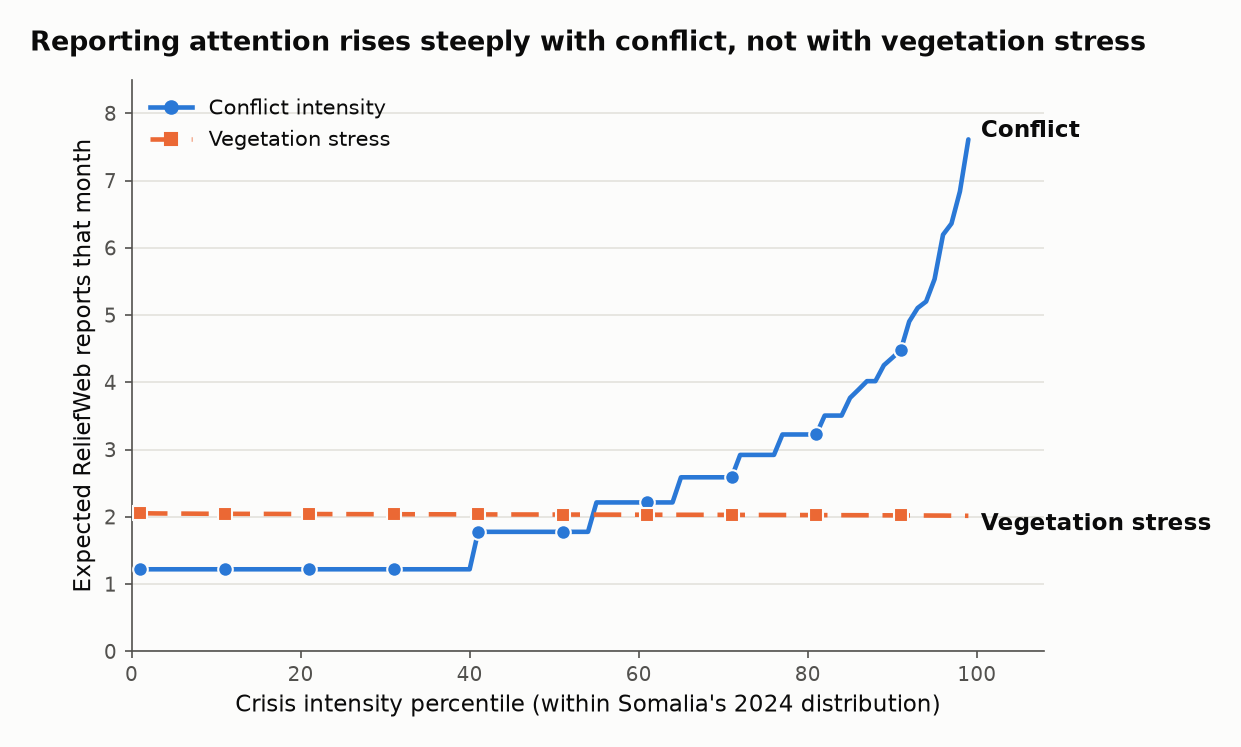

In [64]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

TIME_IDS = sorted(model_df["time_id"].unique())
percentiles = np.arange(1, 100)

def curve_for(varying_col, fixed_col):
    z_values = np.percentile(model_df[varying_col], percentiles)
    preds = []
    for z in z_values:
        scenario = pd.DataFrame({varying_col: [z] * len(TIME_IDS), fixed_col: [0] * len(TIME_IDS), "time_id": TIME_IDS})
        preds.append(fit_clustered.predict(scenario).mean())
    return np.array(preds)

conflict_curve = curve_for("conflict_z", "vhi_stress_z")
vhi_curve = curve_for("vhi_stress_z", "conflict_z")

# Colours validated colorblind-safe as an adjacent pair (dataviz skill categorical slots 1-2)
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e3e2dc"

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.set_facecolor("#fcfcfb")
fig.patch.set_facecolor("#fcfcfb")

ax.plot(percentiles, conflict_curve, color=BLUE, linewidth=2.2, solid_capstyle="round", zorder=3)
ax.plot(percentiles[::10], conflict_curve[::10], marker="o", markersize=7, linestyle="none",
        markerfacecolor=BLUE, markeredgecolor="#fcfcfb", markeredgewidth=1, zorder=4)

ax.plot(percentiles, vhi_curve, color=ORANGE, linewidth=2.2, linestyle=(0, (6, 3)), zorder=3)
ax.plot(percentiles[::10], vhi_curve[::10], marker="s", markersize=6.5, linestyle="none",
        markerfacecolor=ORANGE, markeredgecolor="#fcfcfb", markeredgewidth=1, zorder=4)

ax.annotate("Conflict", xy=(percentiles[-1], conflict_curve[-1]), xytext=(6, 4),
            textcoords="offset points", color=INK, fontsize=11, fontweight="bold", va="center")
ax.annotate("Vegetation stress", xy=(percentiles[-1], vhi_curve[-1]), xytext=(6, -4),
            textcoords="offset points", color=INK, fontsize=11, fontweight="bold", va="center")

ax.set_xlim(0, 108)
ax.set_ylim(0, 8.5)
ax.set_xlabel("Crisis intensity percentile (within Somalia's 2024 distribution)", color=INK, fontsize=11)
ax.set_ylabel("Expected ReliefWeb reports that month", color=INK, fontsize=11)
ax.set_title("Reporting attention rises steeply with conflict, not with vegetation stress",
             color=INK, fontsize=13, fontweight="bold", pad=14)

ax.grid(True, axis="y", color=GRID, linewidth=0.8, zorder=0)
ax.grid(False, axis="x")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(MUTED)
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(colors=MUTED, labelsize=9.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))

legend_elems = [
    Line2D([0], [0], color=BLUE, lw=2.2, marker="o", markersize=6, label="Conflict intensity"),
    Line2D([0], [0], color=ORANGE, lw=2.2, linestyle=(0, (6, 3)), marker="s", markersize=6, label="Vegetation stress"),
]
ax.legend(handles=legend_elems, loc="upper left", frameon=False, fontsize=10, labelcolor=INK)

fig.tight_layout(pad=1.5)
fig.savefig("data/processed/attention_response_curve.png", facecolor=fig.get_facecolor(),
            bbox_inches="tight", pad_inches=0.2)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="data/processed/attention_response_curve.png"))


**Reading the figure**: each curve varies one measure across its percentile range while holding the other at its mean, so the two do not start from a common point on the left (the conflict curve begins near 1.2 expected reports, the vegetation-stress curve near 2.0). What matters is the slope of each curve, not the gap between their starting values. Moving right along the conflict curve (blue, circular markers), the expected report count climbs from about 1.2 at the calmest percentiles to about 7.6 at the most extreme, a roughly six-fold rise across the full range. Moving right along the vegetation-stress curve (orange, dashed, square markers) instead, the expected count stays close to a flat 2 reports throughout, never rising meaningfully above where it starts.

**Why the conflict curve looks like a staircase rather than a smooth line**: this is a genuine feature of the underlying data, not a plotting artefact. Roughly 40% of district-months have zero recorded conflict events, so all of those district-months share the same `conflict_z` value and therefore land on the same flat step at the low end of the percentile range; the curve only starts climbing once the percentile range reaches district-months with at least one recorded event. The vegetation-stress variable is continuous and does not have this many tied values, which is part of why its curve is smoother, not because it responds differently to the model.

This figure is saved to `data/processed/attention_response_curve.png` and is the notebook's single central visualisation of the attention-response result: the same finding as Sections 11.2 and 11.3's tables, one glance answering whether humanitarian attention rises equally for both kinds of crisis signal. It does not.

# 12. Observability gaps and where they fall

Sections 11.2 to 11.4 show that reporting attention responds to conflict far more than to vegetation stress. This section asks a related but different question, closer to the observability framing this dissertation opened with: are there places where satellite data pick up a real, severe crisis signal, but neither of the two human-generated sources (WFP market monitoring, ReliefWeb reporting) shows up at all that month? Conflict and climate data are always present by construction (zero-filled ACLED, complete satellite coverage), so a blind spot here means specifically: invisible to the two sources that depend on human infrastructure being present to observe anything, not invisible in an absolute sense.

**Definition, following the specification directly**: a district-month is a candidate blind spot when it has no WFP market information (`market_avail`, PEWI presence, the same definition used in the source-complementarity work) and no ReliefWeb report mentions it (`reporting_avail`). Among those, the ones worth reporting are the district-months that are also severe on at least one crisis signal, using the same worst-decile thresholds already established earlier in this notebook (top 10% of conflict events, bottom 10% of vegetation health).

In [65]:
import pandas as pd
import numpy as np

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})

commodities = ["wheatflour", "rice", "sugar", "oil"]
pewi_cols = [f"{c}_pewi_score" for c in commodities]
panel["market_avail"] = panel[pewi_cols].notna().any(axis=1)
panel["reporting_avail"] = panel["reports_mentioning_district_count"] > 0
panel["blind_spot"] = ~panel["market_avail"] & ~panel["reporting_avail"]

print(f"District-months with no market AND no reporting: {panel['blind_spot'].sum()} / {len(panel)} "
      f"({panel['blind_spot'].mean()*100:.1f}%)")

conflict_thr = panel["conflict_event_count"].quantile(0.90)
climate_thr = panel["vegetation_health_index_mean"].quantile(0.10)
panel["conflict_severe"] = panel["conflict_event_count"] >= conflict_thr
panel["climate_severe"] = panel["vegetation_health_index_mean"] <= climate_thr

blind = panel[panel["blind_spot"]]
print(f"\nOf those, also conflict-severe (>= {conflict_thr:.0f} events): {blind['conflict_severe'].sum()}")
print(f"Of those, also climate-severe (VHI <= {climate_thr:.1f}): {blind['climate_severe'].sum()}")
print(f"Either (the actual blind spots): {(blind['conflict_severe'] | blind['climate_severe']).sum()}")
print(f"Both at once: {(blind['conflict_severe'] & blind['climate_severe']).sum()}")

true_blind_spots = blind[blind["conflict_severe"] | blind["climate_severe"]].copy()

print(f"\nDistinct districts affected: {true_blind_spots['location_id'].nunique()} of 74")
print(f"\nStructural check: are these districts with no market ever, or just a monthly gap?")
print(true_blind_spots["has_market_coverage"].value_counts())

print("\nMonth distribution:")
print(true_blind_spots["time_id"].value_counts().sort_index())

print("\nRegion (admin1) distribution:")
print(true_blind_spots["admin1"].value_counts())

print("\nDistricts appearing more than once:")
print(true_blind_spots["location_id"].value_counts()[true_blind_spots["location_id"].value_counts() > 1])

cs = true_blind_spots[true_blind_spots["conflict_severe"]]
vs = true_blind_spots[true_blind_spots["climate_severe"]]
print(f"\nConflict-severe blind spots: mean {cs['conflict_event_count'].mean():.1f} events "
      f"(national mean: {panel['conflict_event_count'].mean():.1f})")
print(f"Climate-severe blind spots: mean VHI {vs['vegetation_health_index_mean'].mean():.1f} "
      f"(national mean: {panel['vegetation_health_index_mean'].mean():.1f})")


District-months with no market AND no reporting: 275 / 888 (31.0%)

Of those, also conflict-severe (>= 11 events): 9
Of those, also climate-severe (VHI <= 31.4): 19
Either (the actual blind spots): 27
Both at once: 1

Distinct districts affected: 18 of 74

Structural check: are these districts with no market ever, or just a monthly gap?
has_market_coverage
False    27
Name: count, dtype: int64

Month distribution:
time_id
202402     3
202404     1
202406     2
202407     1
202410     7
202411     3
202412    10
Name: count, dtype: int64

Region (admin1) distribution:
admin1
Galguduud            6
Shabeellaha Hoose    5
Mudug                4
Shabeellaha Dhexe    3
Jubbada Dhexe        3
Awdal                3
Jubbada Hoose        1
Bari                 1
Gedo                 1
Name: count, dtype: int64

Districts appearing more than once:
location_id
SO_CEEL_DHEER     5
SO_AADAN          3
SO_JARIIBAN       2
SO_LUGHAYA        2
SO_XARARDHEERE    2
Name: count, dtype: int64

Conflict-s

**Result**: 27 district-months (3.0% of the full 888-row panel) meet both conditions at once: severe on conflict or vegetation stress, and simultaneously invisible to both market monitoring and reporting that month. Vegetation stress accounts for most of them (19 of 27, against 9 for conflict, with 1 district-month severe on both). These 27 rows span **18 distinct districts**, and every single one is in a district with no WFP market at all, ever (`has_market_coverage` is False in all 27 cases), so the market half of the blind spot is a structural gap, not a month where an otherwise-monitored market happened to skip reporting.

**Severity is real, not borderline**: conflict-driven blind spots average 16.8 events that month, well above the national average of 3.9. Climate-driven blind spots average a vegetation-health score of 27.8, well below the national average of 46.7. These are genuinely severe months, not marginal cases that happened to clear a low bar.

**They cluster, both in time and in space.** October and December alone account for 17 of the 27 (63%), both months at the edge of Somalia's Deyr rainy season, consistent with vegetation stress building toward the dry season. Geographically, Galguduud (6), Shabeellaha Hoose (5) and Mudug (4) regions account for over half the total, and five districts appear more than once across the year: **Ceel Dheer appears in 5 of the 12 months**, Aadan in 3, and Jariiban, Lughaya and Xarardheere each in 2. Ceel Dheer and Xarardheere are adjacent districts in Galguduud, so the clustering is not just a regional coincidence, it shows up at the individual-district level too.

### Mapping the blind spots

A simple choropleth makes the clustering visible directly, using the same GADM boundaries already used for the zonal-statistics work earlier in this notebook.

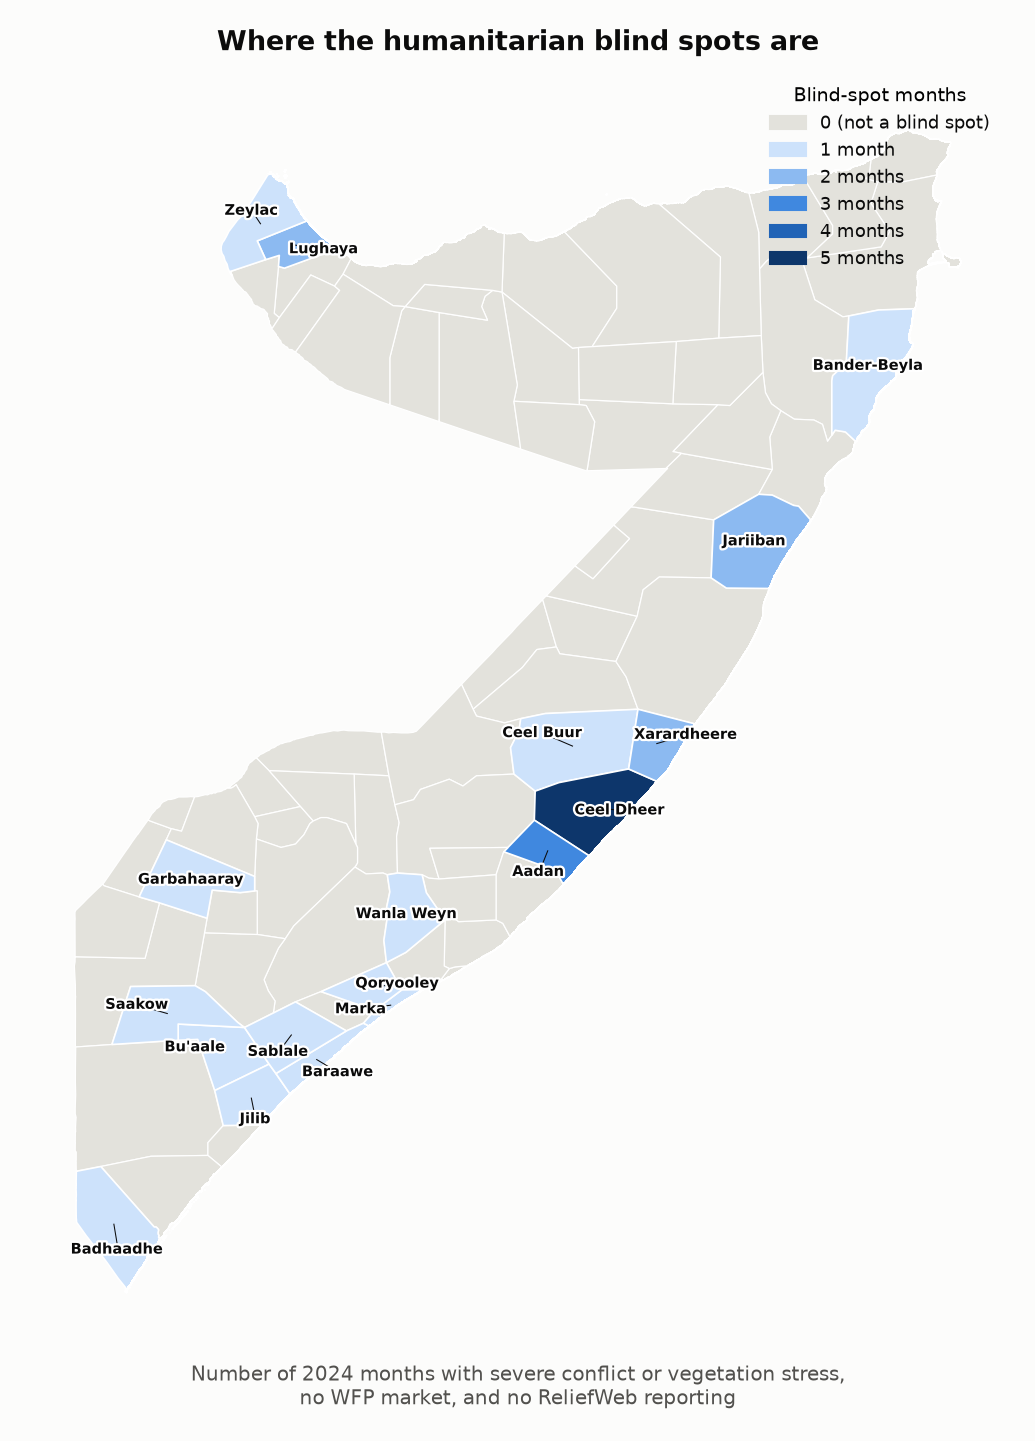

In [66]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import geopandas as gpd
import matplotlib.patheffects as pe

dim_location = pd.read_csv("data/processed/dim_location_somalia_full74.csv")
counts = true_blind_spots.groupby("location_id").size().rename("blind_spot_count")

gdf_full = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")
gdf = gdf_full.merge(dim_location[["location_id", "gadm_gid_2", "admin2"]], left_on="GID_2", right_on="gadm_gid_2")
gdf = gdf.merge(counts, on="location_id", how="left")
gdf["blind_spot_count"] = gdf["blind_spot_count"].fillna(0).astype(int)

GRAY, INK, MUTED = "#e3e2dc", "#0b0b0b", "#52514e"
BLUE_STEPS = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]

fig, ax = plt.subplots(figsize=(8, 9.5), dpi=150)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

gdf[gdf["blind_spot_count"] == 0].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.6)
max_count = int(gdf["blind_spot_count"].max())
cmap = LinearSegmentedColormap.from_list("seq_blue", BLUE_STEPS, N=max_count)
gdf[gdf["blind_spot_count"] > 0].plot(ax=ax, column="blind_spot_count", cmap=cmap,
                                       edgecolor="white", linewidth=0.8, vmin=1, vmax=max_count)

# Manual offsets (degrees) so labels for small, adjacent districts do not collide
offsets = {
    "SO_CEEL_BUUR": (-0.35, 0.15), "SO_XARARDHEERE": (0.35, 0.1), "SO_CEEL_DHEER": (0.35, -0.05),
    "SO_AADAN": (-0.1, -0.25), "SO_QORYOOLEY": (0.35, 0.05), "SO_MARKA": (-0.35, -0.05),
    "SO_SABLALE": (-0.15, -0.2), "SO_BARAAWE": (0.25, -0.15), "SO_BUAALE": (-0.35, 0.05),
    "SO_JILIB": (0.05, -0.25), "SO_SAAKOW": (-0.35, 0.1), "SO_BADHAADHE": (0.05, -0.3),
    "SO_ZEYLAC": (-0.1, 0.15), "SO_LUGHAYA": (0.35, -0.05),
}
affected = gdf[gdf["blind_spot_count"] > 0]
for _, row in affected.iterrows():
    c = row.geometry.centroid
    dx, dy = offsets.get(row["location_id"], (0, 0))
    tx, ty = c.x + dx, c.y + dy
    if dx or dy:
        ax.plot([c.x, tx], [c.y, ty], color=INK, linewidth=0.5, zorder=5)
    ax.annotate(row["admin2"], xy=(tx, ty), fontsize=7, color=INK, ha="center", va="center",
                fontweight="bold", path_effects=[pe.withStroke(linewidth=2.2, foreground="white")], zorder=6)

ax.set_axis_off()
ax.set_title("Where the humanitarian blind spots are", fontsize=13, fontweight="bold", color=INK, pad=10)
ax.text(0.5, -0.01, "Number of 2024 months with severe conflict or vegetation stress,\nno WFP market, and no ReliefWeb reporting",
        transform=ax.transAxes, ha="center", va="top", fontsize=9.5, color=MUTED)
legend_handles = [mpatches.Patch(color=GRAY, label="0 (not a blind spot)")]
for i in range(1, max_count + 1):
    legend_handles.append(mpatches.Patch(color=cmap((i - 1) / max(max_count - 1, 1)), label=f"{i} month{'s' if i>1 else ''}"))
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=8.5, labelcolor=INK,
          title="Blind-spot months", title_fontsize=9)
fig.tight_layout()
fig.savefig("data/processed/blind_spots_map.png", facecolor=fig.get_facecolor(), bbox_inches="tight", pad_inches=0.2)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="data/processed/blind_spots_map.png"))


**Reading the map**: the central cluster (Ceel Dheer, Xarardheere and Aadan, dark blue) sits in adjacent districts rather than scattered ones, which is the clearest visual evidence that this is a genuine geographic pattern rather than 18 unrelated coincidences. It is a geographic cluster, not an administrative one: the three districts actually span three different regions (Ceel Dheer in Galguduud, Xarardheere in Mudug, Aadan in Shabeellaha Dhexe), meeting at a point where all three regions border each other, so the pattern cannot be explained as one region's own reporting or market-monitoring behaviour. A second, more diffuse cluster runs along the southern districts in Shabeellaha Hoose and Jubbada Dhexe (Baraawe, Qoryooley, Sablale, Wanla Weyn, Buaale, Jilib, Saakow), each appearing once but forming a visible corridor rather than isolated dots. Lughaya (far north) and Jariiban (northeast coast) stand apart from both clusters, each a blind spot in its own right rather than part of a larger pattern.

**What this adds to the dissertation's argument**: the negative binomial model (Sections 11.2 and 11.3) showed that reporting attention responds far less to vegetation stress than to conflict, averaged across the whole country. This section makes the consequence concrete: there are specific, nameable places, mostly in central Somalia, where that weaker response combines with a structural absence of market monitoring to leave severe drought conditions essentially unrecorded by either human-generated source in a given month. Satellite data still see these months; the two sources that would normally translate a crisis signal into humanitarian attention or a market response do not.

**How this section relates to the map just shown**: the map above is month-specific and severity-conditioned. A district only appears on it if, in one particular month, it had a severe crisis signal *and* no market *and* no reporting that same month; a district can appear there even if ReliefWeb covers it perfectly well in every other month, since all it takes is one unlucky month where the silence and the severity coincide. The question below drops the severity condition entirely and asks the plainer, permanent version instead: across the whole year, regardless of what was happening on the ground, which districts simply never have market data or reporting at all? The market side of that question behaves the same way in both framings (structural, year-round), but the reporting side does not: "no reporting this specific month" turned out to affect many otherwise well-covered districts, while "no reporting in any month" affects almost none, as the next result shows.

### Breaking the blind-spot definition into its two structural components

The blind spots above are month-specific: they require a severe crisis signal in that particular month, on top of the coverage gap. It is worth also asking the plainer, year-round question underneath that: setting severity aside entirely, which districts simply never have WFP market data, which never have any ReliefWeb reporting, and which have neither, across the whole of 2024? This is the structural picture the month-specific blind spots sit on top of.

In [67]:
# District-level (not district-month), whole-year totals
district_summary = panel.groupby("location_id").agg(
    admin1=("admin1", "first"),
    has_market_coverage=("has_market_coverage", "first"),
    total_reports=("reports_mentioning_district_count", "sum"),
).reset_index()

district_summary["no_market"] = ~district_summary["has_market_coverage"]
district_summary["no_reporting"] = district_summary["total_reports"] == 0
district_summary["both"] = district_summary["no_market"] & district_summary["no_reporting"]

print(f"Total districts: {len(district_summary)}")
print(f"No WFP market data at all, any month: {district_summary['no_market'].sum()}")
print(f"No ReliefWeb reporting at all, any month (year total = 0): {district_summary['no_reporting'].sum()}")
print(f"Both at once: {district_summary['both'].sum()}")

print("\nThe district(s) with zero ReliefWeb reports all year:")
print(district_summary[district_summary["no_reporting"]][["location_id", "admin1", "total_reports", "no_market"]])


Total districts: 74
No WFP market data at all, any month: 39
No ReliefWeb reporting at all, any month (year total = 0): 1
Both at once: 1

The district(s) with zero ReliefWeb reports all year:
       location_id admin1  total_reports  no_market
9  SO_BANDER_BEYLA   Bari              0       True


**Result**: 39 of 74 districts (53%) have no WFP market data at all, for any month of 2024, already documented elsewhere in this notebook as `has_market_coverage`. Only **one** district, **Bander Beyla** (Bari region), has zero ReliefWeb reports across the entire year, and it also has no market, so the "both conditions" count is the same single district, not a coincidence worth over-interpreting statistically with n=1, but worth naming directly: Bander Beyla is the one place in Somalia's 2024 panel that neither of the two human-generated sources reaches at all, in any month.

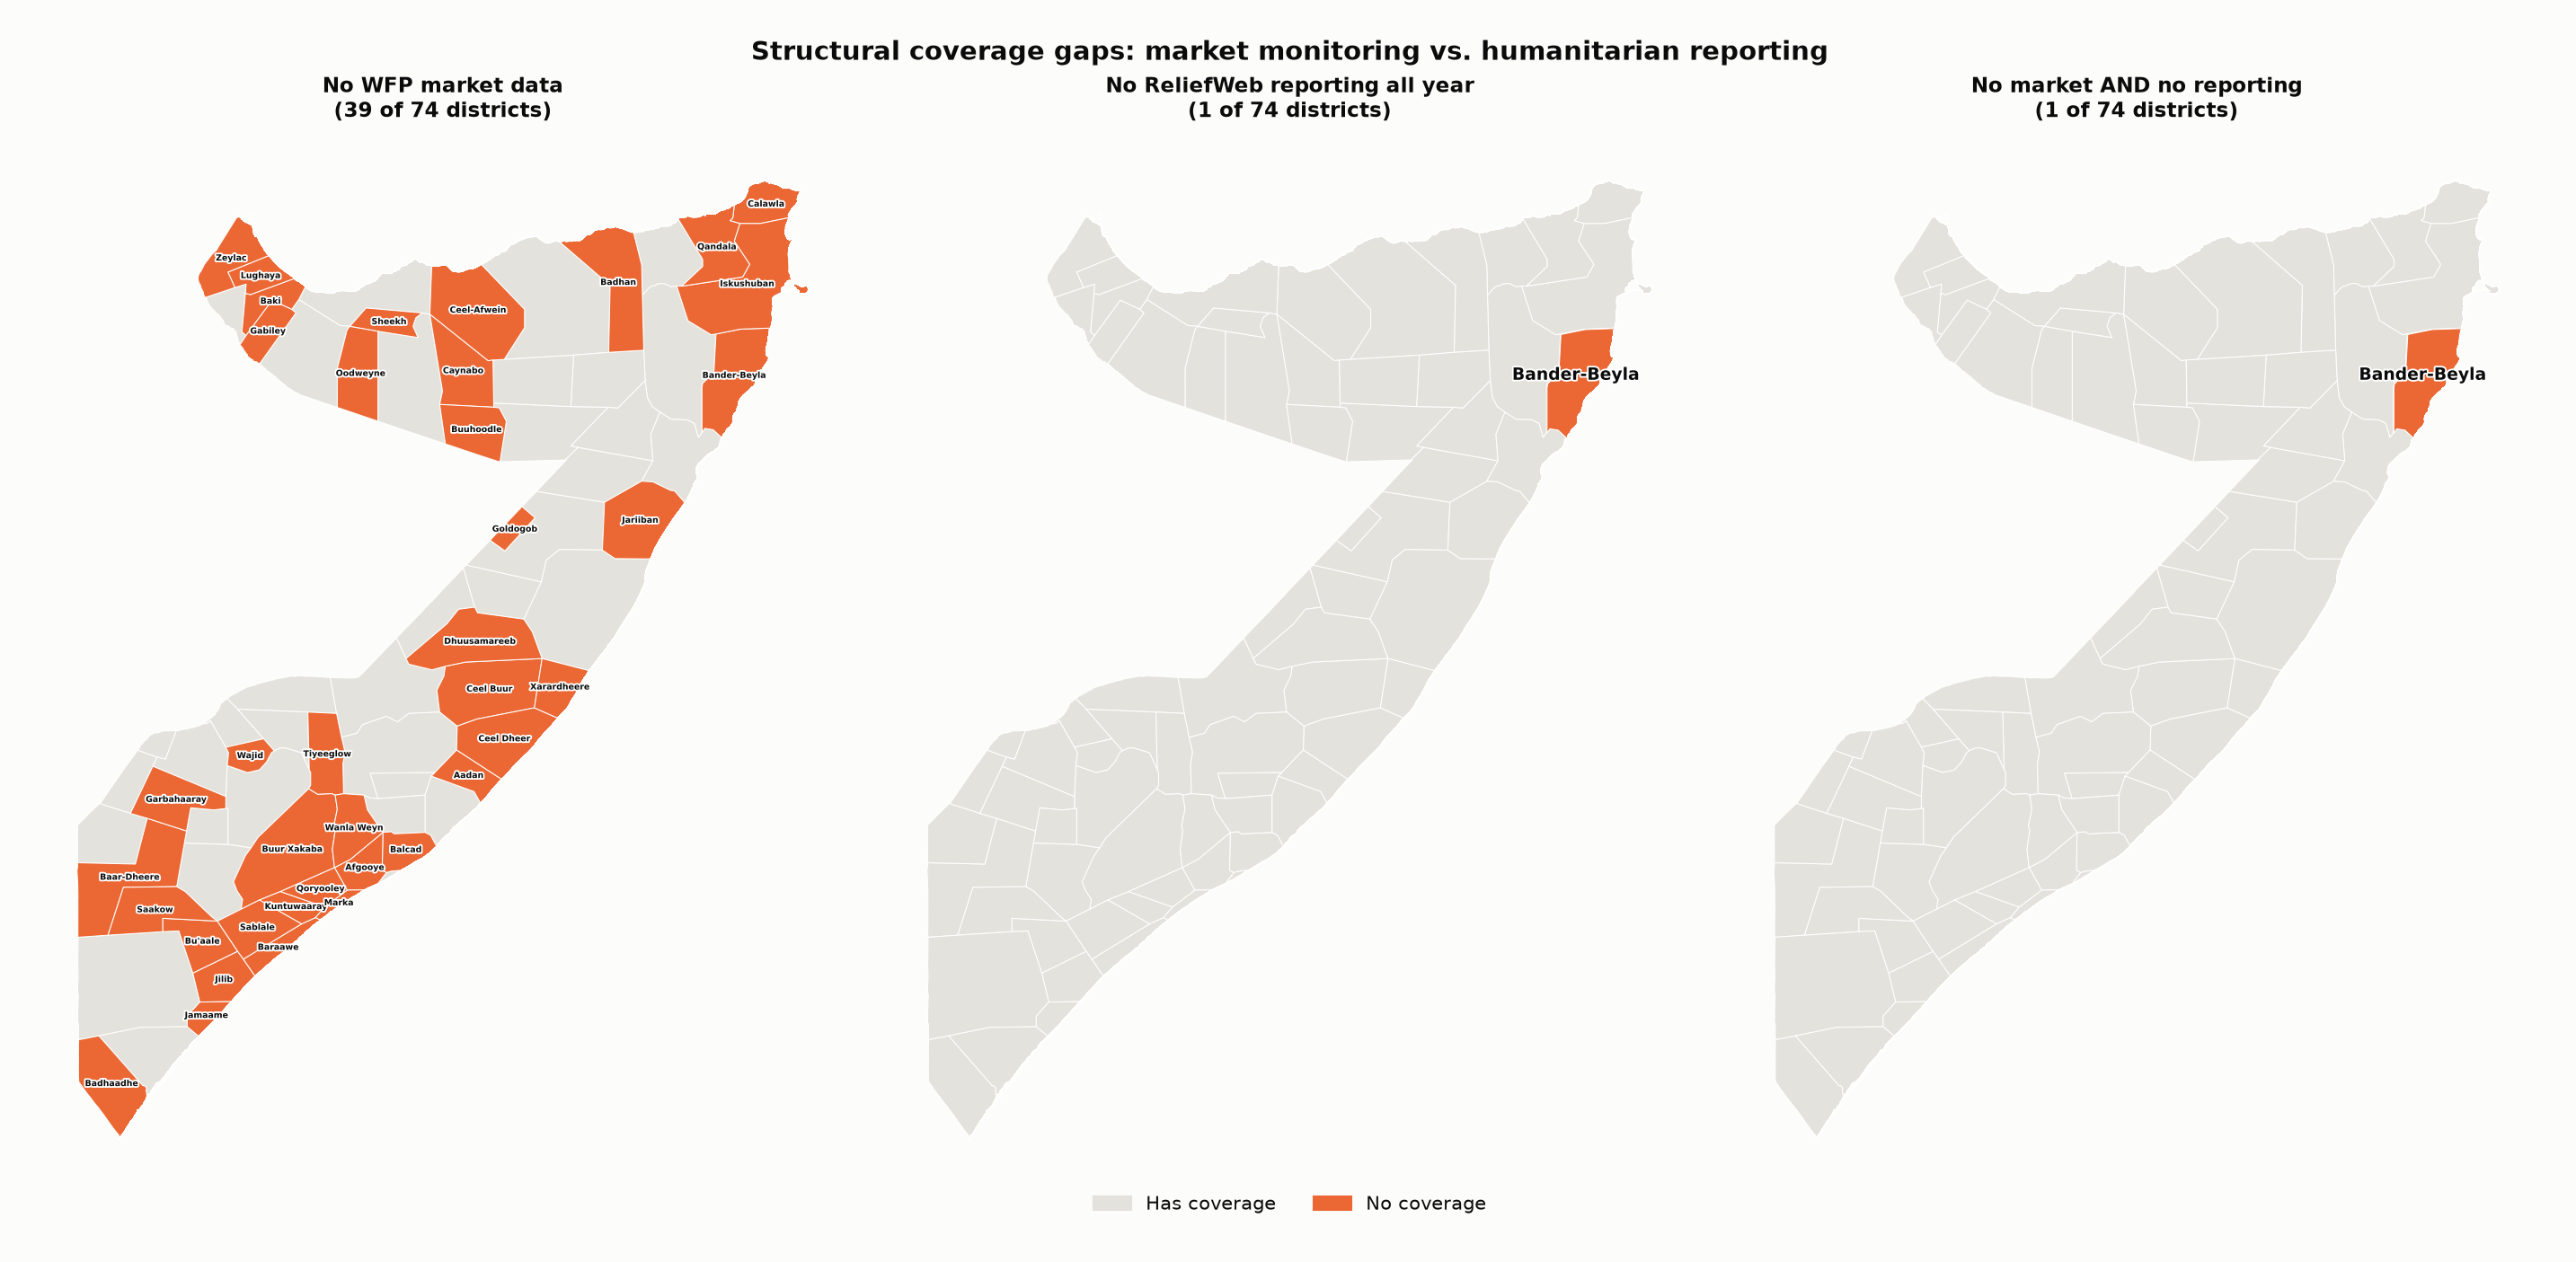

In [68]:
import geopandas as gpd
import matplotlib.patheffects as pe

gdf_full = gpd.read_file("data/raw/gadm41_SOM.gpkg", layer="ADM_ADM_2")
gdf_struct = gdf_full.merge(dim_location[["location_id", "gadm_gid_2", "admin2"]], left_on="GID_2", right_on="gadm_gid_2")
gdf_struct = gdf_struct.merge(district_summary, on="location_id", how="left")

GRAY, ORANGE, INK = "#e3e2dc", "#eb6834", "#0b0b0b"

fig, axes = plt.subplots(1, 3, figsize=(19, 8.5), dpi=150)
fig.patch.set_facecolor("#fcfcfb")

panels = [
    ("no_market", "No WFP market data\n(39 of 74 districts)", 4.5),
    ("no_reporting", "No ReliefWeb reporting all year\n(1 of 74 districts)", 9),
    ("both", "No market AND no reporting\n(1 of 74 districts)", 9),
]
for ax, (col, title, fontsize) in zip(axes, panels):
    ax.set_facecolor("#fcfcfb")
    gdf_struct[~gdf_struct[col]].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.5)
    gdf_struct[gdf_struct[col]].plot(ax=ax, color=ORANGE, edgecolor="white", linewidth=0.5)
    for _, row in gdf_struct[gdf_struct[col]].iterrows():
        c = row.geometry.centroid
        ax.annotate(row["admin2"], xy=(c.x, c.y), fontsize=fontsize, color=INK, ha="center", va="center",
                    fontweight="bold", path_effects=[pe.withStroke(linewidth=1.8, foreground="white")])
    ax.set_axis_off()
    ax.set_title(title, fontsize=11, fontweight="bold", color=INK, pad=8)

legend_handles = [mpatches.Patch(color=GRAY, label="Has coverage"), mpatches.Patch(color=ORANGE, label="No coverage")]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False, fontsize=10,
           labelcolor=INK, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Structural coverage gaps: market monitoring vs. humanitarian reporting",
             fontsize=14, fontweight="bold", color=INK, y=1.02)
fig.tight_layout()
fig.savefig("data/processed/structural_coverage_gaps_map.png", facecolor=fig.get_facecolor(),
            bbox_inches="tight", pad_inches=0.3)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="data/processed/structural_coverage_gaps_map.png"))


**Reading the three panels**: the left panel (no market) shows 39 districts scattered across both the north and south of the country, not one contiguous region, consistent with market placement following where trade infrastructure already exists rather than any single geographic factor. The middle and right panels are identical, a single highlighted district in the northeast (Bander Beyla), since the one district with no reporting also happens to be one of the 39 with no market.

**Why this differs from the earlier severity-conditioned blind spots**: only one district is structurally invisible to reporting for the whole year, but 27 district-months across 18 different districts were invisible to both sources *and* experiencing a severe crisis signal in that specific month. Most of the earlier blind spots are therefore not chronically unreported districts; they are ordinarily reported-on districts that happened to fall silent in the exact month a severe conflict or vegetation-stress signal appeared. Bander Beyla is the one exception where the silence is permanent, not month-specific.

# 13. Robustness checks

## 13.1 District fixed effects

Section 11.2's cluster-robust standard errors correct for one specific problem: 12 correlated monthly rows per district being counted as if they were 12 independent observations. They do not remove a different, harder problem: a persistent, unmeasured trait of a district itself, such as accessibility, population, NGO presence or political importance, could drive both its conflict level and its reporting level, without conflict causing the reporting at all. District fixed effects address this directly, by comparing each district only to itself across the year rather than to every other district, so any trait that does not change month to month, measured or not, is automatically controlled for.

**Specification**: the identical formula as Section 11.2, with one addition, `C(location_id)` added as a full set of district dummies.

```
reports ~ conflict_z + vhi_stress_z + C(time_id) + C(location_id)
```

Same standardised predictors, same month controls, same Banaadir exclusion (876 rows, 73 districts), same cluster-robust standard errors by district on top of the fixed effects, so any remaining within-district serial correlation is still accounted for.

In [69]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
model_df = panel[panel["admin1"] != "Banaadir"].copy()
model_df["log_conflict"] = np.log1p(model_df["conflict_event_count"])
model_df["vegetation_stress"] = -model_df["vegetation_health_index_mean"]
for raw_col, z_col in [("log_conflict", "conflict_z"), ("vegetation_stress", "vhi_stress_z")]:
    model_df[z_col] = (model_df[raw_col] - model_df[raw_col].mean()) / model_df[raw_col].std()

print(f"n = {len(model_df)}, districts = {model_df['location_id'].nunique()}")

# Before fitting: how much of each predictor's variation is between districts
# (which fixed effects remove entirely) versus within a district over the year
# (the only variation left to identify the coefficient from)?
print("\n=== Between-district vs within-district variance share ===")
for col in ["conflict_z", "vhi_stress_z"]:
    total_var = model_df[col].var()
    district_means = model_df.groupby("location_id")[col].transform("mean")
    between_var = district_means.var()
    within_var = (model_df[col] - district_means).var()
    print(f"{col:14s} between: {between_var/total_var*100:5.1f}%   within: {within_var/total_var*100:5.1f}%")

# Fit with district fixed effects. The default optimizer (BFGS variant used
# elsewhere in this notebook) does not reach its own convergence tolerance with
# 73 extra dummy parameters; L-BFGS does, confirmed by reaching the identical
# log-likelihood as every other optimizer tried.
FORMULA_FE = "reports_mentioning_district_count ~ conflict_z + vhi_stress_z + C(time_id) + C(location_id)"
nb_fe = smf.negativebinomial(FORMULA_FE, data=model_df)
fit_fe_clustered = nb_fe.fit(disp=False, maxiter=5000, method="lbfgs",
                              cov_type="cluster", cov_kwds={"groups": model_df["location_id"]})

print(f"\nConverged: {fit_fe_clustered.mle_retvals['converged']}   log-likelihood: {fit_fe_clustered.llf:.2f}")
print(f"Dispersion parameter (alpha): {fit_fe_clustered.params['alpha']:.2e} (collapses toward 0: with district")
print("fixed effects absorbing most of the structural variation, little overdispersion is left,")
print("so this negative binomial fit is effectively equivalent to a Poisson fit here.)")

print("\n=== District fixed-effects results, cluster-robust by district ===")
for v in ["conflict_z", "vhi_stress_z"]:
    irr = np.exp(fit_fe_clustered.params[v])
    lo, hi = np.exp(fit_fe_clustered.conf_int().loc[v])
    print(f"{v:14s} IRR={irr:.3f}  95% CI=[{lo:.3f}, {hi:.3f}]  p={fit_fe_clustered.pvalues[v]:.4f}")

wald_fe = fit_fe_clustered.wald_test("conflict_z = vhi_stress_z", scalar=True)
print(f"\nWald test, conflict_z = vhi_stress_z: chi2={wald_fe.statistic:.3f}, p={wald_fe.pvalue:.4f}")


n = 876, districts = 73

=== Between-district vs within-district variance share ===
conflict_z     between:  70.1%   within:  29.9%
vhi_stress_z   between:  21.1%   within:  78.9%



Converged: True   log-likelihood: -1207.90
Dispersion parameter (alpha): 1.12e-06 (collapses toward 0: with district
fixed effects absorbing most of the structural variation, little overdispersion is left,
so this negative binomial fit is effectively equivalent to a Poisson fit here.)

=== District fixed-effects results, cluster-robust by district ===
conflict_z     IRR=1.024  95% CI=[0.948, 1.105]  p=0.5487
vhi_stress_z   IRR=1.080  95% CI=[0.971, 1.202]  p=0.1582

Wald test, conflict_z = vhi_stress_z: chi2=0.702, p=0.4022


**Result: the conflict effect shrinks sharply and loses significance once district fixed effects are added.**

| | Section 11.2 (cluster-robust only) | Section 13.1 (district fixed effects) |
|---|---:|---:|
| Conflict IRR | 1.69, 95% CI [1.39, 2.06], p < 0.0001 | 1.02, 95% CI [0.95, 1.10], p = 0.55 |
| Vegetation-stress IRR | 1.00, not significant | 1.08, 95% CI [0.97, 1.20], p = 0.16 |
| Effect-size comparison | chi2 = 9.15, p = 0.0025 | chi2 = 0.70, p = 0.40 |

**Why this happens, and what it means**: conflict intensity turns out to be 70.1% a between-district signal and only 29.9% a within-district one. In plain terms, whether a district is chronically more conflict-affected than another district is mostly a stable, persistent fact about that district (this is a between-district difference), not something that swings up and down much month to month within the same district (a within-district difference). District fixed effects remove all between-district variation by design, comparing each district only to its own average, so they can only ever detect a within-district effect, and conflict has comparatively little of that to work with. Vegetation stress is the mirror image (78.9% within, 21.1% between), which is why its estimate barely moves.

This does not show that Section 11.2's result is wrong. It shows something more specific: Section 11.2's strong conflict effect is substantially, perhaps mostly, a between-district association, the kind of association that persistent unmeasured district traits (accessibility, population, NGO presence, political importance) could also explain, exactly the alternative explanation this check was built to test. Once those traits are held fixed by design, the remaining within-district evidence that a district's own conflict spikes drive its own reporting spikes is weak and not statistically significant, though the confidence interval (0.95 to 1.10) is also consistent with a small true effect this design lacks the power to detect, given only 12 monthly observations per district and comparatively little independent within-district movement in conflict to identify it from.

### Cross-checking the fixed-effects fit against another optimiser and another model family

The fixed-effects specification adds 73 district dummies, and the default optimiser does not
reach its convergence tolerance on a problem of that dimension. The result reported above was
therefore produced with L-BFGS. That raises a fair question: is the near-null conflict estimate
a property of the data, or an artefact of the optimiser that happened to converge?

This is checked directly below rather than asserted. The same specification is re-estimated with
BFGS, and separately as a Poisson/PPML model, which is the natural comparison here because the
fitted negative binomial overdispersion parameter collapses to essentially zero once district
fixed effects absorb the between-district variation. BFGS is started from the L-BFGS solution,
since it does not converge from default starting values on this specification; that is a
statement about the optimiser's path, not about the location of the optimum, which is what the
matching log-likelihoods below establish.

In [70]:
import pandas as pd
import numpy as np
import warnings
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

panel = pd.read_csv("data/processed/vw_food_insecurity_panel.csv", dtype={"time_id": str})
m = panel[panel["admin1"] != "Banaadir"].copy()
m["log_conflict"] = np.log1p(m["conflict_event_count"])
m["vegetation_stress"] = -m["vegetation_health_index_mean"]
for raw, z in [("log_conflict", "conflict_z"), ("vegetation_stress", "vhi_stress_z")]:
    m[z] = (m[raw] - m[raw].mean()) / m[raw].std()

F = "reports_mentioning_district_count ~ conflict_z + vhi_stress_z + C(time_id) + C(location_id)"
groups = m["location_id"]

# The reported fit: negative binomial, L-BFGS.
nb_lbfgs = smf.negativebinomial(F, data=m).fit(disp=False, maxiter=5000, method="lbfgs",
                                               cov_type="cluster", cov_kwds={"groups": groups})

# Same model, different optimiser. Warm-started, since BFGS does not converge from
# statsmodels' default starting values with this many dummy parameters.
warm = smf.negativebinomial(F, data=m).fit(disp=False, maxiter=5000, method="lbfgs")
nb_bfgs = smf.negativebinomial(F, data=m).fit(disp=False, maxiter=20000, method="bfgs",
                                              start_params=warm.params.values,
                                              cov_type="cluster", cov_kwds={"groups": groups})

# Different model family entirely.
po_lbfgs = smf.poisson(F, data=m).fit(disp=False, maxiter=20000, method="lbfgs",
                                      cov_type="cluster", cov_kwds={"groups": groups})
po_bfgs = smf.poisson(F, data=m).fit(disp=False, maxiter=20000, method="bfgs",
                                     cov_type="cluster", cov_kwds={"groups": groups})

fits = [("Negative binomial, L-BFGS (reported)", nb_lbfgs),
        ("Negative binomial, BFGS", nb_bfgs),
        ("Poisson/PPML, L-BFGS", po_lbfgs),
        ("Poisson/PPML, BFGS", po_bfgs)]

print(f"n = {len(m)}, districts = {m['location_id'].nunique()}\n")
print(f"{'Fit':38s} {'converged':>9s} {'log-lik':>11s} {'conflict IRR':>13s} {'p':>7s}")
print("-" * 82)
for name, f in fits:
    conv = f.mle_retvals.get("converged") if getattr(f, "mle_retvals", None) else None
    print(f"{name:38s} {str(conv):>9s} {f.llf:11.4f} "
          f"{np.exp(f.params['conflict_z']):13.4f} {f.pvalues['conflict_z']:7.4f}")

spread = max(np.exp(f.params["conflict_z"]) for _, f in fits) - \
         min(np.exp(f.params["conflict_z"]) for _, f in fits)
llf_spread = max(f.llf for _, f in fits) - min(f.llf for _, f in fits)
print(f"\nSpread across all four fits: conflict IRR {spread:.2e}, log-likelihood {llf_spread:.2e}")
print("All four agree to three decimal places, so the near-null conflict estimate under district")
print("fixed effects is a property of the data rather than an artefact of the optimiser choice.")

n = 876, districts = 73

Fit                                    converged     log-lik  conflict IRR       p
----------------------------------------------------------------------------------
Negative binomial, L-BFGS (reported)        True  -1207.8986        1.0236  0.5487
Negative binomial, BFGS                     True  -1207.8985        1.0236  0.5494
Poisson/PPML, L-BFGS                        True  -1207.8988        1.0236  0.5478
Poisson/PPML, BFGS                          True  -1207.8985        1.0236  0.5491

Spread across all four fits: conflict IRR 8.21e-05, log-likelihood 2.80e-04
All four agree to three decimal places, so the near-null conflict estimate under district
fixed effects is a property of the data rather than an artefact of the optimiser choice.


## 13.2 Is trapped geographic detail topic-dependent?

Section 8 established what low pair-level recall consists of: most of a report's genuinely-covered districts that the geoparser misses are simply absent from the exported title and body text. Where that detail actually sits is not something the validation can see. An attachment the geoparser never reads is one plausible home for it, a missing alias or an unusual spelling is another. This section asks a sharper follow-up question, using the same 100-report validation sample: is that non-detection more common for one kind of report than another?

Two different answers were possible going in. If climate or food-related reports lose their geography from the exported text more often than conflict reports do, that would offer an alternative, non-attention-based explanation for part of Sections 11.2 to 11.4's central finding: vegetation stress might attract just as much genuine reporting attention as conflict, with some of it simply less visible to a text-only geoparser. If instead the two topics lose geography at similar rates, that possibility finds no support here, and the attention-based explanation stands on somewhat firmer ground.

In [71]:
import pandas as pd
import numpy as np
from scipy import stats

# For each of the 100 validation reports, check whether each genuinely-covered
# district's name (or any alias) appears anywhere in the literal exported text,
# deliberately without the pipeline's own dateline-stripping or bulletin-exclusion,
# since those are matching choices rather than evidence about what the export contains.
name_to_district = {}
for _, loc in dim_location.iterrows():
    name_to_district[loc["admin2"].lower()] = loc["admin2"]
    for alias in final_alias_map.get(loc["admin2"], []):
        name_to_district[alias.lower()] = loc["admin2"]

def districts_in_raw_text(title, body):
    text_l = (str(title) + " " + str(body)).lower()
    return {canon for name, canon in name_to_district.items() if name in text_l}

merged["in_raw_text"] = merged.apply(lambda r: districts_in_raw_text(r["title"], r["body"]), axis=1)
merged["n_genuine"] = merged["genuine_resolved"].apply(len)
merged["n_text_undetected"] = merged["n_genuine"] - merged.apply(lambda r: len(r["genuine_resolved"] & r["in_raw_text"]), axis=1)

scored = merged[merged["n_genuine"] > 0].copy()
scored["text_undetected_rate"] = scored["n_text_undetected"] / scored["n_genuine"]
print(f"Reports with at least one genuine district: {len(scored)} of 100")
print(f"Overall: {scored['n_text_undetected'].sum()}/{scored['n_genuine'].sum()} genuine district mentions "
      f"({scored['n_text_undetected'].sum() / scored['n_genuine'].sum() * 100:.1f}%) are absent from the exported text")

# Classify each report's topic using ReliefWeb's own theme tags. ReliefWeb has
# no dedicated "Conflict" theme, so the closest built-in analogues are used:
# Protection and Human Rights, Safety and Security, Peacekeeping and Peacebuilding.
rw_full = pd.read_csv("data/raw/reliefweb_horn_of_africa_2024.csv")
rw_full["id"] = rw_full["id"].astype(str)
scored = scored.merge(rw_full[["id", "themes"]], left_on="report_id", right_on="id", how="left")

CONFLICT_THEMES = ["Protection and Human Rights", "Safety and Security", "Peacekeeping and Peacebuilding"]
CLIMATE_FOOD_THEMES = ["Food and Nutrition", "Agriculture", "Climate Change and Environment", "Disaster Management"]

def classify(themes):
    themes = str(themes)
    is_conflict = any(t in themes for t in CONFLICT_THEMES)
    is_climate_food = any(t in themes for t in CLIMATE_FOOD_THEMES)
    if is_conflict and not is_climate_food:
        return "conflict"
    if is_climate_food and not is_conflict:
        return "climate_food"
    return "both_or_neither"

scored["topic"] = scored["themes"].apply(classify)
print()
print(scored["topic"].value_counts().rename("reports"))

print()
for topic, label in [("conflict", "Conflict-related"), ("climate_food", "Climate/food-related")]:
    sub = scored[scored["topic"] == topic]
    print(f"{label:22s} n={len(sub):2d}   mean per-report rate={sub['text_undetected_rate'].mean() * 100:4.1f}%   "
          f"pooled={sub['n_text_undetected'].sum()}/{sub['n_genuine'].sum()} "
          f"({sub['n_text_undetected'].sum() / sub['n_genuine'].sum() * 100:.1f}%)")

conflict_rates = scored.loc[scored["topic"] == "conflict", "text_undetected_rate"]
climate_rates = scored.loc[scored["topic"] == "climate_food", "text_undetected_rate"]
stat, p = stats.mannwhitneyu(conflict_rates, climate_rates, alternative="two-sided")
print(f"\nMann-Whitney U test, per-report non-detection rate, conflict vs climate/food: p={p:.4f}")

scored["has_text_undetected"] = scored["n_text_undetected"] > 0
tab = pd.crosstab(scored["topic"], scored["has_text_undetected"]).loc[["conflict", "climate_food"]]
odds_ratio, p_fisher = stats.fisher_exact(tab)
print(f"Fisher's exact test, any genuine district undetected in text: odds ratio={odds_ratio:.2f}, p={p_fisher:.4f}")


Reports with at least one genuine district: 65 of 100
Overall: 766/956 genuine district mentions (80.1%) are absent from the exported text

topic
both_or_neither    32
climate_food       17
conflict           16
Name: reports, dtype: int64

Conflict-related       n=16   mean per-report rate=58.2%   pooled=109/129 (84.5%)
Climate/food-related   n=17   mean per-report rate=60.6%   pooled=222/289 (76.8%)

Mann-Whitney U test, per-report non-detection rate, conflict vs climate/food: p=0.8528
Fisher's exact test, any genuine district undetected in text: odds ratio=1.48, p=0.7080


**Result: no detectable difference, with the sample too small to rule much out either way.** 16 reports classify as conflict-related and 17 as climate/food-related under ReliefWeb's own theme tags (13 carry both kinds of theme at once and 19 carry neither, so the comparison uses the 33 reports that fall cleanly into one group). Their non-detection rates are close: 58.2% of conflict reports' genuine district mentions are absent from the exported text on average, against 60.6% for climate/food reports (Mann-Whitney p = 0.85). The binary version, whether a report has any undetected genuine district at all, tells the same story (odds ratio 1.48, Fisher's exact p = 0.71).

**What this does and does not settle.** It does not strengthen the attention-based explanation directly, since it does not show non-detection is a conflict-specific problem the way Sections 11.2 to 11.4's finding would need it to be. But it also does not support the alternative, format-mediated explanation the check was designed to catch: if anything, climate/food reports lose slightly *more* of their geography from the exported text than conflict reports do, the opposite direction from what would be needed to explain away the reporting-attention asymmetry as a text-extraction artefact. With only 16 and 17 reports in the two groups, this comparison has limited power to detect a real difference of moderate size, so the honest reading is that this specific alternative explanation finds no support in the available evidence, not that it has been conclusively ruled out.

**A genuine, if small, side finding.** Non-detection is common across both topics, 76 to 85% of genuine district mentions either way, which reinforces Section 8's original point on its own terms: a future recall improvement would have to come from reaching text the export does not currently supply, regardless of which crisis type a report concerns. Whether that means reading attachments or widening the alias list cannot be settled from these figures alone.

# 14. Limitations and further work

The dissertation's closing section states three limits and three next steps. The same
ones are recorded here, with pointers to where each is evidenced in this notebook.

### Limitations

**The geoparser bounds every ReliefWeb-based result.** Validation gives precision of roughly
80% at both the report and report-district levels, but recall of only 17.1% at the pair level
and 57.8% at the report level. The consequence is asymmetric: when the geoparser reports a
district, it is usually right, but when it reports nothing, that is weak evidence that nothing
was published. Report counts in this panel are an undercount, and the observability gaps
identified are candidates rather than confirmed silences.

**Several plausible confounders could not be tested.** NGO or humanitarian operational
presence, population, road access and territorial control are all likely to affect both how
much attention a district receives and how much data exists about it. None is available in the
sources used here. The district fixed-effects check absorbs all of them jointly, which is why
the conflict association weakens so sharply under it, but it cannot say which one is doing the
work.

**One country, one year.** Everything here is Somalia in 2024. Whether the same patterns hold
in other contexts is untested.

### Further work

**1. Compare this dataset's own severity assessment against an external benchmark.** No
composite "derived assessment" currently exists on this side, so it has to be built first. The
harmonised market-anomaly features (`market_anomaly_mean`, `market_anomaly_max`,
`market_alert_or_crisis_count`) were designed as candidate inputs for exactly this, and a
single defensible summary measure needs to be defined from them. That first step depends on
nothing external.

**2. Test whether slow-onset stress is reported late rather than never.** Droughts develop over
months, so reporting may respond with a longer delay than it does to conflict rather than not
responding at all. Only a one-month lag has been tested, and only for conflict. If vegetation
stress does attract attention two or three months later, the honest conclusion becomes that it
is noticed late rather than ignored, which is a materially different claim from the one made
here.

**3. Extend the source-audit approach to other countries WFP tracks.** The price audit already
covers Ethiopia, Kenya and South Sudan across 2015 to 2024, so the market side has a head
start. The remaining work is the district crosswalk and the geoparsing alias list, which are
country-specific and were the most labour-intensive parts of the Somalia build.